# Three-dimensional MuMax3 validation of a conditional-magnon device concept

This notebook contains the reproducible MuMax3 campaign supporting the revised manuscript
**“Conditional Josephson coupling toward an analog classical CNOT in a magnon Bose–Einstein condensate.”**

## Scientific scope

- The calculations solve the three-dimensional, time-dependent Landau–Lifshitz–Gilbert equation for the stated YIG geometries.
- They validate weak-drive linearity, field-defined double-well mode identity, combined-device equilibrium, and the absence of a resolved raw direct-dipolar contrast between equal-amplitude (+q_0) and (-q_0) preparations.
- The central barrier is a prescribed longitudinal Zeeman-field region.
- The wave-vector-selective receiver/transducer of the reduced model is **not** simulated here.
- Sub-bin peak separations are descriptive and are **not** reported as resolution-validated coupling measurements.
- This notebook is not a full CNOT simulation or a claim of a demonstrated CNOT.

## Kaggle setup

1. Enable a **GPU T4 ×2** accelerator where available. Paired runs use both GPUs; single-GPU execution is not the validated public path for those cells.
2. Add the Kaggle dataset **`duyle09/mumax3-bin`**, containing the frozen Linux MuMax3 binary expected by the bootstrap audit.
3. Internet access is not required.
4. Run only the branch required for your purpose. The complete historical notebook can exceed one Kaggle session if every optional cell is recomputed from scratch.

The displayed outputs are retained from the audited campaign. Re-running a cell writes machine-readable JSON reports, figures, logs, scripts, hashes, and a downloadable ZIP archive under `/kaggle/working`.

## Recommended execution map

| Purpose | Cells | Status in the manuscript |
|---|---|---|
| Environment and binary audit | K00 | Required foundation |
| Weak-drive linearity at 65 mT | K01 | Reported evidence |
| Earlier single-ellipse direct-dynamics branch | K02 → K03 → K03R → K04 → K04B | Optional exploratory provenance; K03 reached the original session limit and K03R analyses only the common truncated record |
| Explicit field-defined double well | K05 → K05B → K05C → K05D | Reported mode-identity and resolution audit |
| Combined control–target geometry | K06A → K06B | Reported equilibrium and raw-field null control |
| Fine-mesh sensitivity and final package | K07 | Standalone reported evidence; may be run in a fresh session |

For the shortest manuscript-evidence path, use **K00 → K01 → K05 → K05B → K05C → K05D → K06A → K06B**. Run **K07** independently if the preceding Kaggle session has expired.

“PASS” means that the stated audit completed and its acceptance checks passed. It does not override the `outcome` or `manuscript_boundary` fields in each report.

## 1. Reproducible environment bootstrap

K00 verifies the frozen MuMax3 binary, CUDA/GPU availability, physical constants, geometry locks, and the absence of imported numerical results.

In [9]:
"""Kaggle K00-FRESH: clean full-LLG campaign bootstrap, no imported results.

The only required Kaggle Input is the frozen
MuMax3 Linux binary dataset already used by the project. No Colab archive or
numerical result is read.
"""

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import math
import os
import platform
import re
import shutil
import stat
import subprocess
import sys
import time
import zipfile


PIPELINE_VERSION = "jphysd-kaggle-full-llg-fresh-k00-v1"
EXPECTED_BINARY_SHA256 = "cd048134740e8da1475acd9f8767faaee8ac7061a235f48bd64c1d44a2b98d3b"
KNOWN_BINARY = Path("/kaggle/input/datasets/duyle09/mumax3-bin/mumax3")

ROOT = Path("/kaggle/working/jphysd_full_llg_fresh")
BIN_ROOT = ROOT / "bin"
LOCK_ROOT = ROOT / "locks"
PRIVATE_CUDA = ROOT / "private_cuda_runtime"
AUDIT_ROOT = ROOT / "k00_environment_audit"
MUMAX = BIN_ROOT / "mumax3"
CONFIG_PATH = LOCK_ROOT / "fresh_full_llg_config.json"
MANIFEST_PATH = LOCK_ROOT / "k00_manifest.json"


def banner(text):
    print("\n" + "=" * 78)
    print(text)
    print("=" * 78)


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def json_bytes(value):
    def encode_special(item):
        if isinstance(item, Path):
            return str(item)
        raise TypeError(f"Object of type {type(item).__name__} is not JSON serializable")

    return (
        json.dumps(
            value, indent=2, sort_keys=True, allow_nan=False,
            default=encode_special,
        ) + "\n"
    ).encode("utf-8")


def write_immutable(path, content):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists():
        existing = path.read_bytes()
        if existing != content:
            raise RuntimeError(f"Immutable lock conflict: {path}")
        return "REUSED_IDENTICAL"
    path.write_bytes(content)
    return "CREATED"


def run(command, environment=None, timeout=300):
    command = [str(item) for item in command]
    print("$", " ".join(command))
    started = time.time()
    try:
        process = subprocess.run(
            command, env=environment, text=True, stdout=subprocess.PIPE,
            stderr=subprocess.PIPE, timeout=timeout,
        )
        timed_out = False
    except subprocess.TimeoutExpired as error:
        process = subprocess.CompletedProcess(
            command, 124, error.stdout or "", error.stderr or ""
        )
        timed_out = True
    elapsed = time.time() - started
    if process.stdout:
        print(process.stdout[-8000:])
    if process.stderr:
        print("[stderr]\n" + process.stderr[-8000:])
    print(f"return={process.returncode} | timeout={timed_out} | runtime={elapsed:.2f} s")
    return {
        "command": command, "returncode": process.returncode,
        "timed_out": timed_out, "runtime_s": elapsed,
        "stdout": process.stdout or "", "stderr": process.stderr or "",
    }


def make_config():
    mu0 = 4e-7 * math.pi
    ms = 140e3
    aex = 3.5e-12
    exchange_length = math.sqrt(2*aex/(mu0*ms*ms))
    thickness = 64e-9
    gap = 120e-9
    separation = thickness + gap
    meshes = []
    for label, nominal in (("pilot", 24e-9), ("medium", 20e-9), ("fine", 16e-9)):
        nx = int(round(4.8e-6/nominal))
        ny = int(round(3.84e-6/nominal))
        meshes.append({
            "label": label, "nx": nx, "ny": ny, "nz": 45,
            "dx_m": 4.8e-6/nx, "dy_m": 3.84e-6/ny, "dz_m": 8e-9,
            "role": {
                "pilot": "syntax, geometry and memory only",
                "medium": "primary full-geometry LLG result",
                "fine": "targeted spatial convergence only",
            }[label],
        })
    transverse_amplitude = 0.14
    cone_angle = math.asin(transverse_amplitude)
    return {
        "campaign": {
            "name": "jphysd_kaggle_fresh_full_llg",
            "pipeline_version": PIPELINE_VERSION,
            "scope": (
                "Fresh deterministic 3D full-geometry LLG validation. No Colab "
                "numerical result is imported. This is not an RF-circuit simulation "
                "and not evidence of a complete CNOT gate."
            ),
        },
        "prior_design_decisions_not_imported_as_evidence": {
            "bias_T": 0.065,
            "status": "fixed before the fresh Kaggle campaign",
            "reason": (
                "A prior exploratory study identified 65 mT as the design point. "
                "Kaggle performs one fixed-bias confirmation and never retunes or "
                "repeats the broad 55-95 mT sweep."
            ),
            "scientific_boundary": (
                "The prior value is a declared design input, not reused Kaggle evidence."
            ),
        },
        "hypotheses": {
            "static_null": (
                "Equal-occupation +q0 and -q0 states are not assigned different raw "
                "static longitudinal demagnetising fields."
            ),
            "dynamic_direct_test": (
                "Any sign-dependent target response is measured in one common two-body "
                "Hamiltonian; an unresolved/null result is retained."
            ),
            "transducer_boundary": (
                "A prescribed transducer mask, if later used, is conditional on external "
                "calibration and is not a self-consistent antenna/receiver simulation."
            ),
        },
        "material": {
            "name": "YIG room-temperature baseline",
            "Msat_A_per_m": ms,
            "Aex_J_per_m": aex,
            "alpha": 2e-4,
            "gamma_rad_per_s_per_T": 1.76085963023e11,
            "exchange_length_m": exchange_length,
            "Kc1_J_per_m3": 0.0,
            "Dind_J_per_m2": 0.0,
            "Dbulk_J_per_m2": 0.0,
            "temperature_K": 0.0,
            "anisotropy_note": (
                "Kc1=0 is the primary matched-model choice because crystal orientation "
                "is not fixed; anisotropy may only be a separately labelled sensitivity."
            ),
        },
        "geometry": {
            "box_x_m": 4.8e-6, "box_y_m": 3.84e-6, "box_z_m": 360e-9,
            "film_thickness_m": thickness,
            "surface_gap_m": gap,
            "center_separation_m": separation,
            "control": {
                "shape": "circular cylinder", "radius_m": 0.48e-6,
                "center_m": [0.0, -0.18e-6, -separation/2],
            },
            "target": {
                "shape": "elliptical cylinder", "semiaxes_m": [1.45e-6, 0.62e-6],
                "center_m": [0.0, 0.70e-6, separation/2],
            },
            "open_boundary": True,
            "periodic_repetitions_xyz": [0, 0, 0],
            "separate_bodies_no_exchange_bridge": True,
            "reduced_GPE_barrier_is_not_a_mumax_body": True,
        },
        "meshes": meshes,
        "regions": {
            "control_first": 10, "control_x_stripes": 16,
            "target_first": 100, "target_x_stripes": 24,
            "purpose": "observation/Fourier reconstruction; identical YIG material",
        },
        "bias_and_excitation": {
            "fixed_bias_T": 0.065,
            "target_probe_amplitude_T": 20e-6,
            "target_probe_bandwidth_Hz": 10e9,
            "target_probe_center_s": 0.20e-9,
            "probe_off_time_s": 1.0e-9,
            "target_only_confirmation_duration_s": 80e-9,
            "full_geometry_duration_s": 200e-9,
        },
        "logical_control": {
            "q0_rad_per_m": 5.0e6,
            "states": ["+q0", "-q0"],
            "transverse_amplitude": transverse_amplitude,
            "cone_angle_rad": cone_angle,
            "cone_angle_deg": math.degrees(cone_angle),
            "cone_axis": [1.0, 0.0, 0.0],
            "occupation_rule": "same cone magnitude; only wave-vector sign changes",
        },
        "solver": {
            "edge_smooth": 8, "demag_accuracy": 6.0,
            "minimizer_stop_T": 1e-6, "minimizer_samples": 10,
            "dynamic_solver_id": 5, "dynamic_solver": "Dormand-Prince RK45",
            "MaxDt_s": 5e-12, "MinDt_s": 1e-16, "MaxErr": 1e-5,
            "table_period_s": 20e-12,
        },
        "fresh_execution_plan": {
            "K01": (
                "one 65-mT target-only medium-mesh confirmation with 0.5x/1x/2x "
                "weak probes; no bias sweep"
            ),
            "K02": "one medium-mesh full-device equilibrium and one demag kernel cache",
            "K03": (
                "paired +q0/-q0 full-device 200-ns runs, launched concurrently on two GPUs"
            ),
            "K04": "blind static-null, control-retention and target-spectrum analysis",
            "K05": (
                "pre-registered targeted convergence only; no Cartesian parameter sweep"
            ),
        },
        "acceptance": {
            "minimum_power_SNR": 10.0,
            "target_linearity_peak_relative_span": 0.01,
            "control_projection_magnitude_relative_difference": 0.02,
            "fit_maximum_NRMSE": 0.05,
            "medium_to_fine_frequency_relative_difference": 0.01,
            "timestep_frequency_relative_difference": 0.01,
            "conditional_difference_rule": "confidence interval must exclude zero",
        },
    }


banner("KAGGLE FULL-LLG FRESH — CELL K00 ENVIRONMENT AND FROZEN DESIGN")
started = time.time()
for directory in (ROOT, BIN_ROOT, LOCK_ROOT, PRIVATE_CUDA, AUDIT_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

checks = {}
report = {
    "pipeline_version": PIPELINE_VERSION,
    "stage": "K00_fresh_environment_and_frozen_design",
    "status": "FAIL_K00_FRESH",
    "started_utc": datetime.now(timezone.utc).isoformat(),
    "checks": checks,
    "failed_checks": [],
}

try:
    print("PHASE 1/6 — GPU audit")
    gpu = run([
        "nvidia-smi", "--query-gpu=name,driver_version,compute_cap,memory.total",
        "--format=csv,noheader",
    ], timeout=60)
    gpu_lines = [line.strip() for line in gpu["stdout"].splitlines() if line.strip()]
    checks["at_least_one_GPU"] = gpu["returncode"] == 0 and len(gpu_lines) >= 1
    checks["two_GPUs_for_paired_run"] = len(gpu_lines) >= 2
    report["GPUs"] = gpu_lines

    print("PHASE 2/6 — freeze MuMax3 binary")
    candidates = []
    if KNOWN_BINARY.is_file():
        candidates.append(KNOWN_BINARY)
    candidates.extend(
        path for path in Path("/kaggle/input").rglob("mumax3")
        if path.is_file() and path not in candidates
    )
    exact = [path for path in candidates if sha256_file(path) == EXPECTED_BINARY_SHA256]
    if not exact:
        raise FileNotFoundError("Frozen MuMax3 binary dataset is absent or has the wrong hash.")
    if MUMAX.exists() and sha256_file(MUMAX) != EXPECTED_BINARY_SHA256:
        raise RuntimeError("Conflicting MuMax3 working binary.")
    if not MUMAX.exists():
        shutil.copy2(exact[0], MUMAX)
    MUMAX.chmod(MUMAX.stat().st_mode | stat.S_IXUSR | stat.S_IXGRP | stat.S_IXOTH)
    checks["binary_SHA256_matches"] = sha256_file(MUMAX) == EXPECTED_BINARY_SHA256
    report["binary"] = {"source": exact[0], "copy": MUMAX, "sha256": sha256_file(MUMAX)}

    print("PHASE 3/6 — private cuFFT10 compatibility")
    environment = os.environ.copy()
    library_paths = [
        PRIVATE_CUDA/"nvidia"/"cufft"/"lib",
        Path("/usr/local/nvidia/lib64"), Path("/usr/local/cuda/lib64"),
    ]
    environment["LD_LIBRARY_PATH"] = ":".join(str(path) for path in library_paths if path.exists())
    link = run(["ldd", MUMAX], environment, 60)
    if "libcufft.so.10 => not found" in link["stdout"]:
        install = run([
            "/usr/bin/python3", "-m", "pip", "install", "--no-deps", "--upgrade",
            "--target", PRIVATE_CUDA, "nvidia-cufft-cu11==10.9.0.58",
        ], timeout=900)
        if install["returncode"] != 0:
            raise RuntimeError("Pinned private cuFFT10 installation failed.")
        environment["LD_LIBRARY_PATH"] = ":".join(
            str(path) for path in library_paths if path.exists()
        )
        link = run(["ldd", MUMAX], environment, 60)
    checks["dynamic_libraries_resolved"] = "not found" not in link["stdout"]
    report["dynamic_linking"] = {
        "LD_LIBRARY_PATH": environment["LD_LIBRARY_PATH"], "ldd": link["stdout"]
    }

    print("PHASE 4/6 — write immutable scientific configuration")
    config = make_config()
    config_state = write_immutable(CONFIG_PATH, json_bytes(config))
    config_hash = sha256_file(CONFIG_PATH)
    checks["configuration_is_finite_JSON"] = bool(config_hash)
    checks["fixed_bias_is_65mT"] = config["bias_and_excitation"]["fixed_bias_T"] == 0.065
    checks["no_broad_bias_sweep_in_plan"] = all(
        "55" not in value and "95" not in value
        for value in config["fresh_execution_plan"].values()
    )
    checks["separate_bodies_declared"] = config["geometry"]["separate_bodies_no_exchange_bridge"]
    checks["fine_mesh_resolves_exchange_length"] = next(
        mesh for mesh in config["meshes"] if mesh["label"] == "fine"
    )["dx_m"] <= config["material"]["exchange_length_m"]
    report["configuration"] = {
        "path": CONFIG_PATH, "sha256": config_hash, "write_state": config_state,
    }

    print("PHASE 5/6 — exact Kaggle GPU smoke test")
    smoke_root = AUDIT_ROOT/"smoke"
    smoke_root.mkdir(parents=True, exist_ok=True)
    smoke_script = smoke_root/"fresh_yig_smoke.mx3"
    smoke_script.write_text("\n".join([
        "SetGridSize(32,16,1)", "SetCellSize(10e-9,10e-9,20e-9)",
        "SetGeom(Rect(320e-9,160e-9))", "SetPBC(0,0,0)",
        "Msat=140e3", "Aex=3.5e-12", "alpha=2e-4", "Kc1=0",
        "B_ext=vector(0.065,0,0)", "m=uniform(1,1e-3,0)",
        "SetSolver(5)", "MaxErr=1e-5", "MaxDt=5e-12", "Run(0.1e-9)",
        'SaveAs(m,"m_final")', "Flush()", "",
    ]), encoding="utf-8")
    smoke_output = smoke_script.with_suffix(".out")
    if smoke_output.exists():
        shutil.rmtree(smoke_output)
    smoke = run([
        MUMAX, "-gpu=0", "-failfast", "-http=", "-o", smoke_output, smoke_script,
    ], environment, 300)
    smoke_text = smoke["stdout"] + smoke["stderr"]
    checks["GPU_smoke_pass"] = (
        smoke["returncode"] == 0 and not smoke["timed_out"]
        and (smoke_output/"m_final.ovf").is_file()
        and not re.search(r"panic:|fatal error|unknown CUresult|CUDA_ERROR", smoke_text, re.I)
    )

    print("PHASE 6/6 — decision and lock manifest")
    required = [
        "at_least_one_GPU", "binary_SHA256_matches", "dynamic_libraries_resolved",
        "configuration_is_finite_JSON", "fixed_bias_is_65mT",
        "no_broad_bias_sweep_in_plan", "separate_bodies_declared",
        "fine_mesh_resolves_exchange_length", "GPU_smoke_pass",
    ]
    report["required_checks"] = required
    report["informational_checks"] = ["two_GPUs_for_paired_run"]
    report["failed_checks"] = [name for name in required if not checks.get(name, False)]
    report["status"] = "PASS_K00_FRESH" if not report["failed_checks"] else "FAIL_K00_FRESH"

except Exception as error:
    report["exception"] = {"type": type(error).__name__, "message": str(error)}
    report["failed_checks"] = [name for name, value in checks.items() if not value] or ["K00_exception"]

report["finished_utc"] = datetime.now(timezone.utc).isoformat()
report["runtime_s"] = time.time()-started
report["python"] = sys.version
report["platform"] = platform.platform()
# The scientific configuration above is immutable.  The execution manifest
# contains timestamps/runtime and is therefore intentionally refreshed on a
# safe rerun rather than treated as a scientific input lock.
MANIFEST_PATH.write_bytes(json_bytes(report))

archive_path = Path("/kaggle/working/jphysd_full_llg_fresh_k00.zip")
if archive_path.exists():
    archive_path.unlink()
with zipfile.ZipFile(archive_path, "w", zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(item for item in (LOCK_ROOT, AUDIT_ROOT) if item.exists()):
        if path.is_file():
            archive.write(path, arcname=path.relative_to(ROOT).as_posix())
        else:
            for child in sorted(item for item in path.rglob("*") if item.is_file()):
                archive.write(child, arcname=child.relative_to(ROOT).as_posix())

banner(f"CELL K00-FRESH COMPLETE | {report['status']}")
print(json.dumps({
    "status": report["status"], "failed_checks": report["failed_checks"],
    "GPU_count": len(report.get("GPUs", [])),
    "fixed_bias_mT": 65.0,
    "imported_numerical_results": 0,
    "config_sha256": report.get("configuration", {}).get("sha256"),
    "manifest": str(MANIFEST_PATH), "archive": str(archive_path),
}, indent=2))
try:
    from IPython.display import FileLink, display
    display(FileLink(str(archive_path)))
except Exception:
    pass

if report["status"] != "PASS_K00_FRESH":
    raise RuntimeError(
        "K00-FRESH failed. Do not start physical simulations. "
        f"Failed checks: {report['failed_checks']} | exception={report.get('exception')}"
    )
print(
    "K00-FRESH PASS. No numerical result was imported. "
    "Next: K01 single-bias medium-mesh target confirmation; no bias sweep."
)



KAGGLE FULL-LLG FRESH — CELL K00 ENVIRONMENT AND FROZEN DESIGN
PHASE 1/6 — GPU audit
$ nvidia-smi --query-gpu=name,driver_version,compute_cap,memory.total --format=csv,noheader
Tesla T4, 580.159.04, 7.5, 15360 MiB
Tesla T4, 580.159.04, 7.5, 15360 MiB

return=0 | timeout=False | runtime=0.04 s
PHASE 2/6 — freeze MuMax3 binary
PHASE 3/6 — private cuFFT10 compatibility
$ ldd /kaggle/working/jphysd_full_llg_fresh/bin/mumax3
	linux-vdso.so.1 (0x00007a5be89d0000)
	libcufft.so.10 => /kaggle/working/jphysd_full_llg_fresh/private_cuda_runtime/nvidia/cufft/lib/libcufft.so.10 (0x00007a5bd7a00000)
	libcurand.so.10 => /usr/local/cuda/lib64/libcurand.so.10 (0x00007a5bcee00000)
	libcuda.so.1 => /usr/local/nvidia/lib64/libcuda.so.1 (0x00007a5bc9000000)
	libresolv.so.2 => /lib/x86_64-linux-gnu/libresolv.so.2 (0x00007a5be89a6000)
	libpthread.so.0 => /lib/x86_64-linux-gnu/libpthread.so.0 (0x00007a5be899f000)
	libc.so.6 => /lib/x86_64-linux-gnu/libc.so.6 (0x00007a5bc8dd7000)
	libdl.so.2 => /lib/x86_64-li

/kaggle/working/jphysd_full_llg_fresh_k00.zip

K00-FRESH PASS. No numerical result was imported. Next: K01 single-bias medium-mesh target confirmation; no bias sweep.


## 2. Weak-drive target linearity

K01 uses one common equilibrium at the fixed 65 mT design point and compares 0.5×, 1×, and 2× broadband probes.


KAGGLE FULL-LLG FRESH — CELL K01 SINGLE-BIAS TARGET CONFIRMATION
PHASE 1/6 — validate K00 locks
PHASE 2/6 — generate scripts and vet the common equilibrium
vet target_medium_equilibrium.mx3: return=0
PHASE 3/6 — common equilibrium and demag cache
Reusing completed common equilibrium checkpoint
vet target_medium_A0p5x.mx3: return=0
vet target_medium_A1p0x.mx3: return=0
vet target_medium_A2p0x.mx3: return=0
PHASE 4/6 — paired GPU execution, then final amplitude
A0p5x: reusing complete checkpoint
A1p0x: reusing complete checkpoint
A2p0x: reusing complete checkpoint
PHASE 5/6 — identical blind spectra and linearity decision
scale=0.5x | peak=3.5356544 GHz | FFT-NUDFT=0.001 MHz | SNR=607685.4
scale=1.0x | peak=3.5356522 GHz | FFT-NUDFT=0.004 MHz | SNR=723618.2
scale=2.0x | peak=3.5356537 GHz | FFT-NUDFT=0.007 MHz | SNR=666219.6
PHASE 6/6 — report, figure and archive

CELL K01 COMPLETE | PASS_K01_TARGET
{
  "status": "PASS_K01_TARGET",
  "failed_checks": [],
  "peak_GHz": [
    3.5356544141

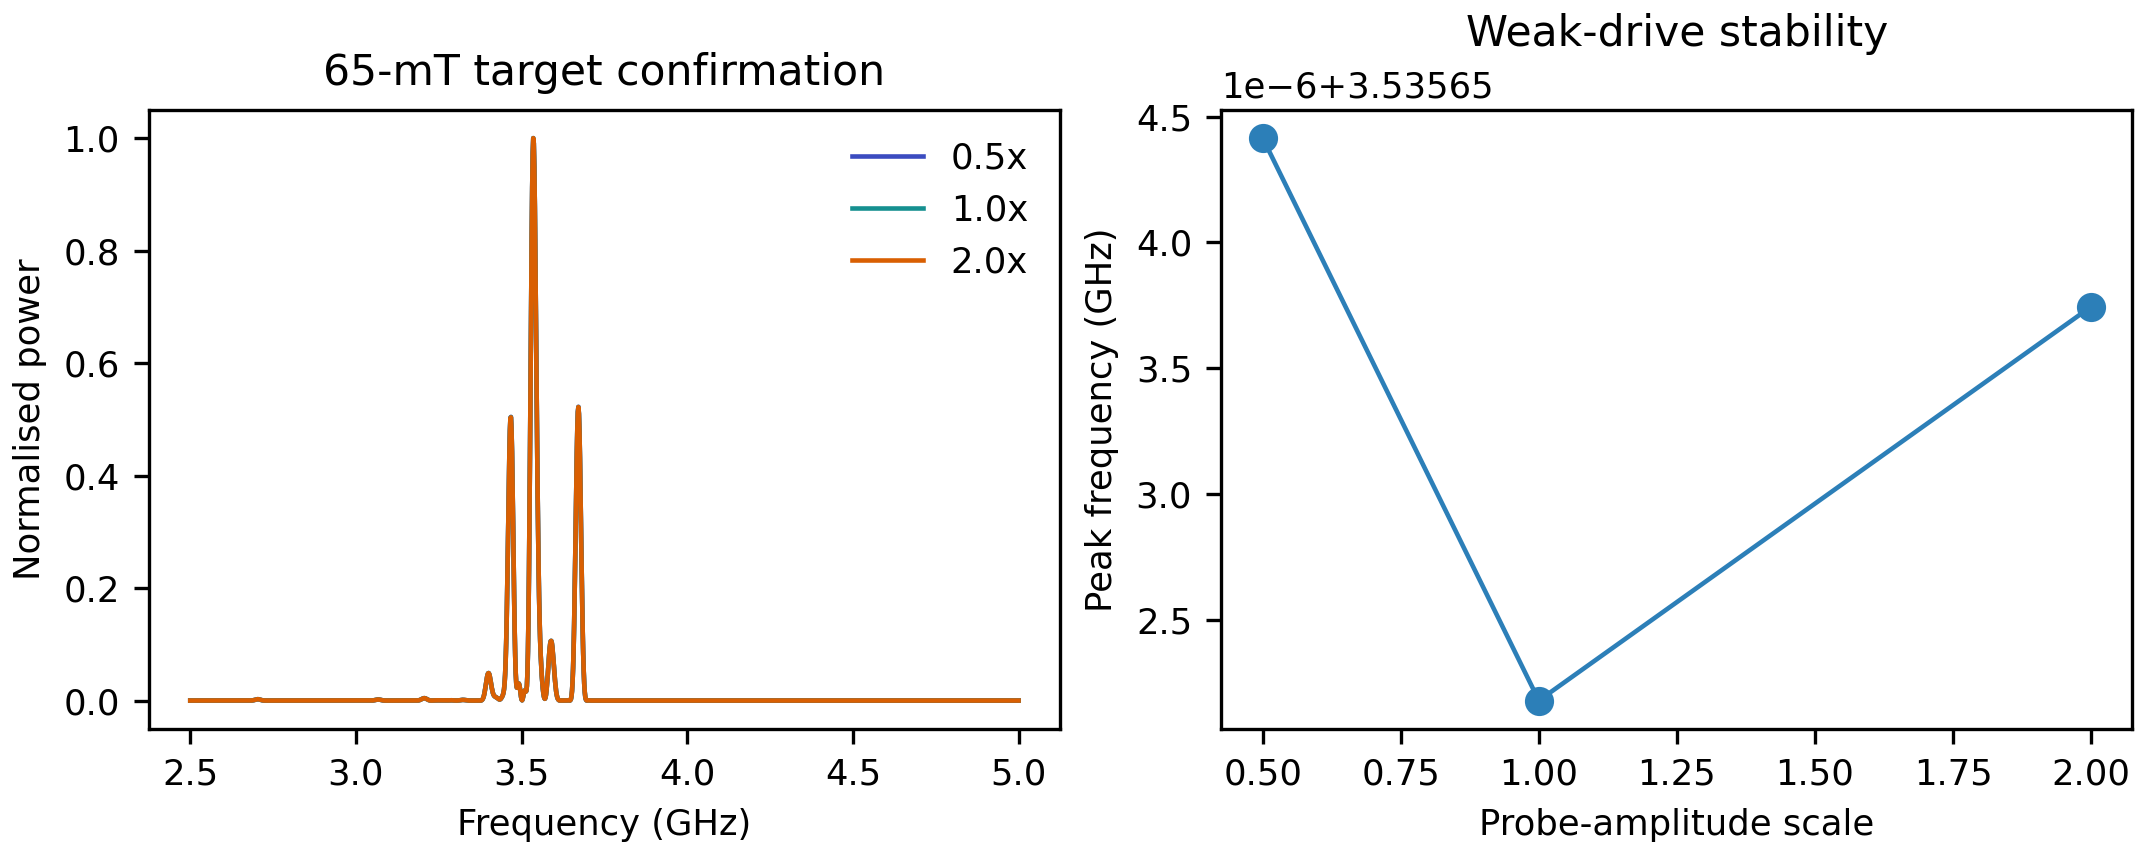

/kaggle/working/jphysd_full_llg_fresh_k01.zip

K01 PASS. The fixed 65-mT target response is identifiable and linear. Next: K02 one common 20-nm full-device equilibrium and paired +/-q0 script generation.


In [12]:
"""Kaggle K01-FRESH: one-bias target-only medium-mesh confirmation.

No bias sweep is performed. A single common equilibrium at the frozen 65-mT
design point is reused by independent 0.5x, 1x and 2x broadband-probe runs.
The first two runs execute concurrently on Kaggle's two T4 GPUs.
"""

from pathlib import Path
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor
import csv
import hashlib
import json
import math
import os
import re
import shutil
import subprocess
import time
import zipfile

import numpy as np


PIPELINE_VERSION = "jphysd-kaggle-full-llg-fresh-k01-v1"
EXPECTED_K00_PIPELINE = "jphysd-kaggle-full-llg-fresh-k00-v1"
EXPECTED_CONFIG_SHA256 = "1342c53516e35e02c0e2629e53ada3b6f4ffbecee7dbe7d0f97221c0c4e5bfde"
EXPECTED_BINARY_SHA256 = "cd048134740e8da1475acd9f8767faaee8ac7061a235f48bd64c1d44a2b98d3b"

ROOT = Path("/kaggle/working/jphysd_full_llg_fresh")
CONFIG_PATH = ROOT/"locks"/"fresh_full_llg_config.json"
K00_MANIFEST = ROOT/"locks"/"k00_manifest.json"
MUMAX = ROOT/"bin"/"mumax3"
STAGE = ROOT/"k01_target_confirmation"
SCRIPTS = STAGE/"scripts"
RUNS = STAGE/"runs"
LOGS = STAGE/"logs"
CACHE = STAGE/"demag_cache"
REPORT_PATH = STAGE/"k01_report.json"
ARCHIVE = Path("/kaggle/working/jphysd_full_llg_fresh_k01.zip")

SCALES = (0.5, 1.0, 2.0)
SEARCH_BAND_HZ = (2.5e9, 5.0e9)
ANALYSIS_START_S = 2.0e-9
DFT_OVERSAMPLING = 8
MINIMUM_POWER_SNR = 10.0
MAXIMUM_PEAK_RELATIVE_SPAN = 0.01
MAXIMUM_RESPONSE_PER_FIELD_CV = 0.10
MAXIMUM_CASE_RUNTIME_S = 2.5*3600


def banner(text):
    print("\n"+"="*78); print(text); print("="*78)


def sha256_file(path):
    digest=hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda:stream.read(1024*1024),b""):
            digest.update(block)
    return digest.hexdigest()


def json_safe(value):
    if isinstance(value,dict): return {str(k):json_safe(v) for k,v in value.items()}
    if isinstance(value,(list,tuple)): return [json_safe(v) for v in value]
    if isinstance(value,np.ndarray): return json_safe(value.tolist())
    if isinstance(value,np.generic): return json_safe(value.item())
    if isinstance(value,Path): return str(value)
    if isinstance(value,float) and not math.isfinite(value): return None
    return value


def write_json(path,value):
    Path(path).parent.mkdir(parents=True,exist_ok=True)
    Path(path).write_text(json.dumps(json_safe(value),indent=2,sort_keys=True,allow_nan=False)+"\n",encoding="utf-8")


def fmt(value): return f"{float(value):.12e}"


def write_locked_script(path,text):
    content=text.encode("utf-8"); path=Path(path); path.parent.mkdir(parents=True,exist_ok=True)
    if path.exists() and path.read_bytes()!=content:
        raise RuntimeError(f"Generated-script conflict on rerun: {path}")
    if not path.exists(): path.write_bytes(content)
    return sha256_file(path)


def target_geometry_lines(config,mesh):
    target=config["geometry"]["target"]
    sx,sy=target["semiaxes_m"]
    cx,cy,_=target["center_m"]
    thickness=config["geometry"]["film_thickness_m"]
    return [
        f"SetGridSize({mesh['nx']}, {mesh['ny']}, 16)",
        f"SetCellSize({fmt(mesh['dx_m'])}, {fmt(mesh['dy_m'])}, {fmt(mesh['dz_m'])})",
        "SetPBC(0,0,0)", "OutputFormat=OVF2_BINARY",
        f"EdgeSmooth={int(config['solver']['edge_smooth'])}",
        f"DemagAccuracy={fmt(config['solver']['demag_accuracy'])}",
        f"targetXY:=Ellipse({fmt(2*sx)},{fmt(2*sy)}).Transl({fmt(cx)},{fmt(cy)},0)",
        f"targetZ:=ZRange({fmt(-thickness/2)},{fmt(thickness/2)})",
        "target:=targetXY.Intersect(targetZ)", "SetGeom(target)",
    ]


def material_lines(config):
    material=config["material"]
    return [
        f"Msat={fmt(material['Msat_A_per_m'])}", f"Aex={fmt(material['Aex_J_per_m'])}",
        f"alpha={fmt(material['alpha'])}", f"Kc1={fmt(material['Kc1_J_per_m3'])}",
        "Dind=0", "Dbulk=0", "Temp=0",
    ]


def equilibrium_script(config,mesh):
    bias=config["bias_and_excitation"]["fixed_bias_T"]; solver=config["solver"]
    lines=["// K01 common target-only medium-mesh equilibrium",f"// config_sha256: {EXPECTED_CONFIG_SHA256}"]
    lines+=target_geometry_lines(config,mesh)+material_lines(config)
    lines += [
        f"B0:={fmt(bias)}", "B_ext=vector(B0,0,0)", "m=uniform(1,1e-3,0)",
        f"MinimizerStop={fmt(solver['minimizer_stop_T'])}",
        f"MinimizerSamples={int(solver['minimizer_samples'])}", "minOK:=Minimize()",
        'Print("MINIMIZE_CONVERGED=",minOK)', 'Print("MAX_TORQUE_T=",maxTorque.Get())',
        'Print("E_TOTAL_J=",E_total.Get())', 'SaveAs(geom,"geom")',
        'SaveAs(regions,"regions")', 'SaveAs(Msat,"Msat")', 'SaveAs(Aex,"Aex")',
        'SaveAs(m,"m_equilibrium")', 'SaveAs(B_demag,"Bdemag_equilibrium")',
        'SaveAs(B_eff,"Beff_equilibrium")', "TableAdd(B_demag)", "TableAdd(E_total)",
        "TableAdd(maxTorque)", "TableSave()", "Flush()", "",
    ]
    return "\n".join(lines)


def dynamic_script(config,mesh,scale,equilibrium_file):
    bias=config["bias_and_excitation"]["fixed_bias_T"]; excitation=config["bias_and_excitation"]
    solver=config["solver"]; amplitude=scale*excitation["target_probe_amplitude_T"]
    duration=excitation["target_only_confirmation_duration_s"]; off=excitation["probe_off_time_s"]
    lines=[
        "// K01 independent weak-probe target confirmation",f"// config_sha256: {EXPECTED_CONFIG_SHA256}",
        f"// amplitude_scale: {scale:.1f}", "// fixed bias; no bias sweep or retuning",
    ]
    lines+=target_geometry_lines(config,mesh)+material_lines(config)
    lines += [
        f"B0:={fmt(bias)}", "B_ext=vector(B0,0,0)", f'm.LoadFile("{equilibrium_file}")',
        "TableAdd(B_ext)", "TableAdd(B_demag)", "TableAdd(E_total)", "TableAdd(maxTorque)",
        f"TableAutoSave({fmt(solver['table_period_s'])})", "TableSave()",
        f"SetSolver({int(solver['dynamic_solver_id'])})", f"MaxErr={fmt(solver['MaxErr'])}",
        f"MaxDt={fmt(solver['MaxDt_s'])}", f"MinDt={fmt(solver['MinDt_s'])}",
        f"Ap:={fmt(amplitude)}", f"bw:={fmt(excitation['target_probe_bandwidth_Hz'])}",
        f"t0:={fmt(excitation['target_probe_center_s'])}",
        "B_ext=vector(B0,Ap*sinc(2*pi*bw*(t-t0)),0)", f"Run({fmt(off)})",
        "B_ext=vector(B0,0,0)", f"Run({fmt(duration-off)})", "TableSave()",
        'SaveAs(m,"m_final")', "Flush()", "",
    ]
    return "\n".join(lines)


def run_logged(command,environment,log_path,timeout_s,heartbeat_label):
    command=[str(x) for x in command]; print("$"," ".join(command),flush=True)
    started=time.time(); log_path=Path(log_path); log_path.parent.mkdir(parents=True,exist_ok=True)
    with log_path.open("w",encoding="utf-8") as log:
        process=subprocess.Popen(command,env=environment,text=True,stdout=log,stderr=subprocess.STDOUT)
        next_beat=started+60; timed_out=False
        while process.poll() is None:
            time.sleep(2); now=time.time()
            if now>=next_beat:
                print(f"[heartbeat {heartbeat_label}] elapsed={now-started:.0f} s",flush=True); next_beat=now+60
            if now-started>timeout_s:
                timed_out=True; process.terminate()
                try: process.wait(timeout=20)
                except subprocess.TimeoutExpired: process.kill()
                break
        returncode=process.wait()
    text=log_path.read_text(encoding="utf-8",errors="replace")
    print(f"[{heartbeat_label}] return={returncode} timeout={timed_out} runtime={time.time()-started:.1f} s")
    for line in text.splitlines()[-12:]: print(f"[{heartbeat_label}] {line}")
    return {"returncode":returncode,"timed_out":timed_out,"runtime_s":time.time()-started,"log":str(log_path),"text":text}


def normalise_label(label): return re.sub(r"[^a-z0-9]","",label.split("(",1)[0].lower())


def parse_table(path):
    path=Path(path); lines=path.read_text(encoding="utf-8",errors="replace").splitlines()
    data=np.loadtxt(path,comments="#"); data=data[None,:] if data.ndim==1 else data
    candidates=[]
    for raw in lines:
        if not raw.lstrip().startswith("#"): continue
        labels=[x.strip() for x in re.split(r"\t+",raw.lstrip()[1:].strip()) if x.strip()]
        names=[normalise_label(x) for x in labels]
        if len(labels)==data.shape[1] and all(x in names for x in ("t","my","mz")):
            candidates.append((labels,names))
    if len(candidates)!=1: raise ValueError(f"Ambiguous table header: {path}")
    labels,names=candidates[0]; index={x:names.index(x) for x in ("t","my","mz")}
    return data,labels,index


def trace(path):
    data,labels,index=parse_table(path)
    t,my,mz=(np.asarray(data[:,index[x]],float) for x in ("t","my","mz"))
    finite=np.isfinite(t)&np.isfinite(my)&np.isfinite(mz); t,my,mz=t[finite],my[finite],mz[finite]
    order=np.argsort(t,kind="stable"); t,my,mz=t[order],my[order],mz[order]
    t,unique=np.unique(t,return_index=True); return t,my[unique],mz[unique],labels,int(data.shape[0])


def complete_dynamic(output,duration):
    table=Path(output)/"table.txt"
    if not table.is_file(): return False
    try:
        t,_,_,_,_=trace(table); return t.size>=3500 and t[-1]>=duration-0.1e-9
    except Exception: return False


def quarantine(path,label):
    path=Path(path)
    if not path.exists(): return None
    destination=STAGE/"incomplete_quarantine"/f"{label}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.out"
    destination.parent.mkdir(parents=True,exist_ok=True); shutil.move(str(path),str(destination)); return destination


def quadratic_peak(frequency,power,index):
    if index<=0 or index>=power.size-1: return float(frequency[index])
    y=np.log(np.maximum(power[index-1:index+2],np.finfo(float).tiny)); d=y[0]-2*y[1]+y[2]
    if not np.isfinite(d) or abs(d)<1e-30: return float(frequency[index])
    offset=float(np.clip(0.5*(y[0]-y[2])/d,-0.5,0.5)); return float(frequency[index]+offset*(frequency[1]-frequency[0]))


def nonuniform_spectrum(t,my,mz):
    keep=t>=ANALYSIS_START_S; t,my,mz=t[keep],my[keep],mz[keep]; duration=float(t[-1]-t[0])
    raw=1/duration; spacing=raw/DFT_OVERSAMPLING
    frequency=np.arange(SEARCH_BAND_HZ[0],SEARCH_BAND_HZ[1]+0.5*spacing,spacing)
    tau=t-t[0]; window=0.5-0.5*np.cos(2*np.pi*tau/duration)
    wy=window*(my-np.average(my,weights=window)); wz=window*(mz-np.average(mz,weights=window))
    power=np.empty(frequency.size)
    for start in range(0,frequency.size,128):
        stop=min(start+128,frequency.size); phase=np.exp(-2j*np.pi*frequency[start:stop,None]*tau[None,:])
        sy,sz=phase@wy,phase@wz; power[start:stop]=np.abs(sy)**2+np.abs(sz)**2
    index=int(np.argmax(power)); peak=quadratic_peak(frequency,power,index)
    noise=power[np.abs(frequency-peak)>3*raw]; floor=float(np.median(noise))
    snr=float(power[index]/max(floor,np.finfo(float).tiny))
    response=float(np.sqrt(power[index])/np.sum(window))
    return frequency,power,peak,raw,snr,response


def uniform_fft_peak(t,my,mz):
    keep=t>=ANALYSIS_START_S; t,my,mz=t[keep],my[keep],mz[keep]
    dt=float(np.median(np.diff(t))); count=int(round((t[-1]-t[0])/dt))+1
    ut=np.linspace(t[0],t[-1],count); uy=np.interp(ut,t,my); uz=np.interp(ut,t,mz); window=np.hanning(count)
    nfft=1
    while nfft<DFT_OVERSAMPLING*count: nfft*=2
    frequency=np.fft.rfftfreq(nfft,ut[1]-ut[0]); power=np.abs(np.fft.rfft(window*(uy-uy.mean()),nfft))**2+np.abs(np.fft.rfft(window*(uz-uz.mean()),nfft))**2
    band=(frequency>=SEARCH_BAND_HZ[0])&(frequency<=SEARCH_BAND_HZ[1]); indices=np.flatnonzero(band); index=int(indices[np.argmax(power[band])])
    return quadratic_peak(frequency,power,index)


banner("KAGGLE FULL-LLG FRESH — CELL K01 SINGLE-BIAS TARGET CONFIRMATION")
started=time.time(); checks={}; report={"pipeline_version":PIPELINE_VERSION,"stage":"K01_single_bias_medium_target_confirmation","status":"FAIL_K01","checks":checks,"failed_checks":[],"started_utc":datetime.now(timezone.utc).isoformat(),"scientific_scope":"Fresh target-only confirmation at one pre-fixed 65-mT design point; no bias scan, no splitting, no conditionality and no CNOT claim."}

try:
    print("PHASE 1/6 — validate K00 locks")
    config=json.loads(CONFIG_PATH.read_text(encoding="utf-8")); k00=json.loads(K00_MANIFEST.read_text(encoding="utf-8"))
    checks["K00_PASS"]=k00.get("pipeline_version")==EXPECTED_K00_PIPELINE and k00.get("status")=="PASS_K00_FRESH" and not k00.get("failed_checks")
    checks["config_hash_matches"]=sha256_file(CONFIG_PATH)==EXPECTED_CONFIG_SHA256
    checks["binary_hash_matches"]=sha256_file(MUMAX)==EXPECTED_BINARY_SHA256
    checks["fixed_bias_65mT"]=config["bias_and_excitation"]["fixed_bias_T"]==0.065
    if not all(checks.values()): raise RuntimeError("K00 lock validation failed")
    for directory in (STAGE,SCRIPTS,RUNS,LOGS,CACHE): directory.mkdir(parents=True,exist_ok=True)
    medium=next(x for x in config["meshes"] if x["label"]=="medium")
    environment=os.environ.copy(); environment["LD_LIBRARY_PATH"]=k00["dynamic_linking"]["LD_LIBRARY_PATH"]

    print("PHASE 2/6 — generate scripts and vet the common equilibrium")
    eq_script=SCRIPTS/"target_medium_equilibrium.mx3"; eq_hash=write_locked_script(eq_script,equilibrium_script(config,medium))
    eq_output=RUNS/"target_medium_equilibrium.out"; equilibrium_file=eq_output/"m_equilibrium.ovf"
    dynamics=[]
    for scale in SCALES:
        label=f"A{scale:.1f}x".replace(".","p"); path=SCRIPTS/f"target_medium_{label}.mx3"
        dynamics.append({"scale":scale,"label":label,"path":path,"sha256":write_locked_script(path,dynamic_script(config,medium,scale,equilibrium_file)),"output":RUNS/f"target_medium_{label}.out"})
    vet=subprocess.run([str(MUMAX),"-vet","-f","-http=",str(eq_script)],env=environment,text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,timeout=300)
    print(f"vet {eq_script.name}: return={vet.returncode}")
    checks["equilibrium_script_vet"]=vet.returncode==0
    if not checks["equilibrium_script_vet"]: raise RuntimeError("Equilibrium syntax-vet failed")

    print("PHASE 3/6 — common equilibrium and demag cache")
    eq_reused=equilibrium_file.is_file()
    if eq_reused:
        print("Reusing completed common equilibrium checkpoint")
        eq_run={"returncode":0,"timed_out":False,"runtime_s":0.0,"log":"checkpoint","text":"MINIMIZE_CONVERGED= true"}
    else:
        quarantine(eq_output,"equilibrium")
        eq_run=run_logged([MUMAX,"-gpu=0","-failfast","-http=","-cache",CACHE,"-o",eq_output,eq_script],environment,LOGS/"equilibrium.log",1800,"equilibrium")
    torque_match=re.search(r"MAX_TORQUE_T=\s*([+\-0-9.eE]+)",eq_run["text"])
    max_torque=float(torque_match.group(1)) if torque_match else None
    checks["equilibrium_completed"]=eq_run["returncode"]==0 and equilibrium_file.is_file() and "MINIMIZE_CONVERGED= true" in eq_run["text"]
    checks["equilibrium_torque_below_2uT"]=(max_torque is None and eq_reused) or (max_torque is not None and max_torque<=2e-6)
    if not checks["equilibrium_completed"]: raise RuntimeError("Common equilibrium failed")

    # Vet dynamics only after the locked equilibrium file exists. This remains
    # compatible with MuMax builds that validate LoadFile paths during -vet.
    dynamic_vet_ok=True
    for item in dynamics:
        vet=subprocess.run([str(MUMAX),"-vet","-f","-http=",str(item["path"])],env=environment,text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,timeout=300)
        print(f"vet {item['path'].name}: return={vet.returncode}")
        dynamic_vet_ok &= vet.returncode==0
    checks["all_scripts_vet"]=checks["equilibrium_script_vet"] and bool(dynamic_vet_ok)
    if not checks["all_scripts_vet"]: raise RuntimeError("Dynamic-script syntax-vet failed")

    print("PHASE 4/6 — paired GPU execution, then final amplitude")
    duration=config["bias_and_excitation"]["target_only_confirmation_duration_s"]
    def execute(item,gpu):
        if complete_dynamic(item["output"],duration):
            print(f"{item['label']}: reusing complete checkpoint"); return {"returncode":0,"timed_out":False,"runtime_s":0.0,"log":"checkpoint","text":"REUSED","reused":True,"gpu":gpu}
        quarantine(item["output"],item["label"])
        result=run_logged([MUMAX,f"-gpu={gpu}","-failfast","-http=","-cache",CACHE,"-o",item["output"],item["path"]],environment,LOGS/f"{item['label']}.log",MAXIMUM_CASE_RUNTIME_S,item["label"])
        result.update({"reused":False,"gpu":gpu}); return result
    with ThreadPoolExecutor(max_workers=2) as pool:
        futures=[pool.submit(execute,dynamics[0],0),pool.submit(execute,dynamics[1],1)]
        pair=[future.result() for future in futures]
    third=execute(dynamics[2],0); execution=pair+[third]
    for item,result in zip(dynamics,execution): result.update({"scale":item["scale"],"label":item["label"],"output":str(item["output"]),"script_sha256":item["sha256"]})
    report["execution"]={"equilibrium":eq_run,"dynamics":execution,"equilibrium_reused":eq_reused}
    checks["all_three_dynamics_complete"]=all(x["returncode"]==0 and not x["timed_out"] and complete_dynamic(item["output"],duration) for item,x in zip(dynamics,execution))
    if not checks["all_three_dynamics_complete"]: raise RuntimeError("At least one amplitude case failed")

    print("PHASE 5/6 — identical blind spectra and linearity decision")
    results=[]
    for item in dynamics:
        table=item["output"]/"table.txt"; t,my,mz,labels,rows=trace(table); frequency,power,peak,raw,snr,response=nonuniform_spectrum(t,my,mz); fft_peak=uniform_fft_peak(t,my,mz); dt=np.diff(t)
        results.append({"scale":item["scale"],"field_T":item["scale"]*config["bias_and_excitation"]["target_probe_amplitude_T"],"table":str(table),"table_sha256":sha256_file(table),"rows":rows,"samples":int(t.size),"end_s":float(t[-1]),"median_dt_s":float(np.median(dt)),"maximum_dt_s":float(np.max(dt)),"NUDFT_peak_Hz":peak,"FFT_peak_Hz":fft_peak,"method_difference_Hz":abs(peak-fft_peak),"raw_resolution_Hz":raw,"power_SNR":snr,"modal_response":response,"_frequency":frequency,"_power":power})
        print(f"scale={item['scale']:.1f}x | peak={peak*1e-9:.7f} GHz | FFT-NUDFT={abs(peak-fft_peak)*1e-6:.3f} MHz | SNR={snr:.1f}")
    peaks=np.array([x["NUDFT_peak_Hz"] for x in results]); fields=np.array([x["field_T"] for x in results]); responses=np.array([x["modal_response"] for x in results]); response_per_field=responses/fields
    peak_span=float(np.ptp(peaks)/np.mean(peaks)); response_cv=float(np.std(response_per_field,ddof=1)/np.mean(response_per_field))
    checks["all_tables_complete_and_finite"]=all(x["samples"]>=3500 and x["end_s"]>=duration-0.1e-9 for x in results)
    checks["all_max_gaps_resolve_5GHz"]=all(x["maximum_dt_s"]<=1/(4*SEARCH_BAND_HZ[1]) for x in results)
    checks["all_methods_agree_within_raw_bin"]=all(x["method_difference_Hz"]<=x["raw_resolution_Hz"] for x in results)
    checks["all_power_SNR_at_least_10"]=all(x["power_SNR"]>=MINIMUM_POWER_SNR for x in results)
    checks["peak_centres_stable_below_1pct"]=peak_span<=MAXIMUM_PEAK_RELATIVE_SPAN
    checks["response_per_field_CV_below_10pct"]=response_cv<=MAXIMUM_RESPONSE_PER_FIELD_CV
    checks["dominant_mode_not_at_search_boundary"]=all(SEARCH_BAND_HZ[0]+50e6<x["NUDFT_peak_Hz"]<SEARCH_BAND_HZ[1]-50e6 for x in results)
    report["linearity"]={"peak_relative_span":peak_span,"response_per_field_CV":response_cv,"response_per_field":response_per_field}

    print("PHASE 6/6 — report, figure and archive")
    import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
    plt.rcParams.update({"font.size":8.5,"axes.linewidth":0.8,"lines.linewidth":1.1})
    fig,axes=plt.subplots(1,2,figsize=(7.15,2.85),constrained_layout=True); colors=("#3b4cc0","#159090","#d95f02")
    for result,color in zip(results,colors): axes[0].plot(result["_frequency"]*1e-9,result["_power"]/np.max(result["_power"]),color=color,label=f"{result['scale']:.1f}x")
    axes[0].set(xlabel="Frequency (GHz)",ylabel="Normalised power",title="65-mT target confirmation"); axes[0].legend(frameon=False)
    axes[1].plot(np.array(SCALES),peaks*1e-9,"o-",color="#2c7fb8"); axes[1].set(xlabel="Probe-amplitude scale",ylabel="Peak frequency (GHz)",title="Weak-drive stability")
    png=STAGE/"k01_target_confirmation.png"; pdf=STAGE/"k01_target_confirmation.pdf"; fig.savefig(png,dpi=300); fig.savefig(pdf); plt.close(fig)
    public=[]
    for result in results: public.append({k:v for k,v in result.items() if not k.startswith("_")})
    report["results"]=public; required=["K00_PASS","config_hash_matches","binary_hash_matches","fixed_bias_65mT","all_scripts_vet","equilibrium_completed","equilibrium_torque_below_2uT","all_three_dynamics_complete","all_tables_complete_and_finite","all_max_gaps_resolve_5GHz","all_methods_agree_within_raw_bin","all_power_SNR_at_least_10","peak_centres_stable_below_1pct","response_per_field_CV_below_10pct","dominant_mode_not_at_search_boundary"]
    report["required_checks"]=required; report["failed_checks"]=[name for name in required if not checks.get(name,False)]; report["status"]="PASS_K01_TARGET" if not report["failed_checks"] else "FAIL_K01_TARGET"

except Exception as error:
    report["exception"]={"type":type(error).__name__,"message":str(error)}; report["failed_checks"]=[name for name,value in checks.items() if not value] or ["K01_exception"]

report["runtime_s"]=time.time()-started; report["finished_utc"]=datetime.now(timezone.utc).isoformat(); write_json(REPORT_PATH,report)
manifest={}
for path in sorted(x for x in STAGE.rglob("*") if x.is_file() and "demag_cache" not in x.parts): manifest[path.relative_to(STAGE).as_posix()]={"bytes":path.stat().st_size,"sha256":sha256_file(path)}
write_json(STAGE/"k01_file_manifest.json",manifest)
if ARCHIVE.exists(): ARCHIVE.unlink()
with zipfile.ZipFile(ARCHIVE,"w",zipfile.ZIP_DEFLATED,allowZip64=True) as archive:
    for path in sorted(x for x in STAGE.rglob("*") if x.is_file() and "demag_cache" not in x.parts): archive.write(path,arcname=path.relative_to(STAGE).as_posix())
banner(f"CELL K01 COMPLETE | {report['status']}")
print(json.dumps(json_safe({"status":report["status"],"failed_checks":report["failed_checks"],"peak_GHz":[x["NUDFT_peak_Hz"]*1e-9 for x in report.get("results",[])],"peak_relative_span":report.get("linearity",{}).get("peak_relative_span"),"response_per_field_CV":report.get("linearity",{}).get("response_per_field_CV"),"runtime_s":report["runtime_s"],"report":REPORT_PATH,"archive":ARCHIVE}),indent=2,allow_nan=False))
try:
    from IPython.display import FileLink,Image,display
    if (STAGE/"k01_target_confirmation.png").is_file(): display(Image(filename=str(STAGE/"k01_target_confirmation.png")))
    display(FileLink(str(ARCHIVE)))
except Exception: pass
if report["status"]!="PASS_K01_TARGET": raise RuntimeError(f"K01 failed; do not start full geometry. Failed checks: {report['failed_checks']} | exception={report.get('exception')}")
print("K01 PASS. The fixed 65-mT target response is identifiable and linear. Next recommended manuscript-evidence branch: K05 explicit double-well modes. K02--K04B are retained below as an optional exploratory branch.")


## 3. Explicit field-defined double-well mode audit

K05–K05D establish the even/odd spatial mode identities and test whether their frequency separation is resolution validated. The final result is qualitative mode-pair evidence: the apparent separation remains below the native (1/T) resolution and is not converted into a measured (K).


K05 — EXPLICIT DOUBLE-WELL SYMMETRIC/ANTISYMMETRIC MODE TEST
PHASE 1/6 — generate and vet equilibrium
//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-10.2]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 2, MHz: 2000.174
//GPU info: Tesla T4(14911MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 5a648f3e6a30
//Timestamp: 2026-07-21 10:56:04
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
/kaggle/working/jphysd_explicit_double_well/scripts/double_well_equilibrium.mx3 : OK

PHASE 2/6 — common barrier equilibrium
$ /kaggle/working/jphysd_full_llg_fresh/bin/mumax3

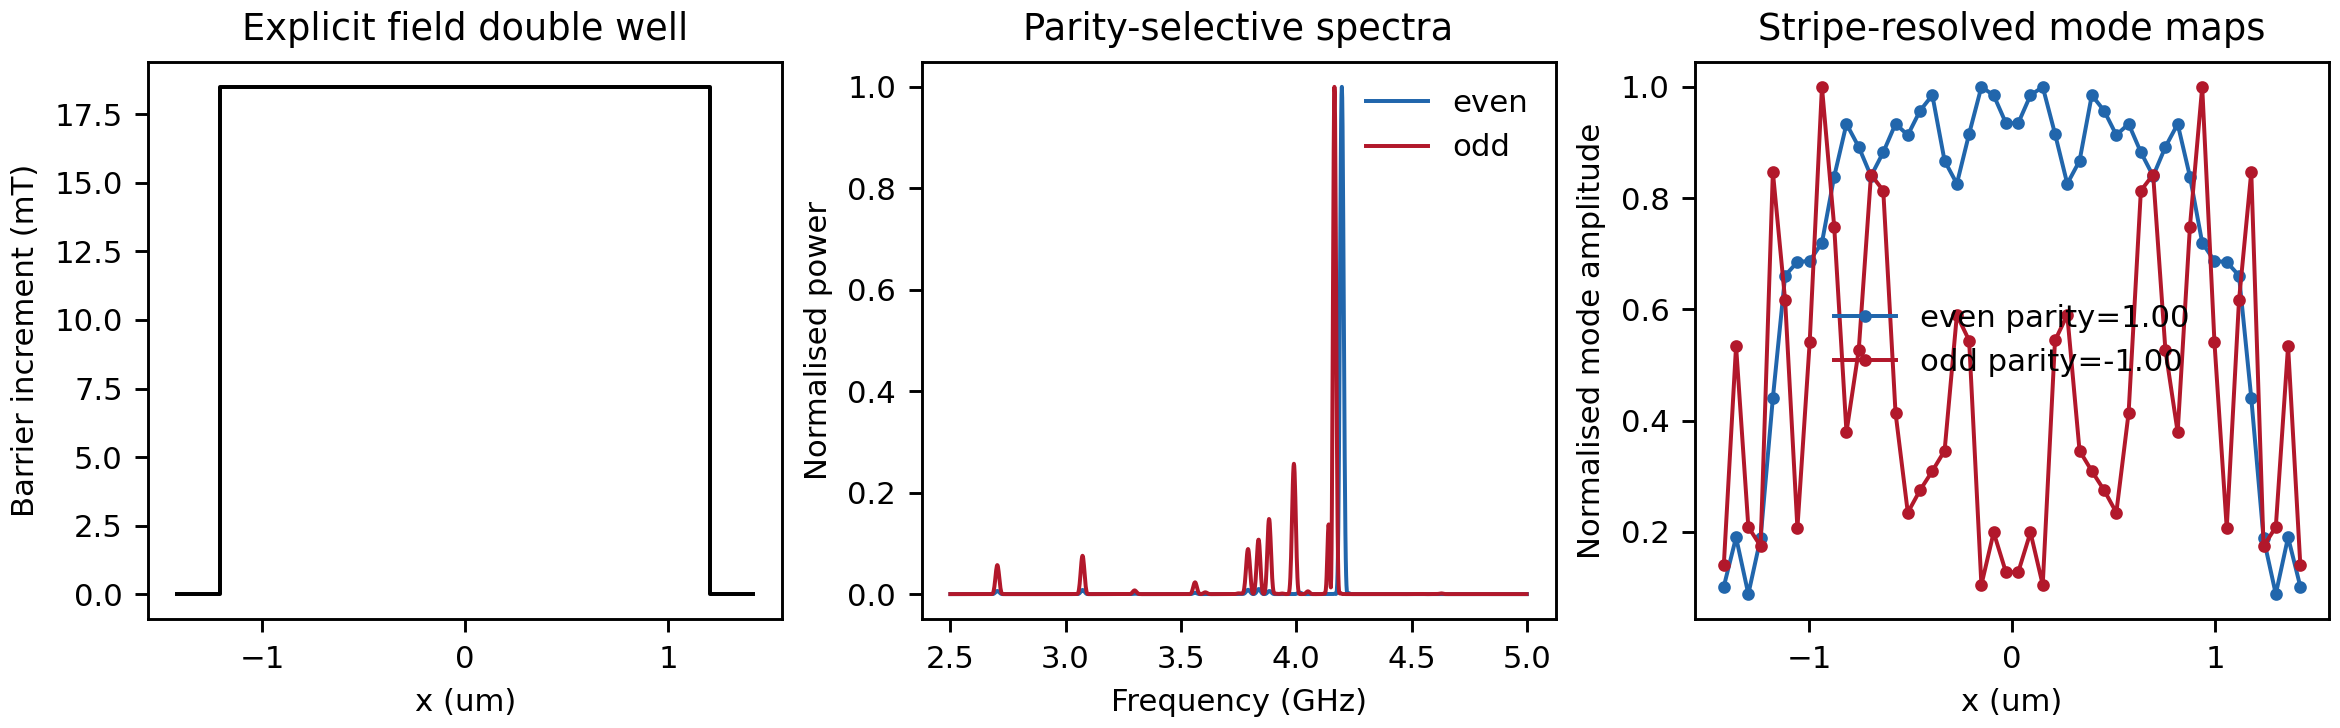

/kaggle/working/jphysd_explicit_double_well_k05.zip

K05 explicit double-well mode audit passed. Interpret splitting only if parity checks pass and the splitting exceeds the raw resolution; conditional control modulation and mesh convergence remain separate tests.


In [20]:
"""Kaggle K05-DW: explicit field-defined double well and even/odd LLG modes.

Run after K00 in the same session. The target is the
published 64-nm YIG ellipse. A meshed 2.4-um-wide central longitudinal Zeeman
barrier of 18.506 mT creates two edge wells. Uniform and left/right-odd weak
pulses independently excite symmetric and antisymmetric mode sectors.

Scientific boundary: the barrier is an explicit prescribed field region, not
a self-consistent receiver/antenna calculation. This tests the WKB double-well
assumption but does not by itself demonstrate conditionality or a CNOT.
"""
from pathlib import Path
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor
import hashlib, json, math, os, re, shutil, subprocess, time, zipfile
import numpy as np

PIPELINE_VERSION="jphysd-k05-explicit-double-well-v1"
EXPECTED_K00_PIPELINE="jphysd-kaggle-full-llg-fresh-k00-v1"
EXPECTED_BINARY_SHA256="cd048134740e8da1475acd9f8767faaee8ac7061a235f48bd64c1d44a2b98d3b"
BASE=Path("/kaggle/working/jphysd_full_llg_fresh"); K00=BASE/"locks"/"k00_manifest.json"; MUMAX=BASE/"bin"/"mumax3"
ROOT=Path("/kaggle/working/jphysd_explicit_double_well"); SCRIPTS=ROOT/"scripts"; RUNS=ROOT/"runs"; LOGS=ROOT/"logs"; CACHE=ROOT/"demag_cache"
CONFIG=ROOT/"explicit_double_well_config.json"; REPORT=ROOT/"k05_double_well_report.json"; ARCHIVE=Path("/kaggle/working/jphysd_explicit_double_well_k05.zip")
MAX_RUNTIME=3.25*3600; SEARCH=(2.5e9,5.0e9); ANALYSIS_START=2e-9; OVERSAMPLE=8

def banner(x): print("\n"+"="*78+"\n"+x+"\n"+"="*78)
def fmt(x): return f"{float(x):.12e}"
def sha(p):
 h=hashlib.sha256()
 with Path(p).open("rb") as f:
  for b in iter(lambda:f.read(1048576),b""): h.update(b)
 return h.hexdigest()
def safe(x):
 if isinstance(x,Path): return str(x)
 if isinstance(x,np.generic): return x.item()
 if isinstance(x,np.ndarray): return x.tolist()
 if isinstance(x,dict): return {str(k):safe(v) for k,v in x.items()}
 if isinstance(x,(list,tuple)): return [safe(v) for v in x]
 return x
def write_json(p,x): p.parent.mkdir(parents=True,exist_ok=True); p.write_text(json.dumps(safe(x),indent=2,sort_keys=True,allow_nan=False)+"\n")
def locked(p,text):
 b=(text.rstrip()+"\n").encode(); p.parent.mkdir(parents=True,exist_ok=True)
 if p.exists() and p.read_bytes()!=b: raise RuntimeError(f"Immutable script conflict: {p}")
 if not p.exists(): p.write_bytes(b)
 return sha(p)
def config_value():
 return {"pipeline_version":PIPELINE_VERSION,"scope":"Target-only medium-mesh explicit field-defined double-well mode-pair test; prescribed barrier, no receiver circuit, conditionality, or CNOT claim.","material":{"Msat_A_per_m":140e3,"Aex_J_per_m":3.5e-12,"alpha":2e-4,"Kc1_J_per_m3":0.0,"temperature_K":0.0},"geometry":{"target_semiaxes_m":[1.45e-6,0.62e-6],"thickness_m":64e-9,"box_m":[3.6e-6,1.6e-6,128e-9],"mesh":[180,80,16],"cell_m":[20e-9,20e-9,8e-9],"x_stripes":48,"first_region":10},"field_double_well":{"bias_T":0.065,"barrier_width_m":2.4e-6,"barrier_increment_T":18.506e-3,"barrier_role":"Explicit meshed longitudinal Zeeman potential; prescribed model input."},"excitation":{"amplitude_T":20e-6,"bandwidth_Hz":10e9,"center_s":0.2e-9,"pulse_stage_end_s":1e-9,"duration_s":80e-9,"table_period_s":20e-12,"cases":{"even":"uniform transverse pulse","odd":"left/right sign-changing transverse pulse"}},"solver":{"edge_smooth":8,"demag_accuracy":6.0,"minimizer_stop_T":1e-6,"minimizer_samples":10,"solver_id":5,"MaxErr":1e-5,"MaxDt_s":5e-12,"MinDt_s":1e-16},"acceptance":{"SNR_minimum":10.0,"fit_parity_absolute_minimum":0.70,"splitting_resolved_only_if_above_raw_resolution":True}}
def stripe_meta(c):
 g=c["geometry"]; sx=g["target_semiaxes_m"][0]; n=g["x_stripes"]; w=2*sx/n; out=[]
 for i in range(n):
  left=-sx+i*w; right=left+w; center=(left+right)/2; out.append({"region":g["first_region"]+i,"left":left,"right":right,"center":center,"barrier":abs(center)<c["field_double_well"]["barrier_width_m"]/2})
 return out
def geometry(c):
 g=c["geometry"]; sx,sy=g["target_semiaxes_m"]; nx,ny,nz=g["mesh"]; dx,dy,dz=g["cell_m"]
 L=[f"SetGridSize({nx},{ny},{nz})",f"SetCellSize({fmt(dx)},{fmt(dy)},{fmt(dz)})","SetPBC(0,0,0)","OutputFormat=OVF2_BINARY",f"EdgeSmooth={c['solver']['edge_smooth']}",f"DemagAccuracy={fmt(c['solver']['demag_accuracy'])}",f"targetXY:=Ellipse({fmt(2*sx)},{fmt(2*sy)})",f"targetZ:=ZRange({fmt(-g['thickness_m']/2)},{fmt(g['thickness_m']/2)})","target:=targetXY.Intersect(targetZ)","SetGeom(target)"]
 for q in stripe_meta(c): L.append(f"DefRegion({q['region']},target.Intersect(XRange({fmt(q['left'])},{fmt(q['right'])})))")
 return L
def material(c):
 m=c["material"]; return [f"Msat={fmt(m['Msat_A_per_m'])}",f"Aex={fmt(m['Aex_J_per_m'])}",f"alpha={fmt(m['alpha'])}",f"Kc1={fmt(m['Kc1_J_per_m3'])}","Dind=0","Dbulk=0","Temp=0"]
def static_field_lines(c):
 b=c["field_double_well"]; L=[f"B0:={fmt(b['bias_T'])}",f"Bbar:={fmt(b['barrier_increment_T'])}","B_ext=vector(B0,0,0)"]
 for q in stripe_meta(c):
  if q["barrier"]: L.append(f"B_ext.SetRegion({q['region']},vector(B0+Bbar,0,0))")
 return L
def restore_static_field_lines(c):
 L=["B_ext=vector(B0,0,0)"]
 for q in stripe_meta(c):
  if q["barrier"]: L.append(f"B_ext.SetRegion({q['region']},vector(B0+Bbar,0,0))")
 return L
def equilibrium_script(c):
 s=c["solver"]; L=["// K05 explicit field-defined double-well equilibrium"]+geometry(c)+material(c)+static_field_lines(c)
 L += ["m=uniform(1,1e-3,0)",f"MinimizerStop={fmt(s['minimizer_stop_T'])}",f"MinimizerSamples={s['minimizer_samples']}","ok:=Minimize()",'Print("MINIMIZE_CONVERGED=",ok)','Print("MAX_TORQUE_T=",maxTorque.Get())','Print("E_TOTAL_J=",E_total.Get())','SaveAs(geom,"geom")','SaveAs(regions,"regions")','SaveAs(B_ext,"barrier_field")','SaveAs(m,"m_equilibrium")','SaveAs(B_demag,"Bdemag_equilibrium")','SaveAs(B_eff,"Beff_equilibrium")',"TableAdd(E_total)","TableAdd(maxTorque)","TableSave()","Flush()"]
 return "\n".join(L)
def dynamic_script(c,case,eq):
 s=c["solver"]; e=c["excitation"]; L=[f"// K05 parity-selective {case} excitation"]+geometry(c)+material(c)+static_field_lines(c)+[f'm.LoadFile("{eq}")']
 for q in stripe_meta(c): L.append(f"TableAdd(m.Region({q['region']}))")
 L += ["TableAdd(E_total)","TableAdd(maxTorque)",f"TableAutoSave({fmt(e['table_period_s'])})","TableSave()",f"SetSolver({s['solver_id']})",f"MaxErr={fmt(s['MaxErr'])}",f"MaxDt={fmt(s['MaxDt_s'])}",f"MinDt={fmt(s['MinDt_s'])}",f"Ap:={fmt(e['amplitude_T'])}",f"bw:={fmt(e['bandwidth_Hz'])}",f"t0:={fmt(e['center_s'])}"]
 for q in stripe_meta(c):
  sign=1 if case=="even" or q["center"]<0 else -1; bx="B0+Bbar" if q["barrier"] else "B0"; L.append(f"B_ext.SetRegion({q['region']},vector({bx},{sign}*Ap*sinc(2*pi*bw*(t-t0)),0))")
 L += [f"Run({fmt(e['pulse_stage_end_s'])})"]+restore_static_field_lines(c)+[f"Run({fmt(e['duration_s']-e['pulse_stage_end_s'])})","TableSave()",f'SaveAs(m,"m_final_{case}")',"Flush()"]
 return "\n".join(L)
def run(cmd,env,log,timeout,label):
 cmd=[str(x) for x in cmd]; print("$"," ".join(cmd),flush=True); t0=time.time(); log.parent.mkdir(parents=True,exist_ok=True)
 with log.open("w") as f:
  p=subprocess.Popen(cmd,env=env,text=True,stdout=f,stderr=subprocess.STDOUT); beat=t0+60; timed=False
  while p.poll() is None:
   time.sleep(2)
   if time.time()>=beat: print(f"[{label}] running {time.time()-t0:.0f} s",flush=True); beat+=60
   if time.time()-t0>timeout: p.kill(); timed=True; break
  rc=p.wait()
 text=log.read_text(errors="replace"); print(text[-3500:]); print(f"[{label}] return={rc} timeout={timed} runtime={time.time()-t0:.1f} s"); return {"returncode":rc,"timed_out":timed,"runtime_s":time.time()-t0,"log":str(log),"text":text}
def load_table(path):
 lines=Path(path).read_text(errors="replace").splitlines(); rows=[]
 for s in lines:
  if not s.strip() or s.lstrip().startswith("#"): continue
  try: rows.append([float(x) for x in s.split()])
  except ValueError: pass
 width=max(map(len,rows)); a=np.asarray([r for r in rows if len(r)==width],float); heads=[]
 for s in lines:
  if s.lstrip().startswith("#"):
   q=[x.strip() for x in re.split(r"\t+",s.lstrip()[1:].strip()) if x.strip()]
   if len(q)==width: heads.append(q)
 labels=max(heads,key=lambda q:sum("region" in x.lower() for x in q)); a=a[np.isfinite(a).all(axis=1)]; a=a[np.argsort(a[:,0])]; _,u=np.unique(a[:,0],return_index=True); return labels,a[u]
def columns(labels,r):
 out=[]
 for i,s in enumerate(labels):
  compact=re.sub(r"[^a-z0-9]","",s.lower().split("(",1)[0])
  if re.match(rf"^mregion{r}[xyz]$",compact): out.append(i)
 if len(out)!=3: raise RuntimeError(f"region {r}: expected 3 m columns, found {len(out)}")
 return out
def analyse(path,c,case):
 labels,a=load_table(path); meta=stripe_meta(c); idx=np.asarray([columns(labels,q["region"]) for q in meta]); t=a[:,0]; M=a[:,idx]; keep=t>=ANALYSIS_START; t=t[keep]; M=M[keep]; dt=float(np.median(np.diff(t))); u=np.arange(t[0],t[-1]+dt/4,dt); U=np.empty((u.size,len(meta),3))
 for j in range(len(meta)):
  for k in range(3): U[:,j,k]=np.interp(u,t,M[:,j,k])
 signs=np.asarray([1 if case=="even" or q["center"]<0 else -1 for q in meta]); y=np.mean(U[:,:,1]*signs[None,:],axis=1); z=np.mean(U[:,:,2]*signs[None,:],axis=1); w=np.hanning(u.size); nfft=1
 while nfft<OVERSAMPLE*u.size: nfft*=2
 F=np.fft.rfftfreq(nfft,dt); FY=np.fft.rfft(w[:,None]*(U[:,:,1]-np.mean(U[:,:,1],axis=0)),nfft,axis=0); FZ=np.fft.rfft(w[:,None]*(U[:,:,2]-np.mean(U[:,:,2],axis=0)),nfft,axis=0); aggY=np.fft.rfft(w*(y-y.mean()),nfft); aggZ=np.fft.rfft(w*(z-z.mean()),nfft); P=np.abs(aggY)**2+np.abs(aggZ)**2; band=(F>=SEARCH[0])&(F<=SEARCH[1]); ids=np.flatnonzero(band); peak_idx=ids[np.argmax(P[band])]; raw=1/(u[-1]-u[0]); noise=P[band & (np.abs(F-F[peak_idx])>3*raw)]; vec=np.r_[FY[peak_idx],FZ[peak_idx]]; rev=np.r_[FY[peak_idx][::-1],FZ[peak_idx][::-1]]; parity=float(np.real(np.vdot(vec,rev))/max(np.linalg.norm(vec)*np.linalg.norm(rev),1e-300)); stripe_amp=np.sqrt(np.abs(FY[peak_idx])**2+np.abs(FZ[peak_idx])**2)
 return {"case":case,"samples":int(t.size),"end_s":float(t[-1]),"median_dt_s":dt,"peak_Hz":float(F[peak_idx]),"raw_resolution_Hz":float(raw),"power_SNR":float(P[peak_idx]/max(np.median(noise),np.finfo(float).tiny)),"parity_correlation":parity,"expected_parity":1 if case=="even" else -1,"stripe_centers_m":np.asarray([q["center"] for q in meta]),"stripe_mode_amplitude":stripe_amp,"frequency":F[band],"power":P[band]}

banner("K05 — EXPLICIT DOUBLE-WELL SYMMETRIC/ANTISYMMETRIC MODE TEST")
t0=time.time(); checks={}; report={"pipeline_version":PIPELINE_VERSION,"stage":"K05_explicit_field_double_well_modes","status":"FAIL_K05","checks":checks,"failed_checks":[],"started_utc":datetime.now(timezone.utc).isoformat(),"scientific_scope":"Target-only 3D LLG test of a meshed prescribed 2.4-um, 18.506-mT longitudinal barrier and its even/odd mode pair; no receiver circuit, conditional modulation, or CNOT claim."}
try:
 k00=json.loads(K00.read_text()); checks["K00_PASS"]=k00.get("pipeline_version")==EXPECTED_K00_PIPELINE and k00.get("status")=="PASS_K00_FRESH"; checks["binary_hash_matches"]=sha(MUMAX)==EXPECTED_BINARY_SHA256
 if not all(checks.values()): raise RuntimeError("K00 environment chain failed")
 c=config_value(); ROOT.mkdir(parents=True,exist_ok=True)
 if CONFIG.exists() and json.loads(CONFIG.read_text())!=c: raise RuntimeError("Explicit-double-well configuration conflict")
 write_json(CONFIG,c)
 for d in (SCRIPTS,RUNS,LOGS,CACHE): d.mkdir(parents=True,exist_ok=True)
 env=os.environ.copy(); env["LD_LIBRARY_PATH"]=k00["dynamic_linking"]["LD_LIBRARY_PATH"]
 print("PHASE 1/6 — generate and vet equilibrium")
 eqs=SCRIPTS/"double_well_equilibrium.mx3"; eqh=locked(eqs,equilibrium_script(c)); eqo=RUNS/"double_well_equilibrium.out"; eq=eqo/"m_equilibrium.ovf"; v=subprocess.run([MUMAX,"-vet","-f","-http=",eqs],env=env,text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,timeout=300); print(v.stdout[-2000:]); checks["equilibrium_vet"]=v.returncode==0
 if not checks["equilibrium_vet"]: raise RuntimeError("equilibrium vet failed")
 print("PHASE 2/6 — common barrier equilibrium")
 if eq.is_file(): er={"returncode":0,"timed_out":False,"runtime_s":0.0,"log":"checkpoint","text":"MINIMIZE_CONVERGED= true","reused":True}
 else:
  if eqo.exists(): shutil.move(str(eqo),str(ROOT/f"incomplete_equilibrium_{datetime.now().strftime('%Y%m%d_%H%M%S')}.out"))
  er=run([MUMAX,"-gpu=0","-failfast","-http=","-cache",CACHE,"-o",eqo,eqs],env,LOGS/"equilibrium.log",1800,"equilibrium"); er["reused"]=False
 torque_match=re.search(r"MAX_TORQUE_T=\s*([+\-0-9.eE]+)",er["text"]); torque=float(torque_match.group(1)) if torque_match else None; checks["equilibrium_complete"]=er["returncode"]==0 and not er["timed_out"] and eq.is_file() and "MINIMIZE_CONVERGED= true" in er["text"]; checks["equilibrium_torque_below_2uT"]=(er["reused"] and torque is None) or (torque is not None and torque<=2e-6)
 if not checks["equilibrium_complete"]: raise RuntimeError("equilibrium failed")
 print("PHASE 3/6 — generate and vet even/odd probes")
 cases=[]
 for case in ("even","odd"):
  p=SCRIPTS/f"double_well_{case}_probe_80ns.mx3"; h=locked(p,dynamic_script(c,case,eq)); vv=subprocess.run([MUMAX,"-vet","-f","-http=",p],env=env,text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,timeout=300); print(f"vet {p.name}: return={vv.returncode}"); cases.append({"case":case,"script":p,"hash":h,"vet":vv.returncode,"output":RUNS/f"double_well_{case}.out"})
 checks["both_dynamic_scripts_vet"]=all(x["vet"]==0 for x in cases)
 if not checks["both_dynamic_scripts_vet"]: raise RuntimeError("dynamic vet failed")
 print("PHASE 4/6 — concurrent parity-selective dynamics")
 def execute(x,gpu):
  tab=x["output"]/"table.txt"
  if tab.is_file():
   try:
    _,a=load_table(tab)
    if a.shape[0]>=3500 and a[-1,0]>=c["excitation"]["duration_s"]-0.1e-9: return {"returncode":0,"timed_out":False,"runtime_s":0.0,"log":"checkpoint","reused":True,"gpu":gpu}
   except Exception: pass
  if x["output"].exists(): shutil.move(str(x["output"]),str(ROOT/f"incomplete_{x['case']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.out"))
  q=run([MUMAX,f"-gpu={gpu}","-failfast","-http=","-cache",CACHE,"-o",x["output"],x["script"]],env,LOGS/f"{x['case']}.log",MAX_RUNTIME,x["case"]); q.update({"reused":False,"gpu":gpu}); return q
 with ThreadPoolExecutor(max_workers=2) as pool: execution=[f.result() for f in (pool.submit(execute,cases[0],0),pool.submit(execute,cases[1],1))]
 checks["both_dynamics_complete"]=all(q["returncode"]==0 and not q["timed_out"] for q in execution)
 if not checks["both_dynamics_complete"]: raise RuntimeError("one or both parity probes failed")
 print("PHASE 5/6 — blind frequency and parity extraction")
 results=[analyse(x["output"]/"table.txt",c,x["case"]) for x in cases]; even=results[0]; odd=results[1]; checks["both_SNR_at_least_10"]=all(x["power_SNR"]>=10 for x in results); checks["even_parity_above_0p70"]=even["parity_correlation"]>=0.70; checks["odd_parity_below_minus_0p70"]=odd["parity_correlation"]<=-0.70; delta=abs(even["peak_Hz"]-odd["peak_Hz"]); raw=max(x["raw_resolution_Hz"] for x in results); resolved=delta>raw
 report["mode_pair"]={"even_frequency_Hz":even["peak_Hz"],"odd_frequency_Hz":odd["peak_Hz"],"splitting_Hz":delta,"K_over_2pi_Hz":delta/2,"raw_resolution_Hz":raw,"splitting_resolved_above_raw_bin":resolved,"even_parity":even["parity_correlation"],"odd_parity":odd["parity_correlation"]}; report["results"]=[{k:v for k,v in x.items() if k not in {"stripe_centers_m","stripe_mode_amplitude","frequency","power"}} for x in results]
 print(f"even={even['peak_Hz']*1e-9:.7f} GHz parity={even['parity_correlation']:.3f} SNR={even['power_SNR']:.1f}"); print(f"odd ={odd['peak_Hz']*1e-9:.7f} GHz parity={odd['parity_correlation']:.3f} SNR={odd['power_SNR']:.1f}"); print(f"splitting={delta*1e-6:.3f} MHz | raw={raw*1e-6:.3f} MHz | K/2pi={delta/2*1e-6:.3f} MHz")
 print("PHASE 6/6 — diagnostics and archive")
 import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
 fig,ax=plt.subplots(1,3,figsize=(9.0,2.8),constrained_layout=True); meta=stripe_meta(c); x=np.asarray([q["center"] for q in meta])*1e6; V=np.asarray([c["field_double_well"]["barrier_increment_T"]*1e3 if q["barrier"] else 0 for q in meta]); ax[0].step(x,V,where="mid",color="k"); ax[0].set(xlabel="x (um)",ylabel="Barrier increment (mT)",title="Explicit field double well")
 for r,color in zip(results,("#2166ac","#b2182b")): ax[1].plot(r["frequency"]*1e-9,r["power"]/np.max(r["power"]),color=color,label=r["case"]); ax[2].plot(r["stripe_centers_m"]*1e6,r["stripe_mode_amplitude"]/max(np.max(r["stripe_mode_amplitude"]),1e-300),"o-",ms=2.5,color=color,label=f"{r['case']} parity={r['parity_correlation']:.2f}")
 ax[1].set(xlabel="Frequency (GHz)",ylabel="Normalised power",title="Parity-selective spectra"); ax[2].set(xlabel="x (um)",ylabel="Normalised mode amplitude",title="Stripe-resolved mode maps"); ax[1].legend(frameon=False); ax[2].legend(frameon=False); fig.savefig(ROOT/"k05_double_well_modes.png",dpi=260); fig.savefig(ROOT/"k05_double_well_modes.pdf"); plt.close(fig)
 required=["K00_PASS","binary_hash_matches","equilibrium_vet","equilibrium_complete","equilibrium_torque_below_2uT","both_dynamic_scripts_vet","both_dynamics_complete","both_SNR_at_least_10","even_parity_above_0p70","odd_parity_below_minus_0p70"]; report["execution"]={"equilibrium":{k:v for k,v in er.items() if k!="text"},"dynamics":execution}; report["barrier_stripes"]=[q for q in stripe_meta(c) if q["barrier"]]; report["required_checks"]=required; report["failed_checks"]=[x for x in required if not checks.get(x,False)]; report["status"]="PASS_K05_EXPLICIT_DOUBLE_WELL_MODES" if not report["failed_checks"] else "FAIL_K05"
except Exception as e:
 report["exception"]={"type":type(e).__name__,"message":str(e)}; report["failed_checks"]=[k for k,v in checks.items() if not v] or ["K05_exception"]
report["runtime_s"]=time.time()-t0; report["finished_utc"]=datetime.now(timezone.utc).isoformat(); write_json(REPORT,report)
manifest={}
for p in sorted(x for x in ROOT.rglob("*") if x.is_file() and "demag_cache" not in x.parts): manifest[p.relative_to(ROOT).as_posix()]={"bytes":p.stat().st_size,"sha256":sha(p)}
write_json(ROOT/"k05_file_manifest.json",manifest)
if ARCHIVE.exists(): ARCHIVE.unlink()
with zipfile.ZipFile(ARCHIVE,"w",zipfile.ZIP_DEFLATED,allowZip64=True) as z:
 for p in sorted(x for x in ROOT.rglob("*") if x.is_file() and "demag_cache" not in x.parts): z.write(p,arcname=p.relative_to(ROOT).as_posix())
banner(f"K05 COMPLETE | {report['status']}"); print(json.dumps(safe({"status":report["status"],"failed_checks":report["failed_checks"],"mode_pair":report.get("mode_pair"),"results":report.get("results"),"exception":report.get("exception"),"runtime_s":report["runtime_s"],"report":REPORT,"archive":ARCHIVE}),indent=2,allow_nan=False))
try:
 from IPython.display import FileLink,Image,display
 if (ROOT/"k05_double_well_modes.png").is_file(): display(Image(filename=str(ROOT/"k05_double_well_modes.png")))
 display(FileLink(str(ARCHIVE)))
except Exception: pass
if report["status"]!="PASS_K05_EXPLICIT_DOUBLE_WELL_MODES": raise RuntimeError(f"K05 failed: {report['failed_checks']} | {report.get('exception')}")
print("K05 explicit double-well mode audit passed. Interpret splitting only if parity checks pass and the splitting exceeds the raw resolution; conditional control modulation and mesh convergence remain separate tests.")



K05B — EXPLICIT DOUBLE-WELL MODE IDENTITY AUDIT
even primary peaks GHz: [4.197688, 3.837654, 3.791429, 3.073959, 2.704547, 3.883811]
odd primary peaks GHz: [4.165939, 3.990014, 3.882493, 4.14049, 3.836732, 3.791169, 3.073868, 2.704491, 3.561459, 3.299438, 4.050746]

K05B COMPLETE | PASS_K05B_IDENTITY_AUDIT
{
  "status": "PASS_K05B_IDENTITY_AUDIT",
  "failed_checks": [],
  "outcome": "WELL_LOCALIZED_EVEN_ODD_DOUBLET_IDENTIFIED_BUT_SPLITTING_UNRESOLVED",
  "selected_pair": {
    "even_rank": 5,
    "odd_rank": 8,
    "even_frequency_Hz": 2704546744.0053716,
    "odd_frequency_Hz": 2704491466.998885,
    "splitting_Hz": 55277.00648641586,
    "K_over_2pi_Hz": 27638.50324320793,
    "raw_resolution_Hz": 12821931.461817678,
    "envelope_overlap": 0.9999996401470236,
    "even_well_fraction": 0.9993362992612306,
    "odd_well_fraction": 0.9993423988481678,
    "even_parity": 0.9999999040070481,
    "odd_parity": -0.9999880549791059,
    "parity_ok": true,
    "localization_ok": true,
    "

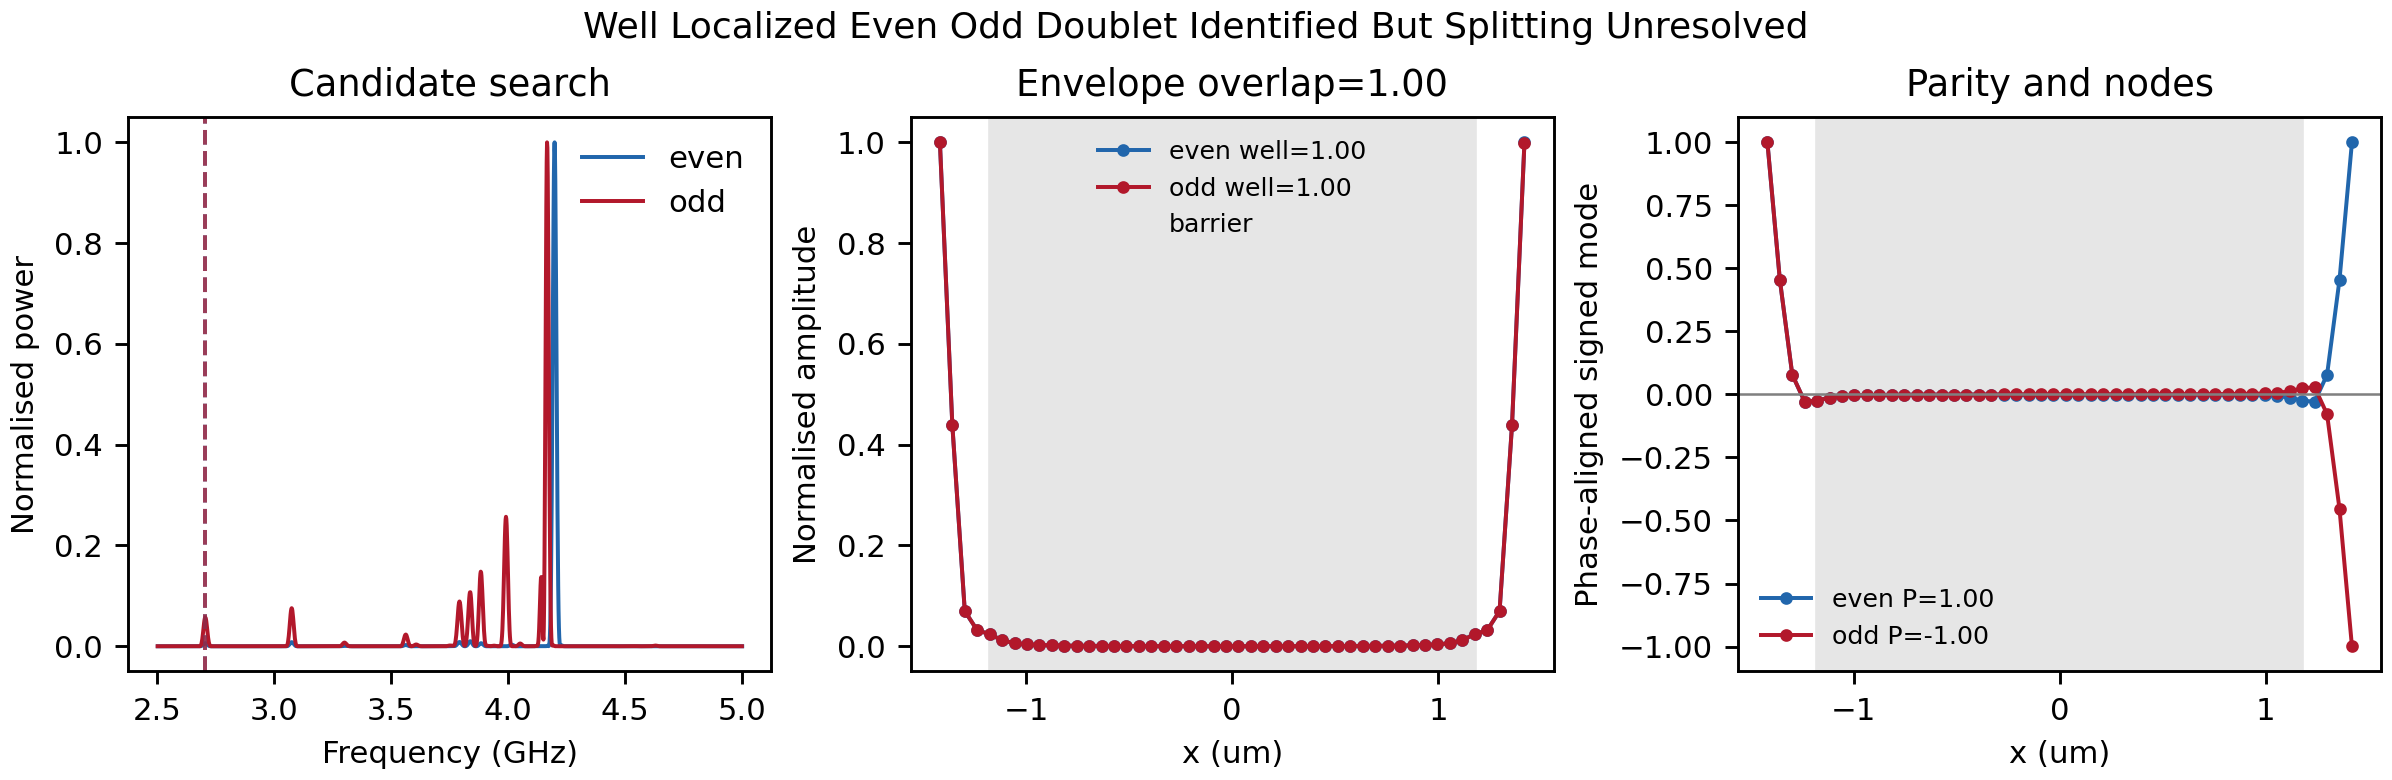

/kaggle/working/jphysd_explicit_double_well_k05b.zip

K05B identity audit complete. PASS means the analysis completed; only the outcome CONFIRMED_RESOLVED_WELL_LOCALIZED_EVEN_ODD_DOUBLET authorizes reporting K=Delta f/2 as the explicit-double-well LLG coupling.


In [22]:
"""Kaggle K05B: explicit-double-well mode identity audit (analysis only).

Reads the completed K05 even/odd raw tables. It searches multiple spectral
peaks, reconstructs complex stripe mode profiles, and pairs modes by spatial
envelope overlap and well localization rather than by peak strength alone.
K=Delta f/2 is accepted only for a resolved, parity-correct, well-localized,
window-stable common doublet. No MuMax process is launched.
"""
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, re, zipfile
import numpy as np
from scipy.signal import find_peaks

PIPELINE_VERSION="jphysd-k05b-mode-identity-v1"
ROOT=Path("/kaggle/working/jphysd_explicit_double_well"); CONFIG=ROOT/"explicit_double_well_config.json"; K05=ROOT/"k05_double_well_report.json"
TABLES={"even":ROOT/"runs"/"double_well_even.out"/"table.txt","odd":ROOT/"runs"/"double_well_odd.out"/"table.txt"}
STAGE=ROOT/"k05b_mode_identity"; REPORT=STAGE/"k05b_report.json"; ARCHIVE=Path("/kaggle/working/jphysd_explicit_double_well_k05b.zip")
SEARCH=(2.5e9,5.0e9); WINDOW_STARTS_NS=(2.0,10.0,20.0); PRIMARY_START_NS=2.0; OVERSAMPLE=8; MAX_PEAKS=12; MIN_RELATIVE_PEAK_POWER=0.005
PARITY_MIN=0.70; ENVELOPE_OVERLAP_MIN=0.95; WELL_POWER_FRACTION_MIN=0.50; LEFT_RIGHT_IMBALANCE_MAX=0.20; WINDOW_SHIFT_MAX_RAW_BINS=1.0

def banner(x): print("\n"+"="*78+"\n"+x+"\n"+"="*78)
def sha(p):
 h=hashlib.sha256()
 with Path(p).open("rb") as f:
  for b in iter(lambda:f.read(1048576),b""): h.update(b)
 return h.hexdigest()
def safe(x):
 if isinstance(x,Path): return str(x)
 if isinstance(x,np.generic): return x.item()
 if isinstance(x,np.ndarray): return x.tolist()
 if isinstance(x,dict): return {str(k):safe(v) for k,v in x.items()}
 if isinstance(x,(list,tuple)): return [safe(v) for v in x]
 return x
def write_json(p,x): p.parent.mkdir(parents=True,exist_ok=True); p.write_text(json.dumps(safe(x),indent=2,sort_keys=True,allow_nan=False)+"\n")
def stripe_meta(c):
 g=c["geometry"]; sx=g["target_semiaxes_m"][0]; n=g["x_stripes"]; w=2*sx/n; out=[]
 for i in range(n):
  left=-sx+i*w; right=left+w; center=(left+right)/2
  out.append({"region":g["first_region"]+i,"center":center,"barrier":abs(center)<c["field_double_well"]["barrier_width_m"]/2,"left_well":center<=-c["field_double_well"]["barrier_width_m"]/2,"right_well":center>=c["field_double_well"]["barrier_width_m"]/2})
 return out
def load(path):
 lines=Path(path).read_text(errors="replace").splitlines(); rows=[]
 for s in lines:
  if not s.strip() or s.lstrip().startswith("#"): continue
  try: rows.append([float(x) for x in s.split()])
  except ValueError: pass
 if not rows: raise RuntimeError(f"No numeric rows: {path}")
 width=max(map(len,rows)); a=np.asarray([r for r in rows if len(r)==width],float); heads=[]
 for s in lines:
  if s.lstrip().startswith("#"):
   q=[x.strip() for x in re.split(r"\t+",s.lstrip()[1:].strip()) if x.strip()]
   if len(q)==width: heads.append(q)
 if not heads: raise RuntimeError(f"No matching header: {path}")
 labels=max(heads,key=lambda q:sum("region" in x.lower() for x in q)); a=a[np.isfinite(a).all(axis=1)]; a=a[np.argsort(a[:,0],kind="stable")]; _,u=np.unique(a[:,0],return_index=True)
 return labels,a[u]
def columns(labels,r):
 out=[]
 for i,s in enumerate(labels):
  compact=re.sub(r"[^a-z0-9]","",s.lower().split("(",1)[0])
  if re.match(rf"^mregion{r}[xyz]$",compact): out.append(i)
 if len(out)!=3: raise RuntimeError(f"region {r}: expected 3 m columns, found {len(out)}")
 return out
def raw_trace(path,c):
 labels,a=load(path); meta=stripe_meta(c); idx=np.asarray([columns(labels,q["region"]) for q in meta]); return a[:,0],a[:,idx]
def resample(t,M,start_ns):
 keep=t>=start_ns*1e-9; t=t[keep]; M=M[keep]; dt=float(np.median(np.diff(t))); u=np.arange(t[0],t[-1]+dt/4,dt); U=np.empty((u.size,M.shape[1],3))
 for j in range(M.shape[1]):
  for k in range(3): U[:,j,k]=np.interp(u,t,M[:,j,k])
 return u,U,dt
def quadratic(f,p,i):
 if i<=0 or i>=p.size-1:return float(f[i])
 y=np.log(np.maximum(p[i-1:i+2],np.finfo(float).tiny)); d=y[0]-2*y[1]+y[2]
 return float(f[i]+np.clip(0.5*(y[0]-y[2])/d if abs(d)>1e-30 else 0,-0.5,0.5)*(f[1]-f[0]))
def complex_profile(u,U,freq):
 tau=u-u[0]; w=np.hanning(u.size); phase=np.exp(-2j*np.pi*freq*tau); Ay=phase@(w[:,None]*(U[:,:,1]-np.average(U[:,:,1],axis=0,weights=w))); Az=phase@(w[:,None]*(U[:,:,2]-np.average(U[:,:,2],axis=0,weights=w))); return Ay,Az
def profile_metrics(Ay,Az,meta,expected):
 rev_y=Ay[::-1]; rev_z=Az[::-1]; v=np.r_[Ay,Az]; r=np.r_[rev_y,rev_z]; parity=float(np.real(np.vdot(v,r))/max(np.linalg.norm(v)*np.linalg.norm(r),1e-300)); power=np.abs(Ay)**2+np.abs(Az)**2; barrier=np.asarray([q["barrier"] for q in meta]); left=np.asarray([q["left_well"] for q in meta]); right=np.asarray([q["right_well"] for q in meta]); total=max(np.sum(power),1e-300); well=float(np.sum(power[~barrier])/total); lp=float(np.sum(power[left])); rp=float(np.sum(power[right])); imbalance=float(abs(lp-rp)/max(lp+rp,1e-300)); component=Ay if np.linalg.norm(Ay)>=np.linalg.norm(Az) else Az; j=int(np.argmax(np.abs(component))); signed=np.real(component*np.exp(-1j*np.angle(component[j]))); signed/=max(np.max(np.abs(signed)),1e-300); active=np.abs(signed)>=0.10; vals=signed[active]; nodes=int(np.sum(vals[:-1]*vals[1:]<0)) if vals.size>1 else 0
 return {"parity":parity,"parity_error":abs(parity-expected),"well_power_fraction":well,"barrier_power_fraction":1-well,"left_right_well_imbalance":imbalance,"node_count_above_10pct":nodes,"envelope":np.sqrt(power),"signed_profile":signed}
def candidates(t,M,c,case,start_ns):
 meta=stripe_meta(c); u,U,dt=resample(t,M,start_ns); signs=np.asarray([1 if case=="even" or q["center"]<0 else -1 for q in meta]); y=np.mean(U[:,:,1]*signs[None,:],axis=1); z=np.mean(U[:,:,2]*signs[None,:],axis=1); w=np.hanning(u.size); n=1
 while n<OVERSAMPLE*u.size:n*=2
 f=np.fft.rfftfreq(n,dt); p=np.abs(np.fft.rfft(w*(y-y.mean()),n))**2+np.abs(np.fft.rfft(w*(z-z.mean()),n))**2; band=(f>=SEARCH[0])&(f<=SEARCH[1]); ids=np.flatnonzero(band); pb=p[ids]; distance=max(1,int(round((1/(u[-1]-u[0]))/(f[1]-f[0])))); peaks,prop=find_peaks(pb,height=MIN_RELATIVE_PEAK_POWER*np.max(pb),distance=distance)
 if peaks.size==0: peaks=np.asarray([int(np.argmax(pb))]); heights=pb[peaks]
 else: heights=prop["peak_heights"]
 order=np.argsort(heights)[::-1][:MAX_PEAKS]; out=[]; expected=1 if case=="even" else -1
 for rank,j in enumerate(order,1):
  local=int(peaks[j]); gi=int(ids[local]); freq=quadratic(f,p,gi); Ay,Az=complex_profile(u,U,freq); q=profile_metrics(Ay,Az,meta,expected); q.update({"case":case,"rank":rank,"frequency_Hz":freq,"relative_power":float(p[gi]/np.max(pb)),"SNR_proxy":float(p[gi]/max(np.median(pb),np.finfo(float).tiny)),"start_ns":start_ns,"raw_resolution_Hz":float(1/(u[-1]-u[0]))}); out.append(q)
 return out,{"frequency":f[ids],"power":pb,"raw_resolution_Hz":float(1/(u[-1]-u[0]))}
def overlap(a,b):
 x=a["envelope"]; y=b["envelope"]; return float(np.dot(x,y)/max(np.linalg.norm(x)*np.linalg.norm(y),1e-300))
def public(x): return {k:v for k,v in x.items() if k not in {"envelope","signed_profile"}}

banner("K05B — EXPLICIT DOUBLE-WELL MODE IDENTITY AUDIT")
STAGE.mkdir(parents=True,exist_ok=True); checks={}; report={"pipeline_version":PIPELINE_VERSION,"stage":"K05B_mode_identity_audit","status":"FAIL_K05B","checks":checks,"failed_checks":[],"started_utc":datetime.now(timezone.utc).isoformat(),"scientific_scope":"Analysis-only identification of a common even/odd well-localized doublet. A spectral separation is not promoted to K unless spatial identity, parity, localization, resolution, and window stability pass."}
try:
 c=json.loads(CONFIG.read_text()); k05=json.loads(K05.read_text()); checks["K05_PASS"]=k05.get("status")=="PASS_K05_EXPLICIT_DOUBLE_WELL_MODES" and not k05.get("failed_checks"); checks["raw_tables_exist"]=all(p.is_file() and p.stat().st_size>100 for p in TABLES.values())
 if not all(checks.values()): raise RuntimeError("K05 chain or raw tables missing")
 raw={case:raw_trace(path,c) for case,path in TABLES.items()}; all_windows={}; spectra={}
 for case,(t,M) in raw.items():
  all_windows[case]={}; spectra[case]={}
  for start in WINDOW_STARTS_NS: all_windows[case][str(start)],spectra[case][str(start)]=candidates(t,M,c,case,start)
  print(case,"primary peaks GHz:",[round(x["frequency_Hz"]*1e-9,6) for x in all_windows[case][str(PRIMARY_START_NS)]])
 even=all_windows["even"][str(PRIMARY_START_NS)]; odd=all_windows["odd"][str(PRIMARY_START_NS)]; pairs=[]
 for e in even:
  for o in odd:
   ov=overlap(e,o); split=abs(e["frequency_Hz"]-o["frequency_Hz"]); rawres=max(e["raw_resolution_Hz"],o["raw_resolution_Hz"]); parity_ok=e["parity"]>=PARITY_MIN and o["parity"]<=-PARITY_MIN; loc_ok=e["well_power_fraction"]>=WELL_POWER_FRACTION_MIN and o["well_power_fraction"]>=WELL_POWER_FRACTION_MIN; balance_ok=e["left_right_well_imbalance"]<=LEFT_RIGHT_IMBALANCE_MAX and o["left_right_well_imbalance"]<=LEFT_RIGHT_IMBALANCE_MAX; resolved=split>rawres; identity=parity_ok and loc_ok and balance_ok and ov>=ENVELOPE_OVERLAP_MIN; score=ov*np.sqrt(e["well_power_fraction"]*o["well_power_fraction"])/(1+split/5e8)
   pairs.append({"even_rank":e["rank"],"odd_rank":o["rank"],"even_frequency_Hz":e["frequency_Hz"],"odd_frequency_Hz":o["frequency_Hz"],"splitting_Hz":split,"K_over_2pi_Hz":split/2,"raw_resolution_Hz":rawres,"envelope_overlap":ov,"even_well_fraction":e["well_power_fraction"],"odd_well_fraction":o["well_power_fraction"],"even_parity":e["parity"],"odd_parity":o["parity"],"parity_ok":parity_ok,"localization_ok":loc_ok,"well_balance_ok":balance_ok,"resolved":resolved,"identity_matched":identity,"resolved_identity_pair":identity and resolved,"pair_score":score})
 identity_pairs=[x for x in pairs if x["identity_matched"]]; selected=max(identity_pairs,key=lambda x:x["pair_score"]) if identity_pairs else max(pairs,key=lambda x:x["pair_score"])
 def get(case,rank,start): return next(x for x in all_windows[case][str(start)] if x["rank"]==rank)
 # Window stability tracks the nearest peak to the selected primary frequency,
 # because spectral ranks can exchange when the fit window changes.
 stability={}
 for case,key,rank_key in (("even","even_frequency_Hz","even_rank"),("odd","odd_frequency_Hz","odd_rank")):
  base=selected[key]; vals=[]
  for start in WINDOW_STARTS_NS:
   cand=min(all_windows[case][str(start)],key=lambda x:abs(x["frequency_Hz"]-base)); vals.append({"start_ns":start,"frequency_Hz":cand["frequency_Hz"],"parity":cand["parity"],"well_power_fraction":cand["well_power_fraction"],"nearest_rank":cand["rank"]})
  stability[case]=vals
 spans={case:float(np.ptp([x["frequency_Hz"] for x in vals])) for case,vals in stability.items()}; raw_primary=selected["raw_resolution_Hz"]; window_ok=all(x<=WINDOW_SHIFT_MAX_RAW_BINS*raw_primary for x in spans.values())
 doublet_confirmed=bool(identity_pairs and selected["resolved"] and window_ok); selected["window_frequency_spans_Hz"]=spans; selected["window_stability_ok"]=window_ok; selected["doublet_confirmed"]=doublet_confirmed
 if not identity_pairs: outcome="NO_PRIMARY_PAIR_PASSES_SPATIAL_DOUBLET_IDENTITY"
 elif not window_ok: outcome="IDENTITY_MATCHED_DOUBLET_NOT_STABLE_TO_ANALYSIS_WINDOW"
 elif not selected["resolved"]: outcome="WELL_LOCALIZED_EVEN_ODD_DOUBLET_IDENTIFIED_BUT_SPLITTING_UNRESOLVED"
 else: outcome="CONFIRMED_RESOLVED_WELL_LOCALIZED_EVEN_ODD_DOUBLET"
 checks["candidate_sets_nonempty"]=bool(even and odd); checks["pair_matrix_complete"]=len(pairs)==len(even)*len(odd)
 report["thresholds"]={"parity_minimum_absolute":PARITY_MIN,"envelope_overlap_minimum":ENVELOPE_OVERLAP_MIN,"well_power_fraction_minimum":WELL_POWER_FRACTION_MIN,"left_right_imbalance_maximum":LEFT_RIGHT_IMBALANCE_MAX,"window_shift_maximum_raw_bins":WINDOW_SHIFT_MAX_RAW_BINS}; report["primary_candidates"]={"even":[public(x) for x in even],"odd":[public(x) for x in odd]}; report["identity_matched_pairs_by_score"]=sorted(identity_pairs,key=lambda x:x["pair_score"],reverse=True); report["top_pairs_by_score"]=sorted(pairs,key=lambda x:x["pair_score"],reverse=True)[:20]; report["selected_pair"]=selected; report["window_stability"]=stability; report["outcome"]=outcome; report["manuscript_decision"]="K=Delta f/2 may be reported as an LLG-extracted explicit-double-well coupling only if outcome is CONFIRMED_RESOLVED_WELL_LOCALIZED_EVEN_ODD_DOUBLET. If the identity-matched doublet is unresolved, report only K/(2pi) < raw_resolution/2."
 import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
 se=next(x for x in even if x["rank"]==selected["even_rank"]); so=next(x for x in odd if x["rank"]==selected["odd_rank"]); meta=stripe_meta(c); x=np.asarray([q["center"] for q in meta])*1e6; barrier=np.asarray([q["barrier"] for q in meta]); fig,ax=plt.subplots(1,3,figsize=(9.2,3.0),constrained_layout=True)
 for case,color in (("even","#2166ac"),("odd","#b2182b")): sp=spectra[case][str(PRIMARY_START_NS)]; ax[0].plot(sp["frequency"]*1e-9,sp["power"]/np.max(sp["power"]),color=color,label=case)
 ax[0].axvline(se["frequency_Hz"]*1e-9,color="#2166ac",ls="--",alpha=.7); ax[0].axvline(so["frequency_Hz"]*1e-9,color="#b2182b",ls="--",alpha=.7); ax[0].set(xlabel="Frequency (GHz)",ylabel="Normalised power",title="Candidate search"); ax[0].legend(frameon=False)
 for q,color in ((se,"#2166ac"),(so,"#b2182b")): ax[1].plot(x,q["envelope"]/max(np.max(q["envelope"]),1e-300),"o-",ms=2.5,color=color,label=f"{q['case']} well={q['well_power_fraction']:.2f}"); ax[2].plot(x,q["signed_profile"],"o-",ms=2.5,color=color,label=f"{q['case']} P={q['parity']:.2f}")
 for a in (ax[1],ax[2]): a.axvspan(x[barrier][0],x[barrier][-1],color="0.9",zorder=-5,label="barrier" if a is ax[1] else None)
 ax[1].set(xlabel="x (um)",ylabel="Normalised amplitude",title=f"Envelope overlap={selected['envelope_overlap']:.2f}"); ax[2].axhline(0,color="0.5",lw=.7); ax[2].set(xlabel="x (um)",ylabel="Phase-aligned signed mode",title="Parity and nodes"); ax[1].legend(frameon=False,fontsize=7); ax[2].legend(frameon=False,fontsize=7); fig.suptitle(outcome.replace("_"," ").title(),fontsize=10); fig.savefig(STAGE/"k05b_mode_identity.png",dpi=260); fig.savefig(STAGE/"k05b_mode_identity.pdf"); plt.close(fig)
 required=["K05_PASS","raw_tables_exist","candidate_sets_nonempty","pair_matrix_complete"]; report["required_checks"]=required; report["failed_checks"]=[x for x in required if not checks.get(x,False)]; report["status"]="PASS_K05B_IDENTITY_AUDIT" if not report["failed_checks"] else "FAIL_K05B"
except Exception as e:
 report["exception"]={"type":type(e).__name__,"message":str(e)}; report["failed_checks"]=[k for k,v in checks.items() if not v] or ["K05B_exception"]
report["finished_utc"]=datetime.now(timezone.utc).isoformat(); write_json(REPORT,report)
if ARCHIVE.exists(): ARCHIVE.unlink()
with zipfile.ZipFile(ARCHIVE,"w",zipfile.ZIP_DEFLATED) as z:
 for p in sorted(x for x in STAGE.rglob("*") if x.is_file()): z.write(p,arcname=p.relative_to(STAGE).as_posix())
banner(f"K05B COMPLETE | {report['status']}"); print(json.dumps(safe({"status":report["status"],"failed_checks":report["failed_checks"],"outcome":report.get("outcome"),"selected_pair":report.get("selected_pair"),"top_pairs":report.get("top_pairs_by_score",[])[:5],"exception":report.get("exception"),"report":REPORT,"archive":ARCHIVE}),indent=2,allow_nan=False))
try:
 from IPython.display import FileLink,Image,display
 if (STAGE/"k05b_mode_identity.png").is_file(): display(Image(filename=str(STAGE/"k05b_mode_identity.png")))
 display(FileLink(str(ARCHIVE)))
except Exception: pass
if report["status"]!="PASS_K05B_IDENTITY_AUDIT": raise RuntimeError(f"K05B failed: {report['failed_checks']} | {report.get('exception')}")
print("K05B identity audit complete. PASS means the analysis completed; only the outcome CONFIRMED_RESOLVED_WELL_LOCALIZED_EVEN_ODD_DOUBLET authorizes reporting K=Delta f/2 as the explicit-double-well LLG coupling.")



K05C — 800-NS TARGETED EXPLICIT-DOUBLE-WELL DOUBLET
PHASE 1/4 — generate and vet targeted long-window scripts
vet double_well_even_targeted_800ns.mx3: return=0
vet double_well_odd_targeted_800ns.mx3: return=0
PHASE 2/4 — concurrent 800-ns even/odd runs
$ /kaggle/working/jphysd_full_llg_fresh/bin/mumax3 -gpu=0 -failfast -http= -cache /kaggle/working/jphysd_explicit_double_well/demag_cache -o /kaggle/working/jphysd_explicit_double_well/k05c_long_window/runs/even.out /kaggle/working/jphysd_explicit_double_well/k05c_long_window/scripts/double_well_even_targeted_800ns.mx3
$ /kaggle/working/jphysd_full_llg_fresh/bin/mumax3 -gpu=1 -failfast -http= -cache /kaggle/working/jphysd_explicit_double_well/demag_cache -o /kaggle/working/jphysd_explicit_double_well/k05c_long_window/runs/odd.out /kaggle/working/jphysd_explicit_double_well/k05c_long_window/scripts/double_well_odd_targeted_800ns.mx3
[odd] running 60 s[even] running 60 s

[odd] running 120 s[even] running 120 s

[odd] running 180 s[even] 

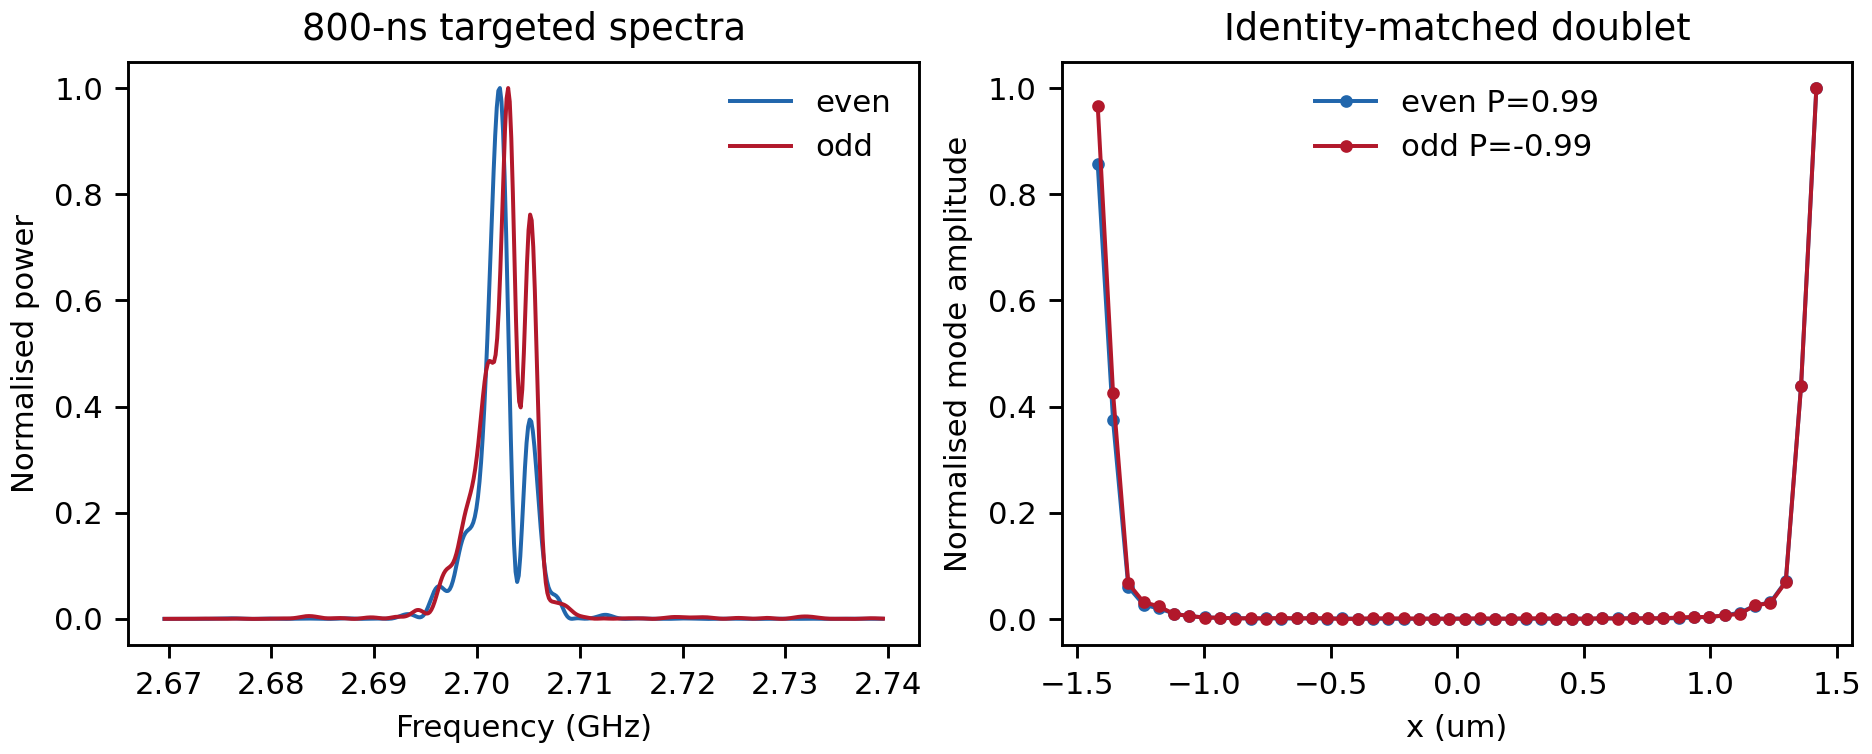

/kaggle/working/jphysd_explicit_double_well_k05c.zip

K05C complete. Report K=Delta f/2 only for RESOLVED_LONG_WINDOW_EXPLICIT_DOUBLE_WELL_SPLITTING; otherwise retain the resolution-limited upper bound and do not quote the sub-bin separation.


In [23]:
"""Kaggle K05C: 800-ns targeted long-window explicit-double-well doublet.

Run after corrected K05B in the same session. The common K05 equilibrium is
reused. Weak even/odd harmonic bursts are centred on the identity-matched
lowest doublet, then both sectors ring down to 800 ns. The expected raw
resolution is about 1.27 MHz, sufficient to test the reduced-model prediction
Delta f = 2 K/(2pi) ~= 2.10--2.61 MHz. No conditional control is included.
"""
from pathlib import Path
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor
import hashlib, json, os, re, shutil, subprocess, time, zipfile
import numpy as np

PIPELINE_VERSION="jphysd-k05c-long-window-doublet-v1"
BASE=Path("/kaggle/working/jphysd_full_llg_fresh"); K00=BASE/"locks"/"k00_manifest.json"; MUMAX=BASE/"bin"/"mumax3"
ROOT=Path("/kaggle/working/jphysd_explicit_double_well"); CONFIG=ROOT/"explicit_double_well_config.json"; K05=ROOT/"k05_double_well_report.json"; K05B=ROOT/"k05b_mode_identity"/"k05b_report.json"; EQ=ROOT/"runs"/"double_well_equilibrium.out"/"m_equilibrium.ovf"
STAGE=ROOT/"k05c_long_window"; SCRIPTS=STAGE/"scripts"; RUNS=STAGE/"runs"; LOGS=STAGE/"logs"; CACHE=ROOT/"demag_cache"; REPORT=STAGE/"k05c_report.json"; ARCHIVE=Path("/kaggle/working/jphysd_explicit_double_well_k05c.zip")
DURATION=800e-9; DRIVE_DURATION=10e-9; TABLE_PERIOD=50e-12; AUTOSAVE_PERIOD=100e-9; AMPLITUDE=20e-6; SEARCH_HALF_WIDTH=35e6; WINDOW_STARTS_NS=(12.0,100.0,200.0); OVERSAMPLE=8; MAX_RUNTIME=3.25*3600

def banner(x): print("\n"+"="*78+"\n"+x+"\n"+"="*78)
def fmt(x): return f"{float(x):.12e}"
def sha(p):
 h=hashlib.sha256()
 with Path(p).open("rb") as f:
  for b in iter(lambda:f.read(1048576),b""): h.update(b)
 return h.hexdigest()
def safe(x):
 if isinstance(x,Path): return str(x)
 if isinstance(x,np.generic): return x.item()
 if isinstance(x,np.ndarray): return x.tolist()
 if isinstance(x,dict): return {str(k):safe(v) for k,v in x.items()}
 if isinstance(x,(list,tuple)): return [safe(v) for v in x]
 return x
def write_json(p,x): p.parent.mkdir(parents=True,exist_ok=True); p.write_text(json.dumps(safe(x),indent=2,sort_keys=True,allow_nan=False)+"\n")
def locked(p,text):
 b=(text.rstrip()+"\n").encode(); p.parent.mkdir(parents=True,exist_ok=True)
 if p.exists() and p.read_bytes()!=b: raise RuntimeError(f"Immutable script conflict: {p}")
 if not p.exists(): p.write_bytes(b)
 return sha(p)
def meta(c):
 g=c["geometry"]; sx=g["target_semiaxes_m"][0]; n=g["x_stripes"]; w=2*sx/n; out=[]
 for i in range(n):
  left=-sx+i*w; right=left+w; center=(left+right)/2; out.append({"region":g["first_region"]+i,"left":left,"right":right,"center":center,"barrier":abs(center)<c["field_double_well"]["barrier_width_m"]/2})
 return out
def geometry(c):
 g=c["geometry"]; sx,sy=g["target_semiaxes_m"]; nx,ny,nz=g["mesh"]; dx,dy,dz=g["cell_m"]; L=[f"SetGridSize({nx},{ny},{nz})",f"SetCellSize({fmt(dx)},{fmt(dy)},{fmt(dz)})","SetPBC(0,0,0)","OutputFormat=OVF2_BINARY",f"EdgeSmooth={c['solver']['edge_smooth']}",f"DemagAccuracy={fmt(c['solver']['demag_accuracy'])}",f"targetXY:=Ellipse({fmt(2*sx)},{fmt(2*sy)})",f"targetZ:=ZRange({fmt(-g['thickness_m']/2)},{fmt(g['thickness_m']/2)})","target:=targetXY.Intersect(targetZ)","SetGeom(target)"]
 for q in meta(c): L.append(f"DefRegion({q['region']},target.Intersect(XRange({fmt(q['left'])},{fmt(q['right'])})))")
 return L
def material(c):
 m=c["material"]; return [f"Msat={fmt(m['Msat_A_per_m'])}",f"Aex={fmt(m['Aex_J_per_m'])}",f"alpha={fmt(m['alpha'])}",f"Kc1={fmt(m['Kc1_J_per_m3'])}","Dind=0","Dbulk=0","Temp=0"]
def static(c,declare=True):
 b=c["field_double_well"]; L=([f"B0:={fmt(b['bias_T'])}",f"Bbar:={fmt(b['barrier_increment_T'])}"] if declare else [])+["B_ext=vector(B0,0,0)"]
 for q in meta(c):
  if q["barrier"]: L.append(f"B_ext.SetRegion({q['region']},vector(B0+Bbar,0,0))")
 return L
def script(c,case,drive):
 s=c["solver"]; L=[f"// K05C {case} 800-ns targeted doublet ringdown"]+geometry(c)+material(c)+static(c)+[f'm.LoadFile("{EQ}")']
 for q in meta(c): L.append(f"TableAdd(m.Region({q['region']}))")
 L += ["TableAdd(E_total)","TableAdd(maxTorque)",f"TableAutoSave({fmt(TABLE_PERIOD)})",f"AutoSave(m,{fmt(AUTOSAVE_PERIOD)})","TableSave()",f"SetSolver({s['solver_id']})",f"MaxErr={fmt(s['MaxErr'])}",f"MaxDt={fmt(s['MaxDt_s'])}",f"MinDt={fmt(s['MinDt_s'])}",f"Ap:={fmt(AMPLITUDE)}",f"fd:={fmt(drive)}"]
 for q in meta(c):
  sign=1 if case=="even" or q["center"]<0 else -1; bx="B0+Bbar" if q["barrier"] else "B0"; L.append(f"B_ext.SetRegion({q['region']},vector({bx},{sign}*Ap*sin(2*pi*fd*t),0))")
 L += [f"Run({fmt(DRIVE_DURATION)})"]+static(c,False)+[f"Run({fmt(DURATION-DRIVE_DURATION)})","TableSave()",f'SaveAs(m,"m_final_{case}_800ns")',"Flush()"]
 return "\n".join(L)
def run(cmd,env,log,label):
 cmd=[str(x) for x in cmd]; print("$"," ".join(cmd),flush=True); t0=time.time(); log.parent.mkdir(parents=True,exist_ok=True)
 with log.open("w") as f:
  p=subprocess.Popen(cmd,env=env,text=True,stdout=f,stderr=subprocess.STDOUT); beat=t0+60; timed=False
  while p.poll() is None:
   time.sleep(2)
   if time.time()>=beat: print(f"[{label}] running {time.time()-t0:.0f} s",flush=True); beat+=60
   if time.time()-t0>MAX_RUNTIME: p.kill(); timed=True; break
  rc=p.wait()
 text=log.read_text(errors="replace"); print(text[-3000:]); print(f"[{label}] return={rc} timeout={timed} runtime={time.time()-t0:.1f} s"); return {"returncode":rc,"timed_out":timed,"runtime_s":time.time()-t0,"log":str(log),"text":text}
def load(path):
 lines=Path(path).read_text(errors="replace").splitlines(); rows=[]
 for s in lines:
  if not s.strip() or s.lstrip().startswith("#"): continue
  try: rows.append([float(x) for x in s.split()])
  except ValueError: pass
 width=max(map(len,rows)); a=np.asarray([r for r in rows if len(r)==width],float); heads=[]
 for s in lines:
  if s.lstrip().startswith("#"):
   q=[x.strip() for x in re.split(r"\t+",s.lstrip()[1:].strip()) if x.strip()]
   if len(q)==width: heads.append(q)
 labels=max(heads,key=lambda q:sum("region" in x.lower() for x in q)); a=a[np.isfinite(a).all(axis=1)]; a=a[np.argsort(a[:,0])]; _,u=np.unique(a[:,0],return_index=True); return labels,a[u]
def cols(labels,r):
 out=[]
 for i,s in enumerate(labels):
  if re.match(rf"^mregion{r}[xyz]$",re.sub(r"[^a-z0-9]","",s.lower().split("(",1)[0])): out.append(i)
 if len(out)!=3: raise RuntimeError(f"region {r}: found {len(out)} m columns")
 return out
def traces(path,c):
 labels,a=load(path); idx=np.asarray([cols(labels,q["region"]) for q in meta(c)]); return a[:,0],a[:,idx]
def peak(t,M,c,case,start_ns,drive):
 keep=t>=start_ns*1e-9; t=t[keep]; M=M[keep]; dt=float(np.median(np.diff(t))); u=np.arange(t[0],t[-1]+dt/4,dt); U=np.empty((u.size,M.shape[1],3))
 for j in range(M.shape[1]):
  for k in range(3): U[:,j,k]=np.interp(u,t,M[:,j,k])
 signs=np.asarray([1 if case=="even" or q["center"]<0 else -1 for q in meta(c)]); y=np.mean(U[:,:,1]*signs[None,:],axis=1); z=np.mean(U[:,:,2]*signs[None,:],axis=1); w=np.hanning(u.size); n=1
 while n<OVERSAMPLE*u.size:n*=2
 f=np.fft.rfftfreq(n,dt); Y=np.fft.rfft(w*(y-y.mean()),n); Z=np.fft.rfft(w*(z-z.mean()),n); p=np.abs(Y)**2+np.abs(Z)**2; band=(f>=drive-SEARCH_HALF_WIDTH)&(f<=drive+SEARCH_HALF_WIDTH); ids=np.flatnonzero(band); i=ids[np.argmax(p[band])]; raw=float(1/(u[-1]-u[0])); noise=p[band & (np.abs(f-f[i])>3*raw)]; phase=np.exp(-2j*np.pi*f[i]*(u-u[0])); Ay=phase@(w[:,None]*(U[:,:,1]-np.average(U[:,:,1],axis=0,weights=w))); Az=phase@(w[:,None]*(U[:,:,2]-np.average(U[:,:,2],axis=0,weights=w))); v=np.r_[Ay,Az]; r=np.r_[Ay[::-1],Az[::-1]]; parity=float(np.real(np.vdot(v,r))/max(np.linalg.norm(v)*np.linalg.norm(r),1e-300)); envelope=np.sqrt(np.abs(Ay)**2+np.abs(Az)**2)
 return {"case":case,"start_ns":start_ns,"frequency_Hz":float(f[i]),"raw_resolution_Hz":raw,"SNR":float(p[i]/max(np.median(noise),np.finfo(float).tiny)),"parity":parity,"frequency":f[band],"power":p[band],"envelope":envelope}

banner("K05C — 800-NS TARGETED EXPLICIT-DOUBLE-WELL DOUBLET")
t0=time.time(); checks={}; report={"pipeline_version":PIPELINE_VERSION,"stage":"K05C_800ns_targeted_doublet","status":"FAIL_K05C","checks":checks,"failed_checks":[],"started_utc":datetime.now(timezone.utc).isoformat(),"scientific_scope":"Long-window target-only LLG resolution test of the K05B identity-matched lowest even/odd doublet; prescribed barrier, no conditional control or CNOT claim."}
try:
 c=json.loads(CONFIG.read_text()); k00=json.loads(K00.read_text()); k05=json.loads(K05.read_text()); b=json.loads(K05B.read_text()); checks["K05_PASS"]=k05.get("status")=="PASS_K05_EXPLICIT_DOUBLE_WELL_MODES"; checks["K05B_identity_unresolved"]=b.get("outcome")=="WELL_LOCALIZED_EVEN_ODD_DOUBLET_IDENTIFIED_BUT_SPLITTING_UNRESOLVED"; checks["equilibrium_exists"]=EQ.is_file()
 if not all(checks.values()): raise RuntimeError("K05/K05B chain unavailable")
 selected=b["selected_pair"]; drive=0.5*(selected["even_frequency_Hz"]+selected["odd_frequency_Hz"]); report["drive_frequency_Hz"]=drive
 for d in (STAGE,SCRIPTS,RUNS,LOGS): d.mkdir(parents=True,exist_ok=True)
 env=os.environ.copy(); env["LD_LIBRARY_PATH"]=k00["dynamic_linking"]["LD_LIBRARY_PATH"]; cases=[]
 print("PHASE 1/4 — generate and vet targeted long-window scripts")
 for case in ("even","odd"):
  p=SCRIPTS/f"double_well_{case}_targeted_800ns.mx3"; h=locked(p,script(c,case,drive)); v=subprocess.run([MUMAX,"-vet","-f","-http=",p],env=env,text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,timeout=300); print(f"vet {p.name}: return={v.returncode}"); cases.append({"case":case,"script":p,"hash":h,"vet":v.returncode,"output":RUNS/f"{case}.out"})
 checks["both_scripts_vet"]=all(x["vet"]==0 for x in cases)
 if not checks["both_scripts_vet"]: raise RuntimeError("script vet failed")
 print("PHASE 2/4 — concurrent 800-ns even/odd runs")
 def execute(x,gpu):
  tab=x["output"]/"table.txt"
  if tab.is_file():
   try:
    _,a=load(tab)
    if a.shape[0]>=15000 and a[-1,0]>=DURATION-0.1e-9:return {"returncode":0,"timed_out":False,"runtime_s":0.0,"log":"checkpoint","reused":True,"gpu":gpu}
   except Exception:pass
  if x["output"].exists():shutil.move(str(x["output"]),str(STAGE/f"incomplete_{x['case']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.out"))
  q=run([MUMAX,f"-gpu={gpu}","-failfast","-http=","-cache",CACHE,"-o",x["output"],x["script"]],env,LOGS/f"{x['case']}.log",x["case"]); q.update({"reused":False,"gpu":gpu}); return q
 with ThreadPoolExecutor(max_workers=2) as pool: execution=[f.result() for f in (pool.submit(execute,cases[0],0),pool.submit(execute,cases[1],1))]
 checks["both_runs_complete"]=all(x["returncode"]==0 and not x["timed_out"] for x in execution)
 if not checks["both_runs_complete"]: raise RuntimeError("long-window run failed or timed out")
 print("PHASE 3/4 — resolution, parity and window audit")
 raw={x["case"]:traces(x["output"]/"table.txt",c) for x in cases}; windows={case:[peak(*raw[case],c,case,s,drive) for s in WINDOW_STARTS_NS] for case in ("even","odd")}; primary={case:windows[case][0] for case in windows}; delta=abs(primary["even"]["frequency_Hz"]-primary["odd"]["frequency_Hz"]); rawres=max(x["raw_resolution_Hz"] for x in primary.values()); spans={case:float(np.ptp([x["frequency_Hz"] for x in vals])) for case,vals in windows.items()}; parity_ok=primary["even"]["parity"]>=0.70 and primary["odd"]["parity"]<=-0.70; stable=all(x<=rawres for x in spans.values()); resolved=delta>rawres; checks["both_SNR_at_least_10"]=all(x["SNR"]>=10 for x in primary.values()); checks["parity_correct"]=parity_ok; checks["window_stable_within_raw_bin"]=stable
 if resolved and parity_ok and stable: outcome="RESOLVED_LONG_WINDOW_EXPLICIT_DOUBLE_WELL_SPLITTING"
 else: outcome="LONG_WINDOW_DOUBLET_SPLITTING_UNRESOLVED"
 report["primary"]={k:{q:v for q,v in x.items() if q not in {"frequency","power","envelope"}} for k,x in primary.items()}; report["window_frequencies"]={k:[{"start_ns":x["start_ns"],"frequency_Hz":x["frequency_Hz"],"raw_resolution_Hz":x["raw_resolution_Hz"],"parity":x["parity"],"SNR":x["SNR"]} for x in v] for k,v in windows.items()}; report["decision"]={"frequency_splitting_Hz":delta,"K_over_2pi_Hz":delta/2 if resolved else None,"raw_resolution_Hz":rawres,"resolution_limited_K_upper_bound_Hz":rawres/2 if not resolved else None,"window_spans_Hz":spans,"resolved":resolved,"outcome":outcome}
 print(f"even={primary['even']['frequency_Hz']*1e-9:.9f} GHz | odd={primary['odd']['frequency_Hz']*1e-9:.9f} GHz | delta={delta*1e-6:.3f} MHz | raw={rawres*1e-6:.3f} MHz")
 print("PHASE 4/4 — diagnostics and archive")
 import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
 fig,ax=plt.subplots(1,2,figsize=(7.2,2.9),constrained_layout=True)
 for case,color in (("even","#2166ac"),("odd","#b2182b")): x=primary[case]; ax[0].plot(x["frequency"]*1e-9,x["power"]/np.max(x["power"]),color=color,label=case); ax[1].plot(np.asarray([q["center"] for q in meta(c)])*1e6,x["envelope"]/np.max(x["envelope"]),"o-",ms=2.5,color=color,label=f"{case} P={x['parity']:.2f}")
 ax[0].set(xlabel="Frequency (GHz)",ylabel="Normalised power",title="800-ns targeted spectra"); ax[1].set(xlabel="x (um)",ylabel="Normalised mode amplitude",title="Identity-matched doublet"); ax[0].legend(frameon=False); ax[1].legend(frameon=False); fig.savefig(STAGE/"k05c_long_window.png",dpi=260); fig.savefig(STAGE/"k05c_long_window.pdf"); plt.close(fig)
 required=["K05_PASS","K05B_identity_unresolved","equilibrium_exists","both_scripts_vet","both_runs_complete","both_SNR_at_least_10","parity_correct","window_stable_within_raw_bin"]; report["execution"]=execution; report["required_checks"]=required; report["failed_checks"]=[x for x in required if not checks.get(x,False)]; report["status"]="PASS_K05C_LONG_WINDOW_AUDIT" if not report["failed_checks"] else "FAIL_K05C"
except Exception as e:
 report["exception"]={"type":type(e).__name__,"message":str(e)}; report["failed_checks"]=[k for k,v in checks.items() if not v] or ["K05C_exception"]
report["runtime_s"]=time.time()-t0; report["finished_utc"]=datetime.now(timezone.utc).isoformat(); write_json(REPORT,report)
if ARCHIVE.exists():ARCHIVE.unlink()
with zipfile.ZipFile(ARCHIVE,"w",zipfile.ZIP_DEFLATED,allowZip64=True) as z:
 for p in sorted(x for x in STAGE.rglob("*") if x.is_file()):z.write(p,arcname=p.relative_to(STAGE).as_posix())
banner(f"K05C COMPLETE | {report['status']}"); print(json.dumps(safe({"status":report["status"],"failed_checks":report["failed_checks"],"drive_frequency_Hz":report.get("drive_frequency_Hz"),"decision":report.get("decision"),"primary":report.get("primary"),"exception":report.get("exception"),"runtime_s":report["runtime_s"],"report":REPORT,"archive":ARCHIVE}),indent=2,allow_nan=False))
try:
 from IPython.display import FileLink,Image,display
 if (STAGE/"k05c_long_window.png").is_file():display(Image(filename=str(STAGE/"k05c_long_window.png")))
 display(FileLink(str(ARCHIVE)))
except Exception:pass
if report["status"]!="PASS_K05C_LONG_WINDOW_AUDIT":raise RuntimeError(f"K05C failed: {report['failed_checks']} | {report.get('exception')}")
print("K05C complete. Report K=Delta f/2 only for RESOLVED_LONG_WINDOW_EXPLICIT_DOUBLE_WELL_SPLITTING; otherwise retain the resolution-limited upper bound and do not quote the sub-bin separation.")



K05D — SUB-BIN SENSITIVITY AND IDENTITY AUDIT
   12-  800 ns | delta= 0.8435 MHz | raw= 1.2690 MHz | overlap=0.99808 | Pe=+0.986 Po=-0.991
   50-  800 ns | delta= 0.9231 MHz | raw= 1.3334 MHz | overlap=0.99860 | Pe=+0.979 Po=-0.979
  100-  800 ns | delta= 1.0029 MHz | raw= 1.4286 MHz | overlap=0.99950 | Pe=+0.965 Po=-0.952
  150-  800 ns | delta= 0.9557 MHz | raw= 1.5385 MHz | overlap=0.99984 | Pe=+0.948 Po=-0.942
  200-  800 ns | delta= 0.7709 MHz | raw= 1.6667 MHz | overlap=0.99707 | Pe=+0.975 Po=-0.919
   12-  600 ns | delta= 1.0691 MHz | raw= 1.7008 MHz | overlap=0.99851 | Pe=+0.993 Po=-0.982
   50-  650 ns | delta= 0.6396 MHz | raw= 1.6669 MHz | overlap=0.99166 | Pe=+0.994 Po=-0.959
  100-  700 ns | delta= 0.6318 MHz | raw= 1.6669 MHz | overlap=0.99040 | Pe=+0.994 Po=-0.912
  150-  750 ns | delta= 0.9093 MHz | raw= 1.6669 MHz | overlap=0.99625 | Pe=+0.985 Po=-0.887
  200-  800 ns | delta= 0.7709 MHz | raw= 1.6667 MHz | overlap=0.99707 | Pe=+0.975 Po=-0.919

K05D COMPLETE | PASS_K

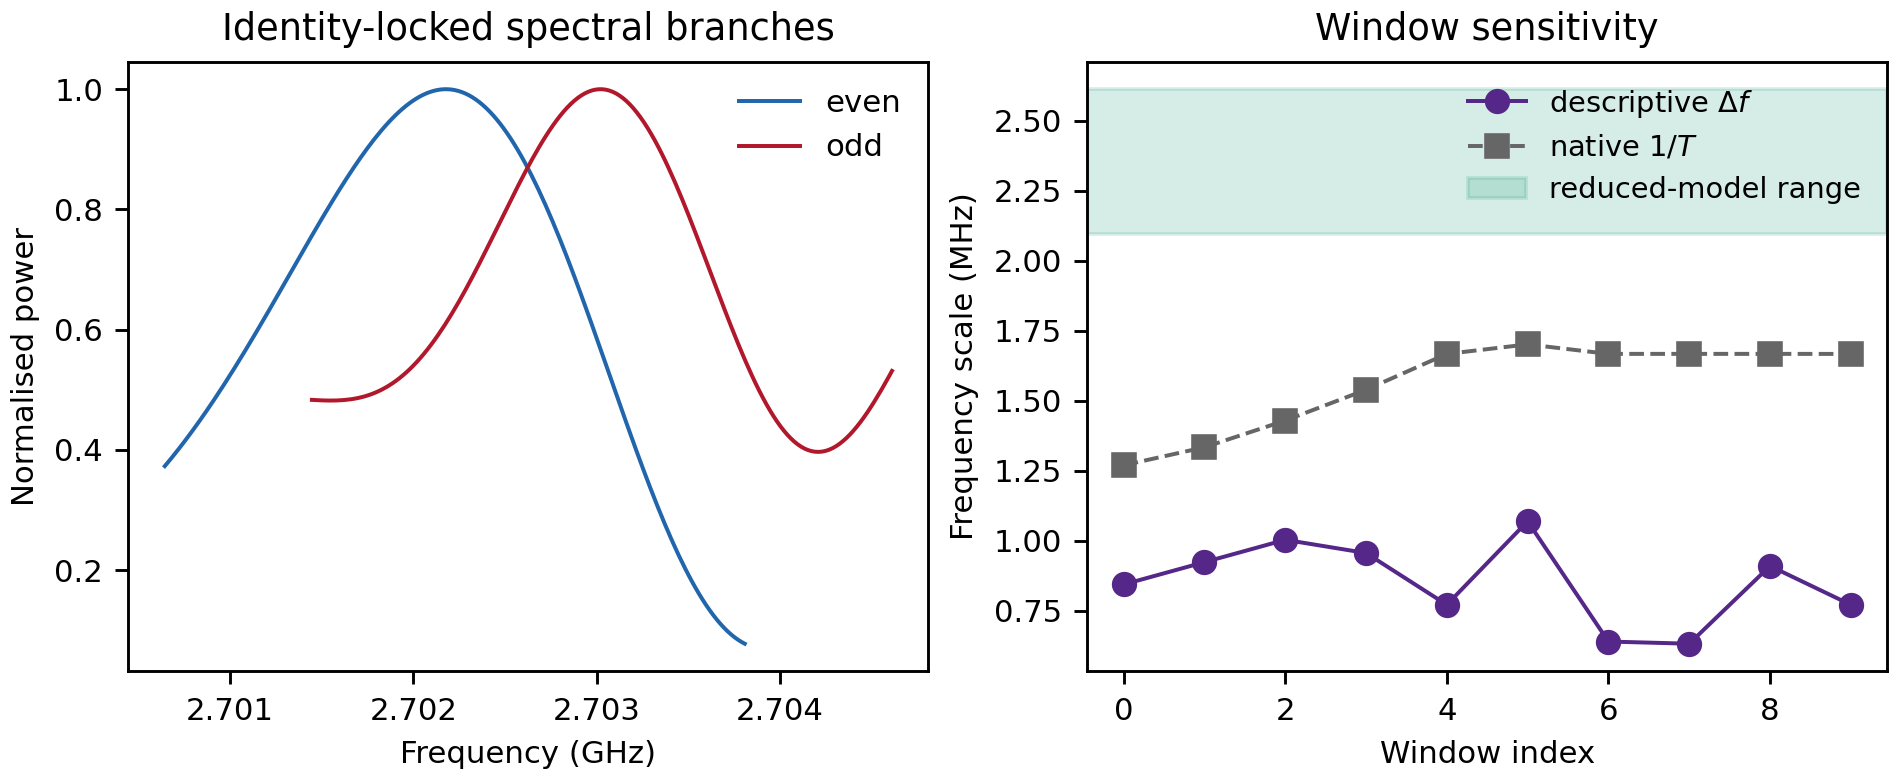

/kaggle/working/jphysd_explicit_double_well_k05d.zip

K05D is analysis-only. A stable sub-bin separation remains descriptive; continue to the combined explicit-double-well plus control full-LLG stage.


In [26]:
"""Kaggle K05D: conservative sub-bin sensitivity audit of K05C.

Run after K05C in the same Kaggle session.  This cell performs no MuMax3
simulation.  It tracks the already identified even and odd branches in many
long time windows, refines each spectral maximum by zero padding plus local
quadratic interpolation, and checks parity-envelope identity again.

Important: a stable sub-bin estimate is descriptive, not a resolved mode
splitting.  Only a separation larger than the native 1/T resolution can be
promoted to a quantitative coupling measurement.
"""
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, re, time, zipfile
import numpy as np

PIPELINE_VERSION = "jphysd-k05d-subbin-sensitivity-v2"
ROOT = Path("/kaggle/working/jphysd_explicit_double_well")
CONFIG = ROOT / "explicit_double_well_config.json"
K05C = ROOT / "k05c_long_window" / "k05c_report.json"
RUNS = ROOT / "k05c_long_window" / "runs"
STAGE = ROOT / "k05d_subbin_sensitivity"
REPORT = STAGE / "k05d_report.json"
ARCHIVE = Path("/kaggle/working/jphysd_explicit_double_well_k05d.zip")

# These are the two reduced-model couplings quoted in the revised manuscript.
REDUCED_K_OVER_2PI_HZ = (1.048e6, 1.306e6)
EXPECTED_SPLITTING_HZ = tuple(2.0 * x for x in REDUCED_K_OVER_2PI_HZ)

# Long, partly overlapping windows.  They are a sensitivity audit, not
# statistically independent samples and therefore are not used as a CI.
WINDOWS_NS = (
    (12.0, 800.0), (50.0, 800.0), (100.0, 800.0),
    (150.0, 800.0), (200.0, 800.0),
    (12.0, 600.0), (50.0, 650.0), (100.0, 700.0),
    (150.0, 750.0), (200.0, 800.0),
)
TRACK_HALF_WIDTH_HZ = 1.60e6
FFT_OVERSAMPLE = 64
IDENTITY_OVERLAP_MIN = 0.95
# The full 12--800 ns record must retain strong parity.  Shorter/truncated
# sensitivity windows only need the correct sign and a conservative floor;
# otherwise a small amount of neighbouring-mode leakage falsely turns a
# completed audit into a pipeline failure.
PRIMARY_PARITY_ABS_MIN = 0.90
WINDOW_PARITY_ABS_FLOOR = 0.70
MEDIAN_PARITY_ABS_MIN = 0.90


def banner(x):
    print("\n" + "=" * 78 + "\n" + x + "\n" + "=" * 78)


def safe(x):
    if isinstance(x, Path): return str(x)
    if isinstance(x, np.generic): return x.item()
    if isinstance(x, np.ndarray): return x.tolist()
    if isinstance(x, dict): return {str(k): safe(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)): return [safe(v) for v in x]
    return x


def write_json(path, obj):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(safe(obj), indent=2, sort_keys=True,
                               allow_nan=False) + "\n")


def sha256(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(1048576), b""):
            h.update(block)
    return h.hexdigest()


def stripe_metadata(config):
    g = config["geometry"]
    sx = g["target_semiaxes_m"][0]
    width = 2.0 * sx / g["x_stripes"]
    return [
        {
            "region": g["first_region"] + i,
            "center_m": -sx + (i + 0.5) * width,
        }
        for i in range(g["x_stripes"])
    ]


def load_table(path):
    lines = Path(path).read_text(errors="replace").splitlines()
    rows = []
    for line in lines:
        if not line.strip() or line.lstrip().startswith("#"):
            continue
        try:
            rows.append([float(x) for x in line.split()])
        except ValueError:
            pass
    if not rows:
        raise RuntimeError(f"No numeric rows in {path}")
    width = max(map(len, rows))
    array = np.asarray([r for r in rows if len(r) == width], dtype=float)
    candidates = []
    for line in lines:
        if line.lstrip().startswith("#"):
            labels = [x.strip() for x in re.split(r"\t+", line.lstrip()[1:].strip()) if x.strip()]
            if len(labels) == width:
                candidates.append(labels)
    if not candidates:
        raise RuntimeError(f"No usable table header in {path}")
    labels = max(candidates, key=lambda q: sum("region" in x.lower() for x in q))
    array = array[np.isfinite(array).all(axis=1)]
    array = array[np.argsort(array[:, 0])]
    _, unique = np.unique(array[:, 0], return_index=True)
    return labels, array[unique]


def region_columns(labels, region):
    found = []
    for i, label in enumerate(labels):
        key = re.sub(r"[^a-z0-9]", "", label.lower().split("(", 1)[0])
        if re.match(rf"^mregion{region}[xyz]$", key):
            found.append(i)
    if len(found) != 3:
        raise RuntimeError(f"Region {region}: found {len(found)} m columns")
    return found


def load_traces(path, config):
    labels, array = load_table(path)
    columns = np.asarray([region_columns(labels, q["region"])
                          for q in stripe_metadata(config)])
    return array[:, 0], array[:, columns]


def parabolic_log_peak(freq, power, index):
    """Quadratic interpolation of log power around one FFT maximum."""
    if index <= 0 or index >= len(power) - 1:
        return float(freq[index])
    y = np.log(np.maximum(power[index - 1:index + 2], np.finfo(float).tiny))
    denominator = y[0] - 2.0 * y[1] + y[2]
    shift = 0.0 if abs(denominator) < 1e-30 else 0.5 * (y[0] - y[2]) / denominator
    shift = float(np.clip(shift, -1.0, 1.0))
    return float(freq[index] + shift * (freq[index + 1] - freq[index]))


def estimate_window(t, magnetisation, config, case, start_ns, end_ns, reference_hz):
    keep = (t >= start_ns * 1e-9) & (t <= end_ns * 1e-9)
    t = t[keep]
    magnetisation = magnetisation[keep]
    if t.size < 1000:
        raise RuntimeError(f"Too few samples in {start_ns}-{end_ns} ns")

    dt = float(np.median(np.diff(t)))
    uniform_t = np.arange(t[0], t[-1] + dt / 4.0, dt)
    uniform_m = np.empty((uniform_t.size, magnetisation.shape[1], 3))
    for stripe in range(magnetisation.shape[1]):
        for component in range(3):
            uniform_m[:, stripe, component] = np.interp(
                uniform_t, t, magnetisation[:, stripe, component])

    signs = np.asarray([
        1.0 if case == "even" or q["center_m"] < 0.0 else -1.0
        for q in stripe_metadata(config)
    ])
    y = np.mean(uniform_m[:, :, 1] * signs[None, :], axis=1)
    z = np.mean(uniform_m[:, :, 2] * signs[None, :], axis=1)
    window = np.hanning(uniform_t.size)
    nfft = 1
    while nfft < FFT_OVERSAMPLE * uniform_t.size:
        nfft *= 2
    freq = np.fft.rfftfreq(nfft, dt)
    spectrum_y = np.fft.rfft(window * (y - np.mean(y)), n=nfft)
    spectrum_z = np.fft.rfft(window * (z - np.mean(z)), n=nfft)
    power = np.abs(spectrum_y) ** 2 + np.abs(spectrum_z) ** 2
    band = ((freq >= reference_hz - TRACK_HALF_WIDTH_HZ) &
            (freq <= reference_hz + TRACK_HALF_WIDTH_HZ))
    ids = np.flatnonzero(band)
    if ids.size < 3:
        raise RuntimeError("Tracking band contains too few FFT points")
    peak_index = int(ids[np.argmax(power[ids])])
    refined_hz = parabolic_log_peak(freq, power, peak_index)
    raw_hz = float(1.0 / (uniform_t[-1] - uniform_t[0]))

    # Evaluate the stripe-resolved complex mode amplitude at the refined peak.
    phase = np.exp(-2j * np.pi * refined_hz * (uniform_t - uniform_t[0]))
    centred_y = uniform_m[:, :, 1] - np.average(uniform_m[:, :, 1], axis=0, weights=window)
    centred_z = uniform_m[:, :, 2] - np.average(uniform_m[:, :, 2], axis=0, weights=window)
    amp_y = phase @ (window[:, None] * centred_y)
    amp_z = phase @ (window[:, None] * centred_z)
    vector = np.r_[amp_y, amp_z]
    reflected = np.r_[amp_y[::-1], amp_z[::-1]]
    parity = float(np.real(np.vdot(vector, reflected)) /
                   max(np.linalg.norm(vector) * np.linalg.norm(reflected), 1e-300))
    envelope = np.sqrt(np.abs(amp_y) ** 2 + np.abs(amp_z) ** 2)

    outside = band & (np.abs(freq - refined_hz) > 3.0 * raw_hz)
    noise = np.median(power[outside]) if np.any(outside) else np.finfo(float).tiny
    snr = float(power[peak_index] / max(noise, np.finfo(float).tiny))
    return {
        "case": case,
        "start_ns": start_ns,
        "end_ns": end_ns,
        "frequency_Hz": refined_hz,
        "native_resolution_Hz": raw_hz,
        "fft_grid_spacing_Hz": float(freq[1] - freq[0]),
        "SNR": snr,
        "parity": parity,
        "envelope": envelope,
        "plot_frequency_Hz": freq[band],
        "plot_power": power[band],
    }


banner("K05D — SUB-BIN SENSITIVITY AND IDENTITY AUDIT")
started = time.time()
checks = {}
report = {
    "pipeline_version": PIPELINE_VERSION,
    "stage": "K05D_subbin_sensitivity",
    "status": "FAIL_K05D",
    "failed_checks": [],
    "started_utc": datetime.now(timezone.utc).isoformat(),
    "scientific_scope": (
        "Analysis-only sensitivity audit. Overlapping windows are not independent; "
        "the resulting range is not a confidence interval and cannot by itself "
        "promote a sub-native-bin separation to a resolved coupling."
    ),
}

try:
    config = json.loads(CONFIG.read_text())
    k05c = json.loads(K05C.read_text())
    checks["K05C_pass"] = k05c.get("status") == "PASS_K05C_LONG_WINDOW_AUDIT"
    checks["K05C_unresolved"] = k05c.get("decision", {}).get("outcome") == "LONG_WINDOW_DOUBLET_SPLITTING_UNRESOLVED"
    table_paths = {case: RUNS / f"{case}.out" / "table.txt" for case in ("even", "odd")}
    checks["raw_tables_exist"] = all(p.is_file() for p in table_paths.values())
    if not all(checks.values()):
        raise RuntimeError("K05C report or raw tables are unavailable")

    STAGE.mkdir(parents=True, exist_ok=True)
    traces = {case: load_traces(path, config) for case, path in table_paths.items()}
    references = {
        case: float(k05c["primary"][case]["frequency_Hz"])
        for case in ("even", "odd")
    }

    estimates = {"even": [], "odd": []}
    for case in ("even", "odd"):
        for start_ns, end_ns in WINDOWS_NS:
            estimates[case].append(estimate_window(
                *traces[case], config, case, start_ns, end_ns, references[case]))

    pairs = []
    for i, (start_ns, end_ns) in enumerate(WINDOWS_NS):
        even = estimates["even"][i]
        odd = estimates["odd"][i]
        delta = abs(even["frequency_Hz"] - odd["frequency_Hz"])
        native = max(even["native_resolution_Hz"], odd["native_resolution_Hz"])
        overlap = float(np.dot(even["envelope"], odd["envelope"]) /
                        max(np.linalg.norm(even["envelope"]) *
                            np.linalg.norm(odd["envelope"]), 1e-300))
        pairs.append({
            "start_ns": start_ns,
            "end_ns": end_ns,
            "even_frequency_Hz": even["frequency_Hz"],
            "odd_frequency_Hz": odd["frequency_Hz"],
            "splitting_Hz": delta,
            "descriptive_K_over_2pi_Hz": delta / 2.0,
            "native_resolution_Hz": native,
            "resolved_in_this_window": delta > native,
            "envelope_overlap": overlap,
            "even_parity": even["parity"],
            "odd_parity": odd["parity"],
            "even_SNR": even["SNR"],
            "odd_SNR": odd["SNR"],
        })
        print(f"{start_ns:5.0f}-{end_ns:5.0f} ns | "
              f"delta={delta/1e6:7.4f} MHz | raw={native/1e6:7.4f} MHz | "
              f"overlap={overlap:.5f} | Pe={even['parity']:+.3f} "
              f"Po={odd['parity']:+.3f}")

    deltas = np.asarray([x["splitting_Hz"] for x in pairs])
    overlaps = np.asarray([x["envelope_overlap"] for x in pairs])
    median_delta = float(np.median(deltas))
    sensitivity_range = [float(np.min(deltas)), float(np.max(deltas))]
    median_abs_deviation = float(np.median(np.abs(deltas - median_delta)))
    any_resolved = any(x["resolved_in_this_window"] for x in pairs)
    primary_parity_ok = (pairs[0]["even_parity"] >= PRIMARY_PARITY_ABS_MIN and
                         pairs[0]["odd_parity"] <= -PRIMARY_PARITY_ABS_MIN)
    all_parity_signs_correct = all(x["even_parity"] > 0.0 and
                                   x["odd_parity"] < 0.0 for x in pairs)
    even_abs_parity = np.asarray([abs(x["even_parity"]) for x in pairs])
    odd_abs_parity = np.asarray([abs(x["odd_parity"]) for x in pairs])
    parity_floor_ok = (float(np.min(even_abs_parity)) >= WINDOW_PARITY_ABS_FLOOR and
                       float(np.min(odd_abs_parity)) >= WINDOW_PARITY_ABS_FLOOR)
    median_parity_ok = (float(np.median(even_abs_parity)) >= MEDIAN_PARITY_ABS_MIN and
                        float(np.median(odd_abs_parity)) >= MEDIAN_PARITY_ABS_MIN)
    parity_robust = (primary_parity_ok and all_parity_signs_correct and
                     parity_floor_ok and median_parity_ok)
    identity_ok = bool(np.min(overlaps) >= IDENTITY_OVERLAP_MIN)
    snr_ok = all(min(x["even_SNR"], x["odd_SNR"]) >= 10.0 for x in pairs)
    stable = (sensitivity_range[1] - sensitivity_range[0]) <= 0.75e6

    checks["all_windows_SNR_at_least_10"] = snr_ok
    checks["primary_window_parity_at_least_0p90"] = primary_parity_ok
    checks["all_window_parity_signs_correct"] = all_parity_signs_correct
    checks["all_window_abs_parity_at_least_0p70"] = parity_floor_ok
    checks["median_abs_parity_at_least_0p90"] = median_parity_ok
    checks["parity_robust_across_windows"] = parity_robust
    checks["identity_overlap_at_least_0p95"] = identity_ok
    checks["subbin_window_range_at_most_0p75MHz"] = stable

    prediction_separated = sensitivity_range[1] < EXPECTED_SPLITTING_HZ[0]
    if any_resolved and parity_robust and identity_ok and stable:
        outcome = "RESOLVED_IDENTITY_MATCHED_SPLITTING"
    elif stable and parity_robust and identity_ok:
        outcome = "STABLE_DESCRIPTIVE_SUBBIN_SEPARATION_NOT_RESOLUTION_VALIDATED"
    else:
        outcome = "MULTIMODE_OR_WINDOW_SENSITIVE_SUBBIN_ESTIMATE"

    report["reduced_model_reference"] = {
        "K_over_2pi_Hz": REDUCED_K_OVER_2PI_HZ,
        "expected_splitting_Hz": EXPECTED_SPLITTING_HZ,
    }
    report["window_pairs"] = pairs
    report["decision"] = {
        "median_descriptive_splitting_Hz": median_delta,
        "descriptive_splitting_sensitivity_range_Hz": sensitivity_range,
        "median_absolute_deviation_Hz": median_abs_deviation,
        "median_descriptive_K_over_2pi_Hz": median_delta / 2.0,
        "any_window_resolved": any_resolved,
        "minimum_envelope_overlap": float(np.min(overlaps)),
        "parity_summary": {
            "primary_even": pairs[0]["even_parity"],
            "primary_odd": pairs[0]["odd_parity"],
            "minimum_absolute_even": float(np.min(even_abs_parity)),
            "minimum_absolute_odd": float(np.min(odd_abs_parity)),
            "median_absolute_even": float(np.median(even_abs_parity)),
            "median_absolute_odd": float(np.median(odd_abs_parity)),
            "robust_across_windows": parity_robust,
        },
        "reduced_model_splitting_above_descriptive_range": prediction_separated,
        "outcome": outcome,
        "manuscript_boundary": (
            "Report the parity-matched doublet qualitatively. Do not report the "
            "sub-bin K as a measured coupling. If the reduced-model range lies "
            "above this descriptive range, state that the present explicit-barrier "
            "LLG run does not quantitatively reproduce the reduced coupling."
        ),
    }

    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.0), constrained_layout=True)
    primary_index = 0
    for case, color in (("even", "#2166ac"), ("odd", "#b2182b")):
        x = estimates[case][primary_index]
        axes[0].plot(x["plot_frequency_Hz"] / 1e9,
                     x["plot_power"] / np.max(x["plot_power"]),
                     color=color, label=case)
    centres = np.arange(len(pairs))
    axes[1].plot(centres, deltas / 1e6, "o-", color="#542788",
                 label="descriptive $\\Delta f$")
    axes[1].plot(centres,
                 np.asarray([x["native_resolution_Hz"] for x in pairs]) / 1e6,
                 "s--", color="#666666", label="native $1/T$")
    axes[1].axhspan(EXPECTED_SPLITTING_HZ[0] / 1e6,
                    EXPECTED_SPLITTING_HZ[1] / 1e6,
                    color="#1b9e77", alpha=0.18, label="reduced-model range")
    axes[0].set(xlabel="Frequency (GHz)", ylabel="Normalised power",
                title="Identity-locked spectral branches")
    axes[1].set(xlabel="Window index", ylabel="Frequency scale (MHz)",
                title="Window sensitivity")
    axes[0].legend(frameon=False)
    axes[1].legend(frameon=False, fontsize=8)
    fig.savefig(STAGE / "k05d_subbin_sensitivity.png", dpi=260)
    fig.savefig(STAGE / "k05d_subbin_sensitivity.pdf")
    plt.close(fig)

    required = [
        "K05C_pass", "K05C_unresolved", "raw_tables_exist",
        "all_windows_SNR_at_least_10",
    ]
    report["required_checks"] = required
    report["failed_checks"] = [x for x in required if not checks.get(x, False)]
    report["status"] = "PASS_K05D_SENSITIVITY_AUDIT" if not report["failed_checks"] else "FAIL_K05D"
    report["input_sha256"] = {str(p): sha256(p) for p in table_paths.values()}
except Exception as exc:
    report["exception"] = {"type": type(exc).__name__, "message": str(exc)}
    report["failed_checks"] = [k for k, v in checks.items() if not v] or ["K05D_exception"]

report["checks"] = checks
report["runtime_s"] = time.time() - started
report["finished_utc"] = datetime.now(timezone.utc).isoformat()
write_json(REPORT, report)

if ARCHIVE.exists():
    ARCHIVE.unlink()
with zipfile.ZipFile(ARCHIVE, "w", zipfile.ZIP_DEFLATED, allowZip64=True) as archive:
    for path in sorted(x for x in STAGE.rglob("*") if x.is_file()):
        archive.write(path, arcname=path.relative_to(STAGE).as_posix())

banner(f"K05D COMPLETE | {report['status']}")
print(json.dumps(safe({
    "status": report["status"],
    "failed_checks": report["failed_checks"],
    "decision": report.get("decision"),
    "exception": report.get("exception"),
    "runtime_s": report["runtime_s"],
    "report": REPORT,
    "archive": ARCHIVE,
}), indent=2, allow_nan=False))

try:
    from IPython.display import FileLink, Image, display
    figure = STAGE / "k05d_subbin_sensitivity.png"
    if figure.is_file():
        display(Image(filename=str(figure)))
    display(FileLink(str(ARCHIVE)))
except Exception:
    pass

if report["status"] != "PASS_K05D_SENSITIVITY_AUDIT":
    raise RuntimeError(f"K05D failed: {report['failed_checks']} | {report.get('exception')}")
print("K05D is analysis-only. A stable sub-bin separation remains descriptive; "
      "continue to the combined explicit-double-well plus control full-LLG stage.")


## 4. Combined double-well target and control body

K06A verifies the common 3D equilibrium. K06B compares equal-amplitude (+q_0) and (-q_0) control preparations using the same target probe. This is a raw direct-dipolar null test without the receiver/transducer.

In [28]:
"""Kaggle K06A: combined explicit-double-well plus control equilibrium.

Run after K05D in the same Kaggle session.  This cell builds one 3-D MuMax3
domain containing the field-defined double-well target and the vertically
separated control disk.  It computes one common equilibrium and audits the
geometry, torque, x-mirror symmetry and saved checkpoint.  The +/-q0 control
states are dynamic preparations, not equilibria; they are intentionally left
for K06B.
"""
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, os, re, shutil, subprocess, time, zipfile
import numpy as np

PIPELINE_VERSION = "jphysd-k06a-combined-equilibrium-v2"
FRESH = Path("/kaggle/working/jphysd_full_llg_fresh")
K00_MANIFEST = FRESH / "locks" / "k00_manifest.json"
FRESH_CONFIG = FRESH / "locks" / "fresh_full_llg_config.json"
MUMAX = FRESH / "bin" / "mumax3"

EXPLICIT = Path("/kaggle/working/jphysd_explicit_double_well")
EXPLICIT_CONFIG = EXPLICIT / "explicit_double_well_config.json"
K05D_REPORT = EXPLICIT / "k05d_subbin_sensitivity" / "k05d_report.json"

ROOT = Path("/kaggle/working/jphysd_combined_double_well_control")
STAGE = ROOT / "k06a_equilibrium"
SCRIPTS = STAGE / "scripts"
RUNS = STAGE / "runs"
LOGS = STAGE / "logs"
CACHE = ROOT / "demag_cache"
CONFIG_OUT = ROOT / "combined_config.json"
REPORT = STAGE / "k06a_report.json"
ARCHIVE = Path("/kaggle/working/jphysd_combined_double_well_control_k06a.zip")
MAX_RUNTIME_S = 3.0 * 3600


def banner(x):
    print("\n" + "=" * 78 + "\n" + x + "\n" + "=" * 78)


def fmt(x):
    return f"{float(x):.12e}"


def safe(x):
    if isinstance(x, Path): return str(x)
    if isinstance(x, np.generic): return x.item()
    if isinstance(x, np.ndarray): return x.tolist()
    if isinstance(x, dict): return {str(k): safe(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)): return [safe(v) for v in x]
    return x


def write_json(path, obj):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(safe(obj), indent=2, sort_keys=True,
                               allow_nan=False) + "\n")


def sha256(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(1048576), b""):
            h.update(block)
    return h.hexdigest()


def write_locked(path, text):
    payload = (text.rstrip() + "\n").encode()
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and path.read_bytes() != payload:
        raise RuntimeError(f"Immutable script conflict: {path}")
    if not path.exists():
        path.write_bytes(payload)
    return sha256(path)


def combined_config(fresh, explicit):
    medium = next(x for x in fresh["meshes"] if x["label"] == "medium")
    return {
        "pipeline_version": PIPELINE_VERSION,
        "scope": (
            "One common 3-D equilibrium containing the explicit prescribed-field "
            "double-well target and dipolarly coupled control disk. No +/-q0 "
            "contrast, mode splitting, conditional gate or CNOT is claimed in K06A."
        ),
        "material": fresh["material"],
        "solver": fresh["solver"],
        "mesh": medium,
        "geometry": fresh["geometry"],
        "logical_control": fresh["logical_control"],
        "field_double_well": explicit["field_double_well"],
        "regions": {
            "control_first": 10,
            "control_x_stripes": 16,
            "target_first": 100,
            "target_x_stripes": 48,
        },
        "source_hashes": {
            "fresh_config_sha256": sha256(FRESH_CONFIG),
            "explicit_config_sha256": sha256(EXPLICIT_CONFIG),
            "K05D_report_sha256": sha256(K05D_REPORT),
        },
    }


def stripe_metadata(config, body):
    regions = config["regions"]
    geometry = config["geometry"]
    if body == "control":
        centre = geometry["control"]["center_m"][0]
        half = geometry["control"]["radius_m"]
        first = regions["control_first"]
        count = regions["control_x_stripes"]
    else:
        centre = geometry["target"]["center_m"][0]
        half = geometry["target"]["semiaxes_m"][0]
        first = regions["target_first"]
        count = regions["target_x_stripes"]
    width = 2.0 * half / count
    return [{
        "region": first + i,
        "left_m": centre - half + i * width,
        "right_m": centre - half + (i + 1) * width,
        "center_m": centre - half + (i + 0.5) * width,
    } for i in range(count)]


def geometry_lines(config):
    mesh = config["mesh"]
    geometry = config["geometry"]
    control = geometry["control"]
    target = geometry["target"]
    thickness = geometry["film_thickness_m"]
    cx, cy, cz = control["center_m"]
    tx, ty, tz = target["center_m"]
    sx, sy = target["semiaxes_m"]
    lines = [
        f"SetGridSize({mesh['nx']},{mesh['ny']},{mesh['nz']})",
        f"SetCellSize({fmt(mesh['dx_m'])},{fmt(mesh['dy_m'])},{fmt(mesh['dz_m'])})",
        "SetPBC(0,0,0)", "OutputFormat=OVF2_BINARY",
        f"EdgeSmooth={int(config['solver']['edge_smooth'])}",
        f"DemagAccuracy={fmt(config['solver']['demag_accuracy'])}",
        f"control:=Cylinder({fmt(2*control['radius_m'])},{fmt(thickness)}).Transl({fmt(cx)},{fmt(cy)},{fmt(cz)})",
        f"targetXY:=Ellipse({fmt(2*sx)},{fmt(2*sy)}).Transl({fmt(tx)},{fmt(ty)},0)",
        f"targetZ:=ZRange({fmt(tz-thickness/2)},{fmt(tz+thickness/2)})",
        "target:=targetXY.Intersect(targetZ)",
        "device:=control.Add(target)", "SetGeom(device)",
    ]
    for body in ("control", "target"):
        for stripe in stripe_metadata(config, body):
            lines.append(
                f"DefRegion({stripe['region']},{body}.Intersect(XRange("
                f"{fmt(stripe['left_m'])},{fmt(stripe['right_m'])})))")
    r = config["regions"]
    lines += [
        f"for rc:={r['control_first']}; rc<{r['control_first']+r['control_x_stripes']}; rc++ {{",
        f" for rt:={r['target_first']}; rt<{r['target_first']+r['target_x_stripes']}; rt++ {{ ext_ScaleExchange(rc,rt,0) }}",
        "}",
    ]
    return lines


def material_lines(config):
    material = config["material"]
    return [
        f"Msat={fmt(material['Msat_A_per_m'])}",
        f"Aex={fmt(material['Aex_J_per_m'])}",
        f"alpha={fmt(material['alpha'])}",
        f"Kc1={fmt(material['Kc1_J_per_m3'])}",
        "Dind=0", "Dbulk=0", "Temp=0",
    ]


def equilibrium_script(config):
    solver = config["solver"]
    field = config["field_double_well"]
    barrier_half = field["barrier_width_m"] / 2.0
    lines = [
        "// K06A combined explicit-double-well plus control equilibrium",
        "// The target barrier is a prescribed longitudinal Zeeman field.",
    ] + geometry_lines(config) + material_lines(config)
    lines += [
        f"B0:={fmt(field['bias_T'])}",
        f"Bbar:={fmt(field['barrier_increment_T'])}",
        "B_ext=vector(B0,0,0)",
    ]
    barrier_regions = []
    for stripe in stripe_metadata(config, "target"):
        if abs(stripe["center_m"]) < barrier_half:
            barrier_regions.append(stripe["region"])
            lines.append(f"B_ext.SetRegion({stripe['region']},vector(B0+Bbar,0,0))")
    lines += [
        "m=uniform(1,1e-3,0)",
        f"MinimizerStop={fmt(solver['minimizer_stop_T'])}",
        f"MinimizerSamples={int(solver['minimizer_samples'])}",
        "minOK:=Minimize()",
        'Print("MINIMIZE_CONVERGED=",minOK)',
        'Print("MAX_TORQUE_T=",maxTorque.Get())',
        'Print("E_TOTAL_J=",E_total.Get())',
    ]
    for body in ("control", "target"):
        for stripe in stripe_metadata(config, body):
            lines.append(f"TableAdd(m.Region({stripe['region']}))")
    lines += [
        "TableAdd(E_total)", "TableAdd(E_demag)", "TableAdd(E_exch)",
        "TableAdd(maxTorque)", "TableSave()",
        'SaveAs(geom,"geom")', 'SaveAs(regions,"regions")',
        'SaveAs(B_ext,"bias_and_barrier_field")',
        'SaveAs(m,"m_equilibrium")',
        'SaveAs(B_demag,"Bdemag_equilibrium")',
        'SaveAs(B_eff,"Beff_equilibrium")', "Flush()",
    ]
    return "\n".join(lines), barrier_regions


def run_logged(command, env, log_path, timeout_s):
    command = [str(x) for x in command]
    print("$", " ".join(command), flush=True)
    started = time.time()
    log_path.parent.mkdir(parents=True, exist_ok=True)
    with log_path.open("w") as log:
        process = subprocess.Popen(command, env=env, text=True,
                                   stdout=log, stderr=subprocess.STDOUT)
        heartbeat = started + 60.0
        timed_out = False
        while process.poll() is None:
            time.sleep(2)
            if time.time() >= heartbeat:
                print(f"[equilibrium] running {time.time()-started:.0f} s", flush=True)
                heartbeat += 60.0
            if time.time() - started > timeout_s:
                process.kill(); timed_out = True; break
        returncode = process.wait()
    text = log_path.read_text(errors="replace")
    print(text[-4000:])
    print(f"return={returncode} timeout={timed_out} runtime={time.time()-started:.1f} s")
    return {"returncode": returncode, "timed_out": timed_out,
            "runtime_s": time.time()-started, "log": str(log_path), "text": text}


def load_table(path):
    lines = Path(path).read_text(errors="replace").splitlines()
    rows = []
    for line in lines:
        if not line.strip() or line.lstrip().startswith("#"): continue
        try: rows.append([float(x) for x in line.split()])
        except ValueError: pass
    width = max(map(len, rows))
    array = np.asarray([r for r in rows if len(r) == width], dtype=float)
    headers = []
    for line in lines:
        if line.lstrip().startswith("#"):
            labels = [x.strip() for x in re.split(r"\t+", line.lstrip()[1:].strip()) if x.strip()]
            if len(labels) == width: headers.append(labels)
    labels = max(headers, key=lambda q: sum("region" in x.lower() for x in q))
    return labels, array[-1]


def region_m(labels, row, region):
    values = []
    for i, label in enumerate(labels):
        key = re.sub(r"[^a-z0-9]", "", label.lower().split("(", 1)[0])
        if re.match(rf"^mregion{region}[xyz]$", key): values.append(row[i])
    if len(values) != 3: raise RuntimeError(f"Region {region}: found {len(values)} m columns")
    return np.asarray(values)


def ovf_header(path):
    header = {}
    with Path(path).open("rb") as stream:
        for _ in range(250):
            line = stream.readline().decode("latin1", errors="replace").strip()
            if line.startswith("#") and ":" in line:
                key, value = line[1:].split(":", 1); header[key.strip().lower()] = value.strip()
            if "Begin: Data" in line: break
    return header


banner("K06A — COMBINED EXPLICIT DOUBLE-WELL + CONTROL EQUILIBRIUM")
started = time.time()
checks = {}
report = {
    "pipeline_version": PIPELINE_VERSION,
    "stage": "K06A_combined_equilibrium",
    "status": "FAIL_K06A",
    "failed_checks": [],
    "started_utc": datetime.now(timezone.utc).isoformat(),
}

try:
    fresh = json.loads(FRESH_CONFIG.read_text())
    explicit = json.loads(EXPLICIT_CONFIG.read_text())
    k00 = json.loads(K00_MANIFEST.read_text())
    k05d = json.loads(K05D_REPORT.read_text())
    checks["K00_pass"] = k00.get("status") == "PASS_K00_FRESH"
    checks["K05D_pass"] = k05d.get("status") == "PASS_K05D_SENSITIVITY_AUDIT"
    checks["K05D_preserves_unresolved_boundary"] = not k05d.get("decision", {}).get("any_window_resolved", True)
    if not all(checks.values()): raise RuntimeError("K00/K05D prerequisite failed")

    config = combined_config(fresh, explicit)
    write_json(CONFIG_OUT, config)
    for directory in (STAGE, SCRIPTS, RUNS, LOGS, CACHE):
        directory.mkdir(parents=True, exist_ok=True)
    environment = os.environ.copy()
    environment["LD_LIBRARY_PATH"] = k00["dynamic_linking"]["LD_LIBRARY_PATH"]

    print("PHASE 1/5 — generate and vet combined geometry")
    text, barrier_regions = equilibrium_script(config)
    script = SCRIPTS / "combined_equilibrium.mx3"
    script_hash = write_locked(script, text)
    vet = subprocess.run([MUMAX, "-vet", "-f", "-http=", script],
                         env=environment, text=True, stdout=subprocess.PIPE,
                         stderr=subprocess.STDOUT, timeout=300)
    print(vet.stdout[-3000:])
    checks["script_vet"] = vet.returncode == 0
    if not checks["script_vet"]: raise RuntimeError("K06A script vet failed")

    print("PHASE 2/5 — run or reuse common equilibrium")
    output = RUNS / "combined_equilibrium.out"
    equilibrium = output / "m_equilibrium.ovf"
    reused = equilibrium.is_file() and (output / "table.txt").is_file()
    if reused:
        execution = {"returncode": 0, "timed_out": False, "runtime_s": 0.0,
                     "log": "checkpoint", "text": "", "reused": True}
    else:
        if output.exists():
            backup = STAGE / f"incomplete_{datetime.now().strftime('%Y%m%d_%H%M%S')}.out"
            shutil.move(str(output), str(backup))
        execution = run_logged(
            [MUMAX, "-gpu=0", "-failfast", "-http=", "-cache", CACHE,
             "-o", output, script], environment, LOGS / "equilibrium.log",
            MAX_RUNTIME_S)
        execution["reused"] = False
    checks["equilibrium_completed"] = (execution["returncode"] == 0 and
                                        not execution["timed_out"] and equilibrium.is_file())
    if not checks["equilibrium_completed"]: raise RuntimeError("Combined equilibrium failed")

    print("PHASE 3/5 — torque, magnetisation and mirror audit")
    labels, row = load_table(output / "table.txt")
    control_m = np.asarray([region_m(labels, row, q["region"])
                            for q in stripe_metadata(config, "control")])
    target_m = np.asarray([region_m(labels, row, q["region"])
                           for q in stripe_metadata(config, "target")])
    torque_column = next((i for i, x in enumerate(labels)
                          if "maxtorque" in re.sub(r"[^a-z0-9]", "", x.lower())), None)
    torque = float(row[torque_column]) if torque_column is not None else None
    # Magnetisation is an axial (pseudo-)vector.  Under reflection x -> -x,
    # its components transform as (mx,my,mz) -> (mx,-my,-mz), not as three
    # independent even scalars.  The v1 scalar comparison falsely classified
    # the physically symmetric transverse curling as mirror breaking.
    axial_x_reflection = np.asarray([1.0, -1.0, -1.0])
    target_axial_mirror_rms = float(np.sqrt(np.mean(
        (target_m - target_m[::-1] * axial_x_reflection[None, :])**2)))
    control_axial_mirror_rms = float(np.sqrt(np.mean(
        (control_m - control_m[::-1] * axial_x_reflection[None, :])**2)))
    checks["torque_below_2uT"] = torque is not None and torque <= 2e-6
    checks["control_mean_mx_above_0p99"] = float(np.mean(control_m[:, 0])) >= 0.99
    checks["target_mean_mx_above_0p99"] = float(np.mean(target_m[:, 0])) >= 0.99
    checks["target_axial_x_mirror_rms_below_1e_3"] = target_axial_mirror_rms <= 1e-3
    checks["control_axial_x_mirror_rms_below_1e_3"] = control_axial_mirror_rms <= 1e-3

    print("PHASE 4/5 — geometry and checkpoint audit")
    required_outputs = {name: output / f"{name}.ovf" for name in (
        "geom", "regions", "bias_and_barrier_field", "m_equilibrium",
        "Bdemag_equilibrium", "Beff_equilibrium")}
    checks["all_OVFs_exist"] = all(p.is_file() and p.stat().st_size > 100
                                    for p in required_outputs.values())
    headers = {name: ovf_header(path) for name, path in required_outputs.items()}
    mesh = config["mesh"]
    checks["OVF_grids_match"] = all(
        int(h.get("xnodes", -1)) == mesh["nx"] and
        int(h.get("ynodes", -1)) == mesh["ny"] and
        int(h.get("znodes", -1)) == mesh["nz"] for h in headers.values())
    geometry = config["geometry"]
    checks["surface_gap_is_120nm"] = abs(geometry["surface_gap_m"] - 120e-9) < 1e-18
    checks["bodies_are_8_z_cells_thick"] = abs(
        geometry["film_thickness_m"] / mesh["dz_m"] - 8.0) < 1e-9
    checks["barrier_regions_present"] = len(barrier_regions) > 0

    report["config_sha256"] = sha256(CONFIG_OUT)
    report["script_sha256"] = script_hash
    report["execution"] = {k: v for k, v in execution.items() if k != "text"}
    report["equilibrium"] = {
        "checkpoint": equilibrium,
        "max_torque_T": torque,
        "control_mean_m": np.mean(control_m, axis=0),
        "target_mean_m": np.mean(target_m, axis=0),
        "axial_vector_mirror_rule": "x reflection maps (mx,my,mz) to (mx,-my,-mz)",
        "target_axial_x_mirror_RMS": target_axial_mirror_rms,
        "control_axial_x_mirror_RMS": control_axial_mirror_rms,
    }
    report["geometry_audit"] = {
        "mesh": mesh,
        "surface_gap_nm": geometry["surface_gap_m"] * 1e9,
        "film_thickness_nm": geometry["film_thickness_m"] * 1e9,
        "barrier_width_um": config["field_double_well"]["barrier_width_m"] * 1e6,
        "barrier_increment_mT": config["field_double_well"]["barrier_increment_T"] * 1e3,
        "barrier_region_count": len(barrier_regions),
        "target_region_count": config["regions"]["target_x_stripes"],
        "model_boundary": (
            "Full 3-D LLG and self-consistent dipolar coupling between two YIG bodies; "
            "the target barrier remains a prescribed longitudinal Zeeman field."
        ),
    }

    print("PHASE 5/5 — decision and archive")
    required = [
        "K00_pass", "K05D_pass", "K05D_preserves_unresolved_boundary",
        "script_vet", "equilibrium_completed", "torque_below_2uT",
        "control_mean_mx_above_0p99", "target_mean_mx_above_0p99",
        "target_axial_x_mirror_rms_below_1e_3",
        "control_axial_x_mirror_rms_below_1e_3", "all_OVFs_exist",
        "OVF_grids_match", "surface_gap_is_120nm",
        "bodies_are_8_z_cells_thick", "barrier_regions_present",
    ]
    report["required_checks"] = required
    report["failed_checks"] = [x for x in required if not checks.get(x, False)]
    report["status"] = "PASS_K06A_COMBINED_EQUILIBRIUM" if not report["failed_checks"] else "FAIL_K06A"
except Exception as exc:
    report["exception"] = {"type": type(exc).__name__, "message": str(exc)}
    report["failed_checks"] = [k for k, v in checks.items() if not v] or ["K06A_exception"]

report["checks"] = checks
report["runtime_s"] = time.time() - started
report["finished_utc"] = datetime.now(timezone.utc).isoformat()
write_json(REPORT, report)

manifest = {}
for path in sorted(x for x in STAGE.rglob("*")
                   if x.is_file() and "demag_cache" not in x.parts):
    manifest[path.relative_to(STAGE).as_posix()] = {
        "bytes": path.stat().st_size, "sha256": sha256(path)}
write_json(STAGE / "k06a_file_manifest.json", manifest)

if ARCHIVE.exists(): ARCHIVE.unlink()
with zipfile.ZipFile(ARCHIVE, "w", zipfile.ZIP_DEFLATED, allowZip64=True) as archive:
    for path in sorted(x for x in STAGE.rglob("*")
                       if x.is_file() and "demag_cache" not in x.parts):
        archive.write(path, arcname=path.relative_to(STAGE).as_posix())
    archive.write(CONFIG_OUT, arcname="combined_config.json")

banner(f"K06A COMPLETE | {report['status']}")
print(json.dumps(safe({
    "status": report["status"],
    "failed_checks": report["failed_checks"],
    "equilibrium": report.get("equilibrium"),
    "geometry_audit": report.get("geometry_audit"),
    "exception": report.get("exception"),
    "runtime_s": report["runtime_s"],
    "report": REPORT,
    "archive": ARCHIVE,
}), indent=2, allow_nan=False))

try:
    from IPython.display import FileLink, display
    display(FileLink(str(ARCHIVE)))
except Exception:
    pass

if report["status"] != "PASS_K06A_COMBINED_EQUILIBRIUM":
    raise RuntimeError(f"K06A failed: {report['failed_checks']} | {report.get('exception')}")
print("K06A passed. The common combined-device checkpoint is ready. Next: K06B "
      "paired +/-q0 dynamics with simultaneous even/odd target probing; do not "
      "interpret K06A alone as conditional switching or CNOT evidence.")



K06A — COMBINED EXPLICIT DOUBLE-WELL + CONTROL EQUILIBRIUM
PHASE 1/5 — generate and vet combined geometry
//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-10.2]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 2, MHz: 2000.174
//GPU info: Tesla T4(14911MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 5a648f3e6a30
//Timestamp: 2026-07-21 13:53:43
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
/kaggle/working/jphysd_combined_double_well_control/k06a_equilibrium/scripts/combined_equilibrium.mx3 : OK

PHASE 2/5 — run or reuse common equilibrium
PHASE 3/5 — torque,

/kaggle/working/jphysd_combined_double_well_control_k06a.zip

K06A passed. The common combined-device checkpoint is ready. Next: K06B paired +/-q0 dynamics with simultaneous even/odd target probing; do not interpret K06A alone as conditional switching or CNOT evidence.



K06B — PAIRED COMBINED-DEVICE DIRECT DYNAMICS
PHASE 1/4 — generate and vet paired scripts
vet combined_plus_q0_90ns.mx3: return=0
vet combined_minus_q0_90ns.mx3: return=0
PHASE 2/4 — concurrent paired GPU runs
PHASE 3/4 — blind parity-sector and control-retention comparison
even: plus=3.0785841 GHz minus=3.0803549 GHz delta=1.771 MHz raw=11.368 MHz
odd: plus=2.8355701 GHz minus=2.8362698 GHz delta=0.700 MHz raw=11.368 MHz
PHASE 4/4 — figure, report and archive

K06B COMPLETE | PASS_K06B_PAIRED_DIRECT_AUDIT
{
  "status": "PASS_K06B_PAIRED_DIRECT_AUDIT",
  "failed_checks": [],
  "comparison": {
    "initial_control_projection_relative_difference": 1.210642202915843e-09,
    "early_2to7ns_control_projection_relative_difference": 0.014275593618865145,
    "sectors": {
      "even": {
        "plus_peak_Hz": 3078584117.4072886,
        "minus_peak_Hz": 3080354934.5816836,
        "frequency_difference_Hz": 1770817.1743950844,
        "raw_resolution_Hz": 11368036.263477925,
        "freque

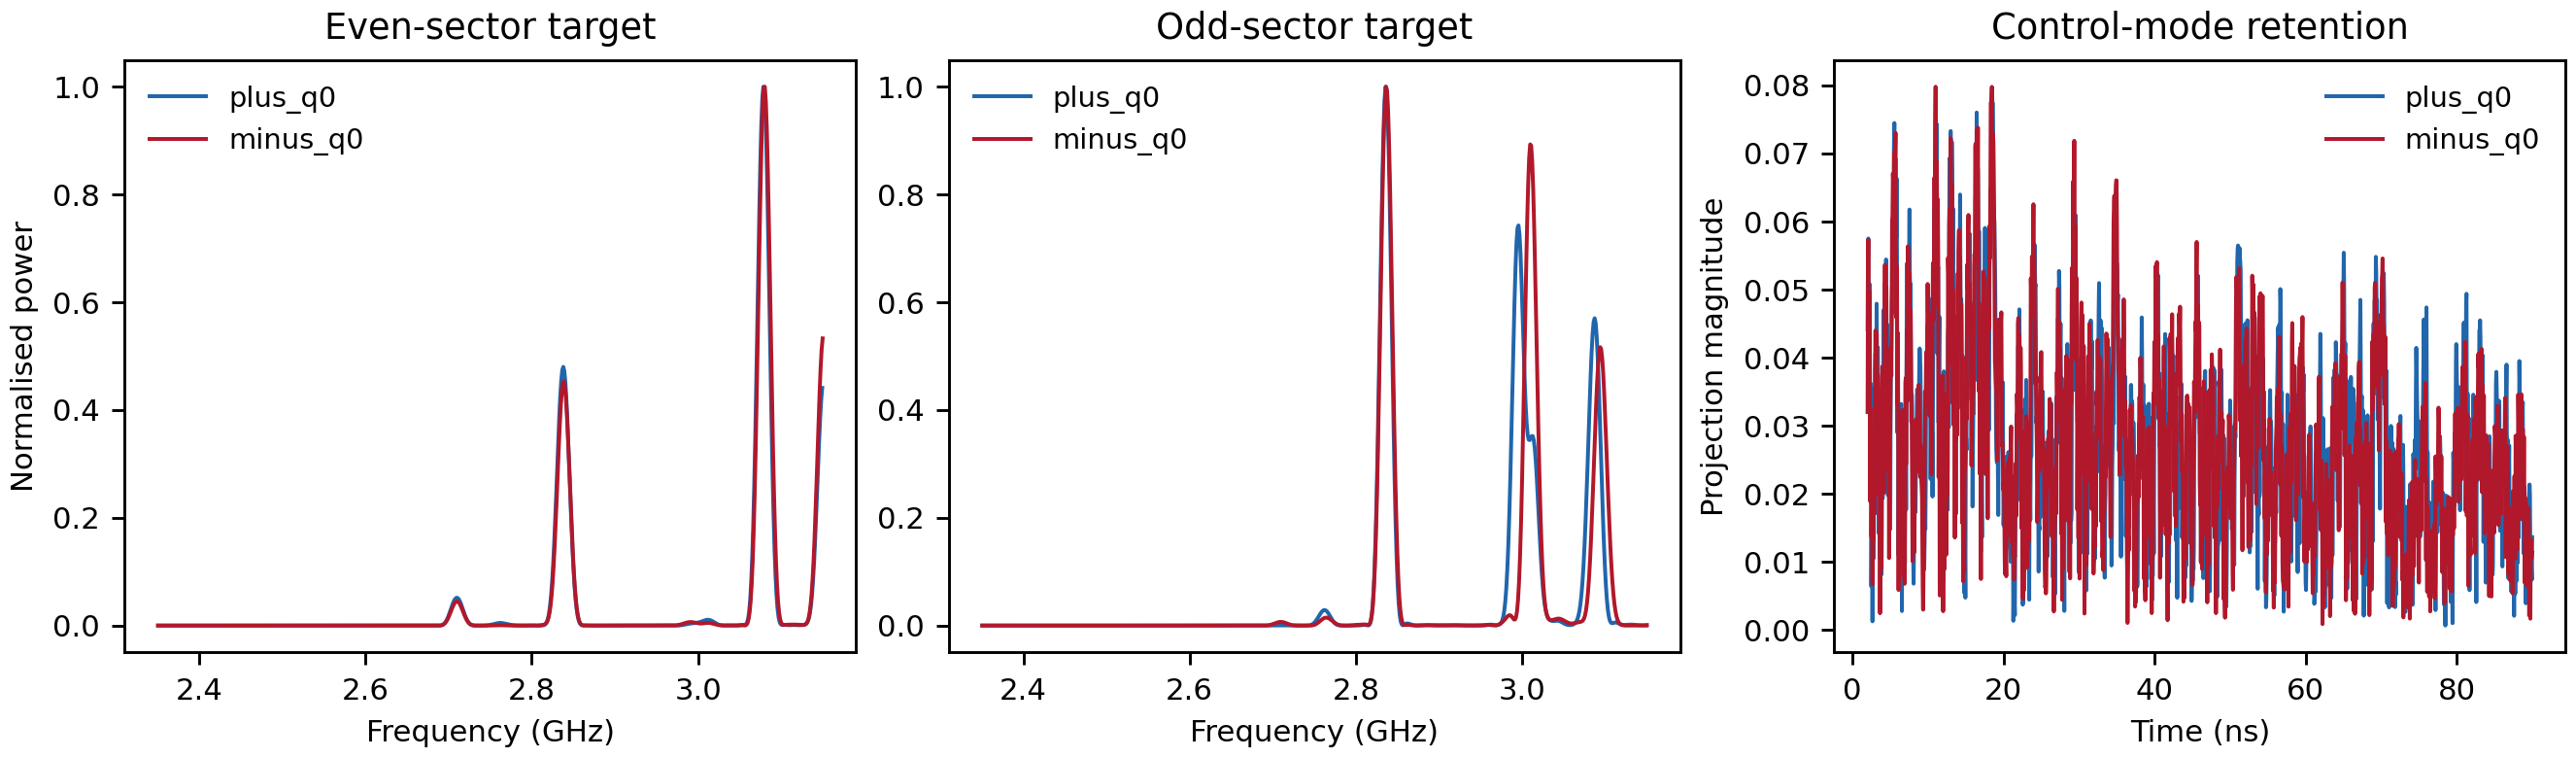

/kaggle/working/jphysd_combined_double_well_control_k06b.zip

K06B audit complete. Preserve a null direct-q result. This cell does not contain the receiver/transducer and cannot be cited as a full CNOT simulation.


In [30]:
"""Kaggle K06B: paired +/-q0 dynamics in the combined double-well device.

Run after K06A in the same Kaggle session.  Two equal-amplitude control states
that differ only by wave-vector sign are launched concurrently on two GPUs.
The target receives one common weak broadband probe containing both spatial
parity sectors.  The analysis is blind and preserves null outcomes.

This is a test of raw direct dipolar coupling.  It does not contain the
wave-vector-selective receiver/barrier-transducer assumed by the reduced 2-D
model and therefore cannot, by itself, validate receiver-mediated conditional
switching or a CNOT operation.
"""
from pathlib import Path
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor
import hashlib, json, os, re, shutil, subprocess, time, zipfile
import numpy as np

PIPELINE_VERSION = "jphysd-k06b-paired-combined-dynamics-v2"
FRESH = Path("/kaggle/working/jphysd_full_llg_fresh")
K00 = FRESH / "locks" / "k00_manifest.json"
MUMAX = FRESH / "bin" / "mumax3"

ROOT = Path("/kaggle/working/jphysd_combined_double_well_control")
CONFIG = ROOT / "combined_config.json"
K06A = ROOT / "k06a_equilibrium" / "k06a_report.json"
EQUILIBRIUM = (ROOT / "k06a_equilibrium" / "runs" /
               "combined_equilibrium.out" / "m_equilibrium.ovf")
STAGE = ROOT / "k06b_paired_dynamics"
SCRIPTS = STAGE / "scripts"
RUNS = STAGE / "runs"
LOGS = STAGE / "logs"
CACHE = ROOT / "demag_cache"
REPORT = STAGE / "k06b_report.json"
ARCHIVE = Path("/kaggle/working/jphysd_combined_double_well_control_k06b.zip")

DURATION_S = 90e-9
PULSE_END_S = 1e-9
TABLE_PERIOD_S = 50e-12
AUTOSAVE_PERIOD_S = 30e-9
PROBE_AMPLITUDE_T = 20e-6
PROBE_BANDWIDTH_HZ = 10e9
PROBE_CENTER_S = 0.20e-9
ANALYSIS_START_S = 2e-9
SEARCH_BAND_HZ = (2.35e9, 3.15e9)
MAX_RUNTIME_S = 3.30 * 3600


def banner(x):
    print("\n" + "=" * 78 + "\n" + x + "\n" + "=" * 78)


def fmt(x):
    return f"{float(x):.12e}"


def safe(x):
    if isinstance(x, Path): return str(x)
    if isinstance(x, np.generic): return x.item()
    if isinstance(x, np.ndarray): return x.tolist()
    if isinstance(x, dict): return {str(k): safe(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)): return [safe(v) for v in x]
    return x


def write_json(path, obj):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(safe(obj), indent=2, sort_keys=True,
                               allow_nan=False) + "\n")


def sha256(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(1048576), b""):
            h.update(block)
    return h.hexdigest()


def write_locked(path, text):
    payload = (text.rstrip() + "\n").encode()
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and path.read_bytes() != payload:
        raise RuntimeError(f"Immutable script conflict: {path}")
    if not path.exists(): path.write_bytes(payload)
    return sha256(path)


def stripes(config, body):
    r = config["regions"]
    g = config["geometry"]
    if body == "control":
        x0 = g["control"]["center_m"][0]
        half = g["control"]["radius_m"]
        first, count = r["control_first"], r["control_x_stripes"]
    else:
        x0 = g["target"]["center_m"][0]
        half = g["target"]["semiaxes_m"][0]
        first, count = r["target_first"], r["target_x_stripes"]
    width = 2.0 * half / count
    return [{
        "region": first + i,
        "left_m": x0 - half + i * width,
        "right_m": x0 - half + (i + 1) * width,
        "center_m": x0 - half + (i + 0.5) * width,
    } for i in range(count)]


def geometry_lines(config):
    mesh, g, r = config["mesh"], config["geometry"], config["regions"]
    co, ta, thick = g["control"], g["target"], g["film_thickness_m"]
    cx, cy, cz = co["center_m"]
    tx, ty, tz = ta["center_m"]
    sx, sy = ta["semiaxes_m"]
    lines = [
        f"SetGridSize({mesh['nx']},{mesh['ny']},{mesh['nz']})",
        f"SetCellSize({fmt(mesh['dx_m'])},{fmt(mesh['dy_m'])},{fmt(mesh['dz_m'])})",
        "SetPBC(0,0,0)", "OutputFormat=OVF2_BINARY",
        f"EdgeSmooth={int(config['solver']['edge_smooth'])}",
        f"DemagAccuracy={fmt(config['solver']['demag_accuracy'])}",
        f"control:=Cylinder({fmt(2*co['radius_m'])},{fmt(thick)}).Transl({fmt(cx)},{fmt(cy)},{fmt(cz)})",
        f"targetXY:=Ellipse({fmt(2*sx)},{fmt(2*sy)}).Transl({fmt(tx)},{fmt(ty)},0)",
        f"targetZ:=ZRange({fmt(tz-thick/2)},{fmt(tz+thick/2)})",
        "target:=targetXY.Intersect(targetZ)",
        "device:=control.Add(target)", "SetGeom(device)",
    ]
    for body in ("control", "target"):
        for q in stripes(config, body):
            lines.append(f"DefRegion({q['region']},{body}.Intersect(XRange({fmt(q['left_m'])},{fmt(q['right_m'])})))")
    lines += [
        f"for rc:={r['control_first']}; rc<{r['control_first']+r['control_x_stripes']}; rc++ {{",
        f" for rt:={r['target_first']}; rt<{r['target_first']+r['target_x_stripes']}; rt++ {{ ext_ScaleExchange(rc,rt,0) }}",
        "}",
    ]
    return lines


def material_lines(config):
    m = config["material"]
    return [f"Msat={fmt(m['Msat_A_per_m'])}", f"Aex={fmt(m['Aex_J_per_m'])}",
            f"alpha={fmt(m['alpha'])}", f"Kc1={fmt(m['Kc1_J_per_m3'])}",
            "Dind=0", "Dbulk=0", "Temp=0"]


def static_field_lines(config, declare=True):
    field = config["field_double_well"]
    lines = ([f"B0:={fmt(field['bias_T'])}",
              f"Bbar:={fmt(field['barrier_increment_T'])}"] if declare else [])
    lines.append("B_ext=vector(B0,0,0)")
    half = field["barrier_width_m"] / 2.0
    for q in stripes(config, "target"):
        if abs(q["center_m"]) < half:
            lines.append(f"B_ext.SetRegion({q['region']},vector(B0+Bbar,0,0))")
    return lines


def dynamic_script(config, sign):
    label = "plus_q0" if sign > 0 else "minus_q0"
    solver = config["solver"]
    logical = config["logical_control"]
    q = sign * logical["q0_rad_per_m"]
    lines = [
        f"// K06B paired combined-device dynamics: {label}",
        "// Equal control amplitude; wave-vector sign is the only case change.",
        "// Direct dipolar audit: no receiver/transducer field is inserted.",
    ] + geometry_lines(config) + material_lines(config) + static_field_lines(config)
    lines += [
        f'm.LoadFile("{EQUILIBRIUM}")',
        f"m.SetInShape(control,Conical(vector({fmt(q)},0,0),vector(1,0,0),{fmt(logical['cone_angle_rad'])}))",
    ]
    for body in ("control", "target"):
        for stripe in stripes(config, body):
            lines.append(f"TableAdd(m.Region({stripe['region']}))")
    lines += [
        "TableAdd(E_total)", "TableAdd(maxTorque)",
        f"TableAutoSave({fmt(TABLE_PERIOD_S)})", f"AutoSave(m,{fmt(AUTOSAVE_PERIOD_S)})",
        "TableSave()", f"SetSolver({int(solver['dynamic_solver_id'])})",
        f"MaxErr={fmt(solver['MaxErr'])}", f"MaxDt={fmt(solver['MaxDt_s'])}",
        f"MinDt={fmt(solver['MinDt_s'])}", f"Ap:={fmt(PROBE_AMPLITUDE_T)}",
        f"bw:={fmt(PROBE_BANDWIDTH_HZ)}", f"t0:={fmt(PROBE_CENTER_S)}",
    ]
    barrier_half = config["field_double_well"]["barrier_width_m"] / 2.0
    for stripe in stripes(config, "target"):
        bx = "B0+Bbar" if abs(stripe["center_m"]) < barrier_half else "B0"
        odd_sign = 1 if stripe["center_m"] < 0.0 else -1
        # Uniform y pulse excites one spatial sector; sign-changing z pulse
        # simultaneously excites the opposite sector without cancelling either.
        pulse = "Ap*sinc(2*pi*bw*(t-t0))"
        lines.append(f"B_ext.SetRegion({stripe['region']},vector({bx},{pulse},{odd_sign}*{pulse}))")
    lines += [f"Run({fmt(PULSE_END_S)})"] + static_field_lines(config, declare=False)
    lines += [f"Run({fmt(DURATION_S-PULSE_END_S)})", "TableSave()",
              f'SaveAs(m,"m_final_{label}")', "Flush()"]
    return "\n".join(lines)


def run_logged(command, env, log_path, label):
    command = [str(x) for x in command]
    print("$", " ".join(command), flush=True)
    started = time.time(); log_path.parent.mkdir(parents=True, exist_ok=True)
    with log_path.open("w") as log:
        process = subprocess.Popen(command, env=env, text=True,
                                   stdout=log, stderr=subprocess.STDOUT)
        heartbeat = started + 60.0; timed_out = False
        while process.poll() is None:
            time.sleep(2)
            if time.time() >= heartbeat:
                print(f"[{label}] running {time.time()-started:.0f} s", flush=True)
                heartbeat += 60.0
            if time.time() - started > MAX_RUNTIME_S:
                process.kill(); timed_out = True; break
        returncode = process.wait()
    text = log_path.read_text(errors="replace")
    print(text[-3500:])
    print(f"[{label}] return={returncode} timeout={timed_out} runtime={time.time()-started:.1f} s")
    return {"returncode": returncode, "timed_out": timed_out,
            "runtime_s": time.time()-started, "log": str(log_path), "text": text}


def load_table(path):
    lines = Path(path).read_text(errors="replace").splitlines(); rows = []
    for line in lines:
        if not line.strip() or line.lstrip().startswith("#"): continue
        try: rows.append([float(x) for x in line.split()])
        except ValueError: pass
    width = max(map(len, rows))
    array = np.asarray([r for r in rows if len(r) == width], dtype=float)
    headers = []
    for line in lines:
        if line.lstrip().startswith("#"):
            labels = [x.strip() for x in re.split(r"\t+", line.lstrip()[1:].strip()) if x.strip()]
            if len(labels) == width: headers.append(labels)
    labels = max(headers, key=lambda q: sum("region" in x.lower() for x in q))
    array = array[np.isfinite(array).all(axis=1)]
    array = array[np.argsort(array[:, 0])]
    _, unique = np.unique(array[:, 0], return_index=True)
    return labels, array[unique]


def region_columns(labels, region):
    found = []
    for i, label in enumerate(labels):
        key = re.sub(r"[^a-z0-9]", "", label.lower().split("(", 1)[0])
        if re.match(rf"^mregion{region}[xyz]$", key): found.append(i)
    if len(found) != 3: raise RuntimeError(f"Region {region}: found {len(found)} m columns")
    return found


def extract(path, config):
    labels, array = load_table(path)
    control_idx = np.asarray([region_columns(labels, q["region"])
                              for q in stripes(config, "control")])
    target_idx = np.asarray([region_columns(labels, q["region"])
                             for q in stripes(config, "target")])
    return array[:, 0], array[:, control_idx], array[:, target_idx]


def spectral_metrics(t, control, target, config, sign):
    # TableSave() is called before Run(), so the first row is the actual
    # prepared state at t=0.  Compare that row between +/-q0.  The former v1
    # comparison at 2 ns was already inside the driven transient and therefore
    # was not an initial-condition equality test.
    control_x = np.asarray([q["center_m"] for q in stripes(config, "control")])
    qvalue = sign * config["logical_control"]["q0_rad_per_m"]
    control_projection_t0 = float(abs(np.mean(
        (control[0, :, 1] + 1j*control[0, :, 2]) * np.exp(-1j*qvalue*control_x))))
    keep = t >= ANALYSIS_START_S
    t, control, target = t[keep], control[keep], target[keep]
    dt = float(np.median(np.diff(t)))
    uniform_t = np.arange(t[0], t[-1] + dt/4.0, dt)

    def interpolate(data):
        out = np.empty((uniform_t.size, data.shape[1], 3))
        for j in range(data.shape[1]):
            for k in range(3): out[:, j, k] = np.interp(uniform_t, t, data[:, j, k])
        return out
    control_u, target_u = interpolate(control), interpolate(target)

    control_projection = np.abs(np.mean(
        (control_u[:, :, 1] + 1j*control_u[:, :, 2]) *
        np.exp(-1j*qvalue*control_x)[None, :], axis=1))
    early = control_projection[uniform_t <= uniform_t[0] + 5e-9]
    late = control_projection[uniform_t >= uniform_t[-1] - 10e-9]

    target_x = np.asarray([q["center_m"] for q in stripes(config, "target")])
    parity_signs = {
        "even": np.ones(target_x.size),
        "odd": np.where(target_x < 0.0, 1.0, -1.0),
    }
    sectors = {}
    window = np.hanning(uniform_t.size); nfft = 1
    while nfft < 8 * uniform_t.size: nfft *= 2
    frequency = np.fft.rfftfreq(nfft, dt)
    band = (frequency >= SEARCH_BAND_HZ[0]) & (frequency <= SEARCH_BAND_HZ[1])
    for name, weights in parity_signs.items():
        y = np.mean(target_u[:, :, 1] * weights[None, :], axis=1)
        z = np.mean(target_u[:, :, 2] * weights[None, :], axis=1)
        fy = np.fft.rfft(window*(y-y.mean()), nfft)
        fz = np.fft.rfft(window*(z-z.mean()), nfft)
        power = np.abs(fy)**2 + np.abs(fz)**2
        ids = np.flatnonzero(band); peak = int(ids[np.argmax(power[ids])])
        raw = float(1.0/(uniform_t[-1]-uniform_t[0]))
        noise_mask = band & (np.abs(frequency-frequency[peak]) > 3*raw)
        sectors[name] = {
            "peak_Hz": float(frequency[peak]),
            "raw_resolution_Hz": raw,
            "SNR": float(power[peak]/max(np.median(power[noise_mask]), np.finfo(float).tiny)),
            "RMS": float(np.sqrt(np.mean(y*y+z*z))),
            "frequency_Hz": frequency[band], "power": power[band],
        }
    return {
        "time_s": uniform_t,
        "control_projection": control_projection,
        "control_projection_t0_pre_run": control_projection_t0,
        "control_projection_t2ns": float(control_projection[0]),
        "control_projection_early_median": float(np.median(early)),
        "control_projection_late_median": float(np.median(late)),
        "control_retention": float(np.median(late)/max(np.median(early), 1e-30)),
        "sectors": sectors,
    }


banner("K06B — PAIRED COMBINED-DEVICE DIRECT DYNAMICS")
started = time.time(); checks = {}
report = {
    "pipeline_version": PIPELINE_VERSION,
    "stage": "K06B_paired_combined_direct_dynamics",
    "status": "FAIL_K06B", "failed_checks": [],
    "started_utc": datetime.now(timezone.utc).isoformat(),
    "scientific_scope": (
        "Raw direct +/-q0 dipolar comparison in the combined explicit-double-well "
        "device. No receiver/transducer transfer, conditional switching or CNOT claim."
    ),
}

try:
    config = json.loads(CONFIG.read_text())
    k00 = json.loads(K00.read_text())
    k06a = json.loads(K06A.read_text())
    checks["K00_pass"] = k00.get("status") == "PASS_K00_FRESH"
    checks["K06A_pass"] = k06a.get("status") == "PASS_K06A_COMBINED_EQUILIBRIUM"
    checks["equilibrium_exists"] = EQUILIBRIUM.is_file()
    if not all(checks.values()): raise RuntimeError("K00/K06A prerequisite failed")
    for directory in (STAGE, SCRIPTS, RUNS, LOGS, CACHE): directory.mkdir(parents=True, exist_ok=True)
    environment = os.environ.copy()
    environment["LD_LIBRARY_PATH"] = k00["dynamic_linking"]["LD_LIBRARY_PATH"]

    print("PHASE 1/4 — generate and vet paired scripts")
    cases = []
    for sign, label in ((1, "plus_q0"), (-1, "minus_q0")):
        script = SCRIPTS / f"combined_{label}_90ns.mx3"
        digest = write_locked(script, dynamic_script(config, sign))
        vet = subprocess.run([MUMAX, "-vet", "-f", "-http=", script],
                             env=environment, text=True, stdout=subprocess.PIPE,
                             stderr=subprocess.STDOUT, timeout=300)
        print(f"vet {script.name}: return={vet.returncode}")
        cases.append({"sign": sign, "label": label, "script": script,
                      "sha256": digest, "vet": vet.returncode,
                      "output": RUNS / f"{label}.out"})
    checks["both_scripts_vet"] = all(x["vet"] == 0 for x in cases)
    checks["paired_scripts_distinct"] = cases[0]["sha256"] != cases[1]["sha256"]
    if not checks["both_scripts_vet"]: raise RuntimeError("K06B script vet failed")

    print("PHASE 2/4 — concurrent paired GPU runs")
    def execute(case, gpu):
        table = case["output"] / "table.txt"
        if table.is_file():
            try:
                _, array = load_table(table)
                if array.shape[0] >= 1700 and array[-1, 0] >= DURATION_S - 0.1e-9:
                    return {"returncode": 0, "timed_out": False, "runtime_s": 0.0,
                            "log": "checkpoint", "reused": True, "gpu": gpu}
            except Exception: pass
        if case["output"].exists():
            backup = STAGE / f"incomplete_{case['label']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.out"
            shutil.move(str(case["output"]), str(backup))
        result = run_logged([MUMAX, f"-gpu={gpu}", "-failfast", "-http=",
                             "-cache", CACHE, "-o", case["output"], case["script"]],
                            environment, LOGS / f"{case['label']}.log", case["label"])
        result.update({"reused": False, "gpu": gpu}); return result
    with ThreadPoolExecutor(max_workers=2) as pool:
        futures = [pool.submit(execute, cases[0], 0), pool.submit(execute, cases[1], 1)]
        execution = [future.result() for future in futures]
    checks["both_runs_complete"] = all(x["returncode"] == 0 and not x["timed_out"] for x in execution)
    if not checks["both_runs_complete"]: raise RuntimeError("K06B run failed or timed out")

    print("PHASE 3/4 — blind parity-sector and control-retention comparison")
    analysed = {}
    for case in cases:
        t, control, target = extract(case["output"] / "table.txt", config)
        analysed[case["label"]] = spectral_metrics(t, control, target, config, case["sign"])
    plus, minus = analysed["plus_q0"], analysed["minus_q0"]
    initial_difference = abs(plus["control_projection_t0_pre_run"]-minus["control_projection_t0_pre_run"]) / max(
        np.mean([plus["control_projection_t0_pre_run"], minus["control_projection_t0_pre_run"]]), 1e-30)
    early_difference = abs(plus["control_projection_early_median"]-minus["control_projection_early_median"]) / max(
        np.mean([plus["control_projection_early_median"], minus["control_projection_early_median"]]), 1e-30)
    comparison = {}
    for sector in ("even", "odd"):
        a, b = plus["sectors"][sector], minus["sectors"][sector]
        delta = abs(a["peak_Hz"]-b["peak_Hz"])
        raw = max(a["raw_resolution_Hz"], b["raw_resolution_Hz"])
        amplitude_difference = abs(a["RMS"]-b["RMS"]) / max(np.mean([a["RMS"], b["RMS"]]), 1e-30)
        comparison[sector] = {
            "plus_peak_Hz": a["peak_Hz"], "minus_peak_Hz": b["peak_Hz"],
            "frequency_difference_Hz": delta, "raw_resolution_Hz": raw,
            "frequency_contrast_resolved": delta > raw,
            "plus_RMS": a["RMS"], "minus_RMS": b["RMS"],
            "RMS_relative_difference": amplitude_difference,
        }
        print(f"{sector}: plus={a['peak_Hz']*1e-9:.7f} GHz "
              f"minus={b['peak_Hz']*1e-9:.7f} GHz delta={delta*1e-6:.3f} MHz "
              f"raw={raw*1e-6:.3f} MHz")
    checks["t0_control_projection_match_below_2pct"] = initial_difference <= 0.02
    checks["both_control_states_retain_at_least_20pct"] = min(
        plus["control_retention"], minus["control_retention"]) >= 0.20
    checks["all_target_sector_SNR_at_least_10"] = all(
        analysed[state]["sectors"][sector]["SNR"] >= 10.0
        for state in analysed for sector in ("even", "odd"))
    resolved = any(x["frequency_contrast_resolved"] for x in comparison.values())
    outcome = ("RESOLVED_RAW_Q_SIGN_TARGET_CONTRAST" if resolved else
               "NO_RESOLVED_RAW_Q_SIGN_TARGET_CONTRAST")
    report["comparison"] = {
        "initial_control_projection_relative_difference": initial_difference,
        "early_2to7ns_control_projection_relative_difference": early_difference,
        "sectors": comparison, "outcome": outcome,
        "interpretation_boundary": (
            "A null result is consistent with the manuscript because conditionality "
            "is assigned to a wave-vector-selective receiver/transducer, absent here. "
            "A non-null result would require convergence and artefact checks before use."
        ),
    }
    report["cases"] = {
        state: {
            "control_projection_t0_pre_run": data["control_projection_t0_pre_run"],
            "control_projection_t2ns": data["control_projection_t2ns"],
            "control_projection_early_median": data["control_projection_early_median"],
            "control_projection_late_median": data["control_projection_late_median"],
            "control_retention": data["control_retention"],
            "sectors": {sector: {k: v for k, v in values.items()
                                  if k not in {"frequency_Hz", "power"}}
                        for sector, values in data["sectors"].items()},
        } for state, data in analysed.items()
    }

    print("PHASE 4/4 — figure, report and archive")
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.0), constrained_layout=True)
    colors = {"plus_q0": "#2166ac", "minus_q0": "#b2182b"}
    for state, data in analysed.items():
        for index, sector in enumerate(("even", "odd")):
            spec = data["sectors"][sector]
            axes[index].plot(spec["frequency_Hz"]*1e-9,
                             spec["power"]/np.max(spec["power"]),
                             color=colors[state], label=state)
        axes[2].plot(data["time_s"]*1e9, data["control_projection"],
                     color=colors[state], label=state)
    axes[0].set(title="Even-sector target", xlabel="Frequency (GHz)", ylabel="Normalised power")
    axes[1].set(title="Odd-sector target", xlabel="Frequency (GHz)")
    axes[2].set(title="Control-mode retention", xlabel="Time (ns)", ylabel="Projection magnitude")
    for axis in axes: axis.legend(frameon=False, fontsize=8)
    fig.savefig(STAGE / "k06b_paired_dynamics.png", dpi=260)
    fig.savefig(STAGE / "k06b_paired_dynamics.pdf")
    plt.close(fig)

    report["execution"] = execution
    required = [
        "K00_pass", "K06A_pass", "equilibrium_exists", "both_scripts_vet",
        "paired_scripts_distinct", "both_runs_complete",
        "t0_control_projection_match_below_2pct",
        "both_control_states_retain_at_least_20pct",
        "all_target_sector_SNR_at_least_10",
    ]
    report["required_checks"] = required
    report["failed_checks"] = [x for x in required if not checks.get(x, False)]
    report["status"] = "PASS_K06B_PAIRED_DIRECT_AUDIT" if not report["failed_checks"] else "FAIL_K06B"
except Exception as exc:
    report["exception"] = {"type": type(exc).__name__, "message": str(exc)}
    report["failed_checks"] = [k for k, v in checks.items() if not v] or ["K06B_exception"]

report["checks"] = checks
report["runtime_s"] = time.time()-started
report["finished_utc"] = datetime.now(timezone.utc).isoformat()
write_json(REPORT, report)

if ARCHIVE.exists(): ARCHIVE.unlink()
with zipfile.ZipFile(ARCHIVE, "w", zipfile.ZIP_DEFLATED, allowZip64=True) as archive:
    for path in sorted(x for x in STAGE.rglob("*") if x.is_file()):
        # Autosaved full-volume OVFs are restart aids and needlessly inflate the
        # handoff archive. Keep scripts, logs, tables, final state, report/figures.
        if re.match(r"m[0-9]+\.ovf$", path.name): continue
        archive.write(path, arcname=path.relative_to(STAGE).as_posix())

banner(f"K06B COMPLETE | {report['status']}")
print(json.dumps(safe({
    "status": report["status"], "failed_checks": report["failed_checks"],
    "comparison": report.get("comparison"), "cases": report.get("cases"),
    "exception": report.get("exception"), "runtime_s": report["runtime_s"],
    "report": REPORT, "archive": ARCHIVE,
}), indent=2, allow_nan=False))
try:
    from IPython.display import FileLink, Image, display
    figure = STAGE / "k06b_paired_dynamics.png"
    if figure.is_file(): display(Image(filename=str(figure)))
    display(FileLink(str(ARCHIVE)))
except Exception: pass
if report["status"] != "PASS_K06B_PAIRED_DIRECT_AUDIT":
    raise RuntimeError(f"K06B failed: {report['failed_checks']} | {report.get('exception')}")
print("K06B audit complete. Preserve a null direct-q result. This cell does not "
      "contain the receiver/transducer and cannot be cited as a full CNOT simulation.")


## 5. Standalone fine-mesh sensitivity and evidence package

K07 reconstructs the locked target configuration in a fresh Kaggle session and repeats the mode-family audit at 16 nm in-plane resolution. It confirms robust mode identity but finds a 2.87% centre-frequency shift relative to the 20 nm reference; this is not asymptotic frequency convergence.


K07 — TARGETED 16-NM CONVERGENCE AND FINAL EVIDENCE
PHASE 0/5 — standalone MuMax3 and CUDA bootstrap
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 11.2 MB/s eta 0:00:00

PHASE 1/5 — fine equilibrium generation and vet
vet fine_equilibrium.mx3: return=0
PHASE 2/5 — run or reuse fine equilibrium
$ /kaggle/working/jphysd_final_llg_evidence/bin/mumax3 -gpu=0 -failfast -http= -cache /kaggle/working/jphysd_final_llg_evidence/demag_cache -o /kaggle/working/jphysd_final_llg_evidence/k07_convergence_evidence/runs/fine_equilibrium.out /kaggle/working/jphysd_final_llg_evidence/k07_convergence_evidence/scripts/fine_equilibrium.mx3
667e-06, 1.208333333333e-06)))
DefRegion(54, target.Intersect(XRange(1.208333333333e-06, 1.268750000000e-06)))
DefRegion(55, target.Intersect(XRange(1.268750000000e-06, 1.329166666667e-06)))
DefRegion(56, target.Intersect(XRange(1.329166666667e-06, 1.389583333333e-06)))
DefRegion(57, target.Intersect(XRange(1.389583333333e-06, 1.450000000000e-06)))
Msat = 1

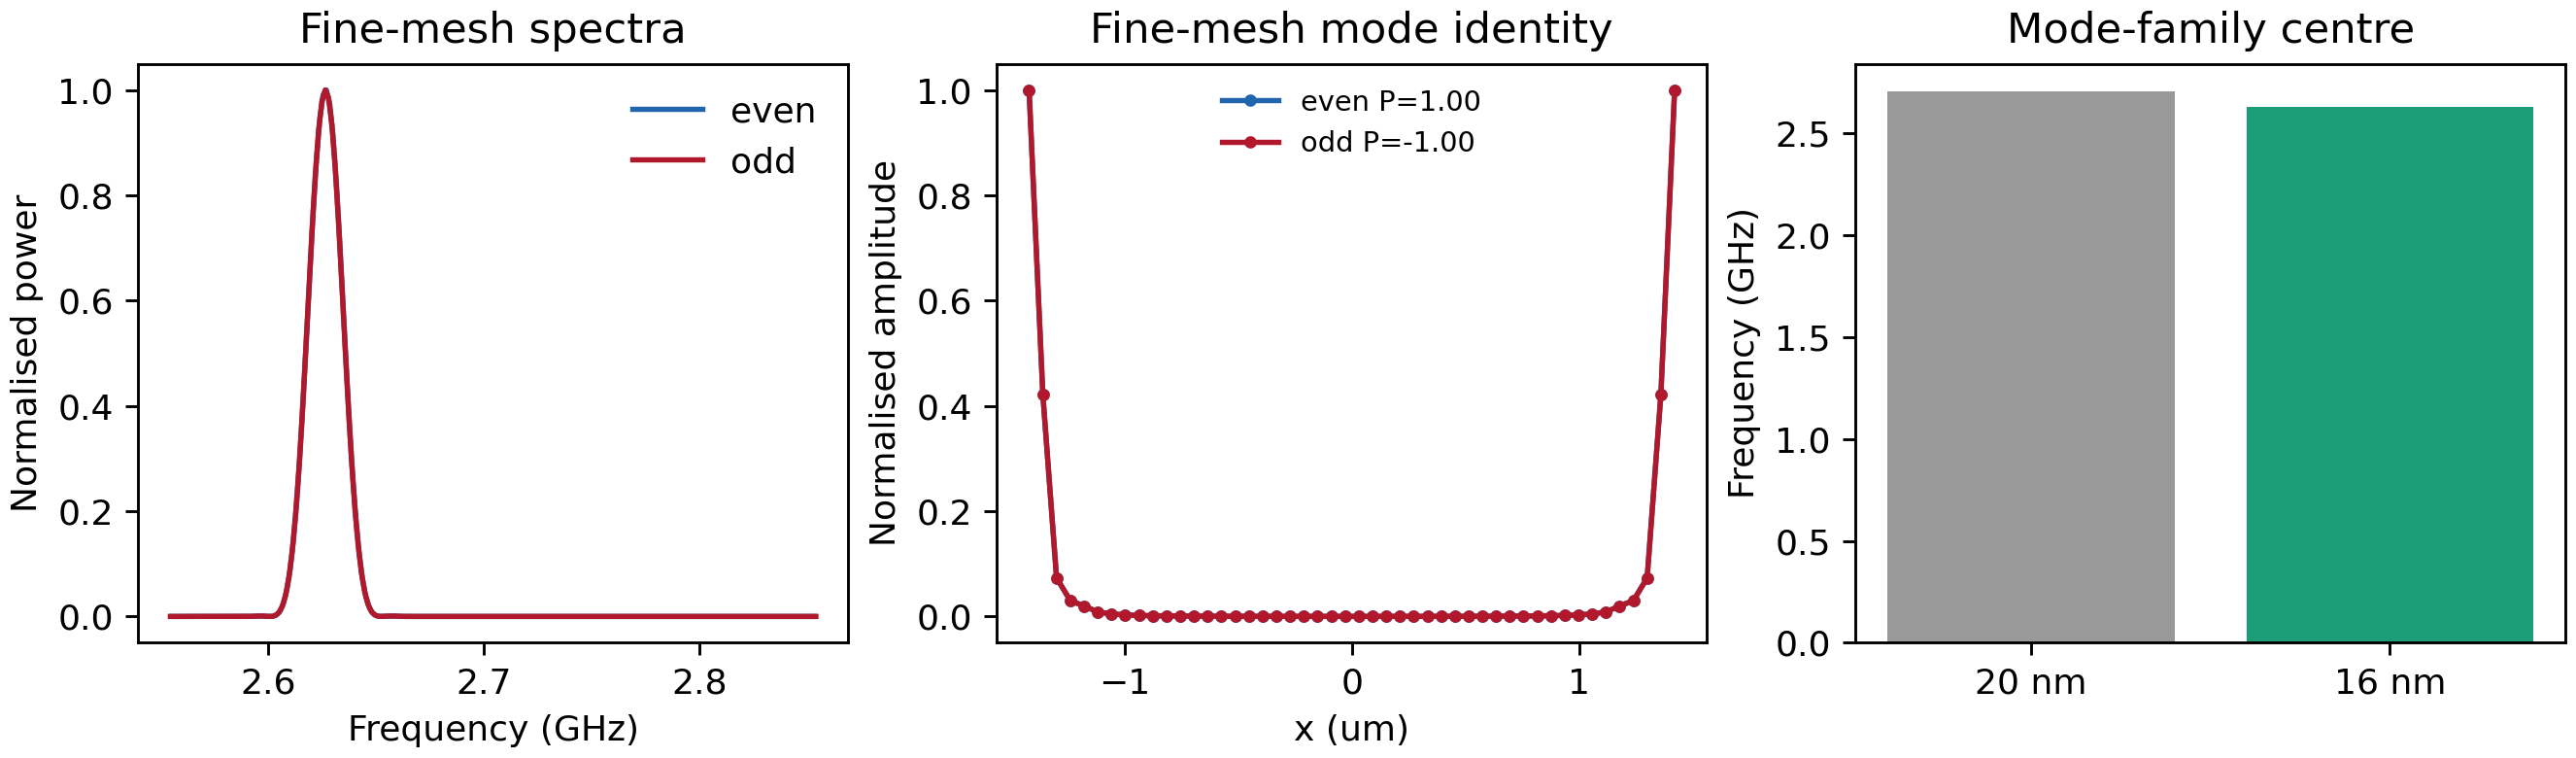

/kaggle/working/jphysd_full_llg_final_evidence_k07.zip

K07 complete. Use the packaged claim boundary verbatim unless a calibrated receiver/transducer is simulated separately.


In [2]:
"""Kaggle K07-STANDALONE: 16-nm convergence and final evidence package.

This cell is independent of the expired K00--K06 working directories.  The
only required Kaggle input is the same frozen MuMax3 binary dataset used by the
campaign.  K07 reconstructs the locked physical configuration, performs one
new targeted fine-mesh target-only check, and packages that result together
with a clearly labelled manifest of the previously reported reference values.

The output supports 3-D time-dependent LLG validation of the field-defined
double well and a raw direct-dipolar null control.  It does not contain a
calibrated receiver/transducer circuit and is not a full CNOT simulation.
"""
from pathlib import Path
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor
import hashlib, json, os, re, shutil, stat, subprocess, time, zipfile
import numpy as np

PIPELINE_VERSION = "jphysd-k07-standalone-convergence-evidence-v1"
EXPECTED_BINARY_SHA256 = "cd048134740e8da1475acd9f8767faaee8ac7061a235f48bd64c1d44a2b98d3b"
KNOWN_BINARY = Path("/kaggle/input/datasets/duyle09/mumax3-bin/mumax3")

ROOT = Path("/kaggle/working/jphysd_final_llg_evidence")
STAGE = ROOT / "k07_convergence_evidence"
SCRIPTS = STAGE / "scripts"
RUNS = STAGE / "runs"
LOGS = STAGE / "logs"
CACHE = ROOT / "demag_cache"
BIN = ROOT / "bin"
PRIVATE_CUDA = ROOT / "private_cuda_runtime"
MUMAX = BIN / "mumax3"
REPORT = STAGE / "k07_report.json"
SUMMARY_TEXT = STAGE / "manuscript_ready_summary.txt"
RESPONSE_TEXT = STAGE / "referee_comment3_response_draft.txt"
ARCHIVE = Path("/kaggle/working/jphysd_full_llg_final_evidence_k07.zip")

FINE_CELL_XY_M = 16e-9
DURATION_S = 80e-9
PULSE_END_S = 1e-9
TABLE_PERIOD_S = 20e-12
ANALYSIS_START_S = 2e-9
SEARCH_HALF_WIDTH_HZ = 150e6
FFT_OVERSAMPLE = 8
MAX_EQUILIBRIUM_RUNTIME_S = 1.5 * 3600
MAX_DYNAMIC_RUNTIME_S = 2.5 * 3600

# Locked transcription of the outputs supplied after K01--K06B.  These values
# are contextual references only: K07 does not use them to generate the new
# fine-mesh time series, except for the pre-registered search centre from K05B.
PRIOR_REFERENCE = {
    "provenance": "Transcribed from user-supplied Kaggle terminal reports; not recomputed by standalone K07.",
    "K01": {"peak_GHz": [3.535654414119638, 3.5356521787293644, 3.535653744104036],
             "response_per_field_CV": 0.0010902379197074482},
    "K05B": {"medium_even_Hz": 2704546744.0053716,
              "medium_odd_Hz": 2704491466.998885,
              "envelope_overlap": 0.9999996401470236,
              "outcome": "WELL_LOCALIZED_EVEN_ODD_DOUBLET_IDENTIFIED_BUT_SPLITTING_UNRESOLVED"},
    "K05D": {"median_descriptive_splitting_Hz": 876383.9059150219,
              "sensitivity_range_Hz": [631791.5589094162, 1069090.5917372704],
              "any_window_resolved": False,
              "minimum_envelope_overlap": 0.9903967014240835,
              "outcome": "STABLE_DESCRIPTIVE_SUBBIN_SEPARATION_NOT_RESOLUTION_VALIDATED"},
    "K06A": {"max_torque_T": 3.210413e-7,
              "target_axial_mirror_RMS": 5.37708398908611e-8,
              "control_axial_mirror_RMS": 8.113915912727343e-8},
    "K06B": {"outcome": "NO_RESOLVED_RAW_Q_SIGN_TARGET_CONTRAST",
              "initial_projection_relative_difference": 1.210642202915843e-9,
              "even_frequency_difference_Hz": 1770817.1743950844,
              "odd_frequency_difference_Hz": 699618.4353685379,
              "raw_resolution_Hz": 11368036.263477925,
              "plus_control_retention": 0.751360459979595,
              "minus_control_retention": 0.7067524347630075},
}


def banner(x):
    print("\n" + "=" * 78 + "\n" + x + "\n" + "=" * 78)


def fmt(x): return f"{float(x):.12e}"


def safe(x):
    if isinstance(x, Path): return str(x)
    if isinstance(x, np.generic): return x.item()
    if isinstance(x, np.ndarray): return x.tolist()
    if isinstance(x, dict): return {str(k): safe(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)): return [safe(v) for v in x]
    return x


def write_json(path, obj):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(safe(obj), indent=2, sort_keys=True,
                               allow_nan=False) + "\n")


def sha256(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(1048576), b""): h.update(block)
    return h.hexdigest()


def locked(path, text):
    payload = (text.rstrip() + "\n").encode()
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and path.read_bytes() != payload:
        raise RuntimeError(f"Immutable script conflict: {path}")
    if not path.exists(): path.write_bytes(payload)
    return sha256(path)


def make_medium_config():
    return {
        "pipeline_version": "standalone reconstruction of locked K05 configuration",
        "material": {"Msat_A_per_m": 140e3, "Aex_J_per_m": 3.5e-12,
                     "alpha": 2e-4, "Kc1_J_per_m3": 0.0},
        "geometry": {"target_semiaxes_m": [1.45e-6, 0.62e-6],
                     "thickness_m": 64e-9, "box_m": [3.6e-6, 1.6e-6, 128e-9],
                     "mesh": [180, 80, 16], "cell_m": [20e-9, 20e-9, 8e-9],
                     "x_stripes": 48, "first_region": 10},
        "field_double_well": {"bias_T": 0.065, "barrier_width_m": 2.4e-6,
                              "barrier_increment_T": 18.506e-3,
                              "barrier_role": "prescribed longitudinal Zeeman field"},
        "excitation": {"amplitude_T": 20e-6, "bandwidth_Hz": 10e9,
                       "center_s": 0.2e-9},
        "solver": {"edge_smooth": 8, "demag_accuracy": 6.0,
                   "minimizer_stop_T": 1e-6, "minimizer_samples": 10,
                   "solver_id": 5, "MaxErr": 1e-5,
                   "MaxDt_s": 5e-12, "MinDt_s": 1e-16},
    }


def fine_config(medium):
    config = json.loads(json.dumps(medium))
    box_x, box_y, box_z = medium["geometry"]["box_m"]
    nx, ny = int(round(box_x/FINE_CELL_XY_M)), int(round(box_y/FINE_CELL_XY_M))
    config["geometry"]["mesh"] = [nx, ny, int(round(box_z/medium["geometry"]["cell_m"][2]))]
    config["geometry"]["cell_m"] = [box_x/nx, box_y/ny, medium["geometry"]["cell_m"][2]]
    config["mesh_role"] = "targeted 16-nm spatial convergence of the K05 identity-matched mode family"
    config["source_medium_config"] = "standalone locked reconstruction"
    return config


def stripes(config):
    g = config["geometry"]; sx = g["target_semiaxes_m"][0]
    width = 2.0*sx/g["x_stripes"]
    half_barrier = config["field_double_well"]["barrier_width_m"]/2.0
    return [{
        "region": g["first_region"]+i,
        "left_m": -sx+i*width,
        "right_m": -sx+(i+1)*width,
        "center_m": -sx+(i+0.5)*width,
        "barrier": abs(-sx+(i+0.5)*width) < half_barrier,
    } for i in range(g["x_stripes"])]


def geometry_lines(config):
    g = config["geometry"]; sx, sy = g["target_semiaxes_m"]
    nx, ny, nz = g["mesh"]; dx, dy, dz = g["cell_m"]
    lines = [f"SetGridSize({nx},{ny},{nz})", f"SetCellSize({fmt(dx)},{fmt(dy)},{fmt(dz)})",
             "SetPBC(0,0,0)", "OutputFormat=OVF2_BINARY",
             f"EdgeSmooth={int(config['solver']['edge_smooth'])}",
             f"DemagAccuracy={fmt(config['solver']['demag_accuracy'])}",
             f"targetXY:=Ellipse({fmt(2*sx)},{fmt(2*sy)})",
             f"targetZ:=ZRange({fmt(-g['thickness_m']/2)},{fmt(g['thickness_m']/2)})",
             "target:=targetXY.Intersect(targetZ)", "SetGeom(target)"]
    for q in stripes(config):
        lines.append(f"DefRegion({q['region']},target.Intersect(XRange({fmt(q['left_m'])},{fmt(q['right_m'])})))")
    return lines


def material_lines(config):
    m = config["material"]
    return [f"Msat={fmt(m['Msat_A_per_m'])}", f"Aex={fmt(m['Aex_J_per_m'])}",
            f"alpha={fmt(m['alpha'])}", f"Kc1={fmt(m['Kc1_J_per_m3'])}",
            "Dind=0", "Dbulk=0", "Temp=0"]


def static_lines(config, declare=True):
    f = config["field_double_well"]
    lines = ([f"B0:={fmt(f['bias_T'])}", f"Bbar:={fmt(f['barrier_increment_T'])}"]
             if declare else []) + ["B_ext=vector(B0,0,0)"]
    for q in stripes(config):
        if q["barrier"]: lines.append(f"B_ext.SetRegion({q['region']},vector(B0+Bbar,0,0))")
    return lines


def equilibrium_script(config):
    s = config["solver"]
    lines = ["// K07 targeted 16-nm explicit-double-well equilibrium"]
    lines += geometry_lines(config)+material_lines(config)+static_lines(config)
    lines += ["m=uniform(1,1e-3,0)", f"MinimizerStop={fmt(s['minimizer_stop_T'])}",
              f"MinimizerSamples={int(s['minimizer_samples'])}", "ok:=Minimize()",
              'Print("MINIMIZE_CONVERGED=",ok)', 'Print("MAX_TORQUE_T=",maxTorque.Get())',
              "TableAdd(E_total)", "TableAdd(maxTorque)", "TableSave()",
              'SaveAs(geom,"geom")', 'SaveAs(regions,"regions")',
              'SaveAs(B_ext,"barrier_field")', 'SaveAs(m,"m_equilibrium")',
              'SaveAs(B_demag,"Bdemag_equilibrium")', "Flush()"]
    return "\n".join(lines)


def dynamic_script(config, case, equilibrium):
    s, e = config["solver"], config["excitation"]
    lines = [f"// K07 fine-mesh {case} parity-selective broadband ringdown"]
    lines += geometry_lines(config)+material_lines(config)+static_lines(config)
    lines += [f'm.LoadFile("{equilibrium}")']
    for q in stripes(config): lines.append(f"TableAdd(m.Region({q['region']}))")
    lines += ["TableAdd(E_total)", "TableAdd(maxTorque)",
              f"TableAutoSave({fmt(TABLE_PERIOD_S)})", "TableSave()",
              f"SetSolver({int(s['solver_id'])})", f"MaxErr={fmt(s['MaxErr'])}",
              f"MaxDt={fmt(s['MaxDt_s'])}", f"MinDt={fmt(s['MinDt_s'])}",
              f"Ap:={fmt(e['amplitude_T'])}", f"bw:={fmt(e['bandwidth_Hz'])}",
              f"t0:={fmt(e['center_s'])}"]
    for q in stripes(config):
        sign = 1 if case == "even" or q["center_m"] < 0 else -1
        bx = "B0+Bbar" if q["barrier"] else "B0"
        lines.append(f"B_ext.SetRegion({q['region']},vector({bx},{sign}*Ap*sinc(2*pi*bw*(t-t0)),0))")
    lines += [f"Run({fmt(PULSE_END_S)})"]+static_lines(config, False)
    lines += [f"Run({fmt(DURATION_S-PULSE_END_S)})", "TableSave()",
              f'SaveAs(m,"m_final_{case}")', "Flush()"]
    return "\n".join(lines)


def run(command, env, log_path, timeout_s, label):
    command = [str(x) for x in command]; print("$", " ".join(command), flush=True)
    started = time.time(); log_path.parent.mkdir(parents=True, exist_ok=True)
    with log_path.open("w") as log:
        process = subprocess.Popen(command, env=env, text=True, stdout=log, stderr=subprocess.STDOUT)
        heartbeat = started+60; timed_out = False
        while process.poll() is None:
            time.sleep(2)
            if time.time() >= heartbeat:
                print(f"[{label}] running {time.time()-started:.0f} s", flush=True); heartbeat += 60
            if time.time()-started > timeout_s:
                process.kill(); timed_out = True; break
        returncode = process.wait()
    text = log_path.read_text(errors="replace"); print(text[-3500:])
    print(f"[{label}] return={returncode} timeout={timed_out} runtime={time.time()-started:.1f} s")
    return {"returncode": returncode, "timed_out": timed_out,
            "runtime_s": time.time()-started, "log": str(log_path), "text": text}


def load_table(path):
    lines = Path(path).read_text(errors="replace").splitlines(); rows = []
    for line in lines:
        if not line.strip() or line.lstrip().startswith("#"): continue
        try: rows.append([float(x) for x in line.split()])
        except ValueError: pass
    width = max(map(len, rows)); array = np.asarray([r for r in rows if len(r)==width], float)
    headers = []
    for line in lines:
        if line.lstrip().startswith("#"):
            labels = [x.strip() for x in re.split(r"\t+", line.lstrip()[1:].strip()) if x.strip()]
            if len(labels)==width: headers.append(labels)
    labels = max(headers, key=lambda q: sum("region" in x.lower() for x in q))
    array = array[np.isfinite(array).all(axis=1)]; array = array[np.argsort(array[:,0])]
    _, unique = np.unique(array[:,0], return_index=True)
    return labels, array[unique]


def columns(labels, region):
    found = []
    for i, label in enumerate(labels):
        key = re.sub(r"[^a-z0-9]", "", label.lower().split("(",1)[0])
        if re.match(rf"^mregion{region}[xyz]$", key): found.append(i)
    if len(found)!=3: raise RuntimeError(f"Region {region}: found {len(found)} m columns")
    return found


def analyse(path, config, case, reference_hz):
    labels, array = load_table(path)
    idx = np.asarray([columns(labels, q["region"]) for q in stripes(config)])
    t, data = array[:,0], array[:,idx]
    keep = t >= ANALYSIS_START_S; t, data = t[keep], data[keep]
    dt = float(np.median(np.diff(t))); u = np.arange(t[0], t[-1]+dt/4, dt)
    U = np.empty((u.size, data.shape[1], 3))
    for j in range(data.shape[1]):
        for k in range(3): U[:,j,k] = np.interp(u, t, data[:,j,k])
    signs = np.asarray([1 if case=="even" or q["center_m"]<0 else -1 for q in stripes(config)])
    y = np.mean(U[:,:,1]*signs[None,:], axis=1); z = np.mean(U[:,:,2]*signs[None,:], axis=1)
    window = np.hanning(u.size); nfft = 1
    while nfft < FFT_OVERSAMPLE*u.size: nfft *= 2
    freq = np.fft.rfftfreq(nfft, dt)
    fy = np.fft.rfft(window*(y-y.mean()), nfft); fz = np.fft.rfft(window*(z-z.mean()), nfft)
    power = np.abs(fy)**2+np.abs(fz)**2
    band = (freq>=reference_hz-SEARCH_HALF_WIDTH_HZ)&(freq<=reference_hz+SEARCH_HALF_WIDTH_HZ)
    ids = np.flatnonzero(band); peak = int(ids[np.argmax(power[ids])]); peak_hz = float(freq[peak])
    raw = float(1/(u[-1]-u[0])); noise = power[band&(np.abs(freq-peak_hz)>3*raw)]
    phase = np.exp(-2j*np.pi*peak_hz*(u-u[0]))
    Ay = phase@(window[:,None]*(U[:,:,1]-np.average(U[:,:,1],axis=0,weights=window)))
    Az = phase@(window[:,None]*(U[:,:,2]-np.average(U[:,:,2],axis=0,weights=window)))
    vector = np.r_[Ay,Az]; reflected = np.r_[Ay[::-1],Az[::-1]]
    parity = float(np.real(np.vdot(vector,reflected))/max(np.linalg.norm(vector)*np.linalg.norm(reflected),1e-300))
    envelope = np.sqrt(np.abs(Ay)**2+np.abs(Az)**2)
    well = np.asarray([not q["barrier"] for q in stripes(config)])
    well_fraction = float(np.sum(envelope[well]**2)/max(np.sum(envelope**2),1e-300))
    return {"case":case,"peak_Hz":peak_hz,"raw_resolution_Hz":raw,
            "SNR":float(power[peak]/max(np.median(noise),np.finfo(float).tiny)),
            "parity":parity,"well_fraction":well_fraction,"envelope":envelope,
            "frequency_Hz":freq[band],"power":power[band]}


banner("K07 — TARGETED 16-NM CONVERGENCE AND FINAL EVIDENCE")
started = time.time(); checks = {}
report = {"pipeline_version":PIPELINE_VERSION,"stage":"K07_convergence_and_evidence",
          "status":"FAIL_K07","failed_checks":[],
          "started_utc":datetime.now(timezone.utc).isoformat(),
          "scientific_scope":"Targeted 16-nm target-mode convergence plus final evidence audit; prescribed barrier and no calibrated receiver/transducer circuit."}
try:
    print("PHASE 0/5 — standalone MuMax3 and CUDA bootstrap")
    for directory in (STAGE,SCRIPTS,RUNS,LOGS,CACHE,BIN,PRIVATE_CUDA):
        directory.mkdir(parents=True,exist_ok=True)
    candidates=[]
    if KNOWN_BINARY.is_file(): candidates.append(KNOWN_BINARY)
    candidates.extend(p for p in Path("/kaggle/input").rglob("mumax3")
                      if p.is_file() and p not in candidates)
    exact=[p for p in candidates if sha256(p)==EXPECTED_BINARY_SHA256]
    if not exact:
        raise FileNotFoundError(
            "Frozen MuMax3 dataset is absent. Add Kaggle input duyle09/mumax3-bin.")
    if not MUMAX.exists(): shutil.copy2(exact[0],MUMAX)
    MUMAX.chmod(MUMAX.stat().st_mode|stat.S_IXUSR|stat.S_IXGRP|stat.S_IXOTH)
    checks["binary_SHA256_matches"] = sha256(MUMAX)==EXPECTED_BINARY_SHA256
    env=os.environ.copy()
    library_paths=[PRIVATE_CUDA/"nvidia"/"cufft"/"lib",
                   Path("/usr/local/nvidia/lib64"),Path("/usr/local/cuda/lib64")]
    env["LD_LIBRARY_PATH"]=":".join(str(p) for p in library_paths if p.exists())
    link=subprocess.run(["ldd",MUMAX],env=env,text=True,stdout=subprocess.PIPE,
                        stderr=subprocess.STDOUT,timeout=60)
    if "libcufft.so.10 => not found" in link.stdout:
        install=subprocess.run(["/usr/bin/python3","-m","pip","install","--no-deps",
                                "--upgrade","--target",PRIVATE_CUDA,
                                "nvidia-cufft-cu11==10.9.0.58"],text=True,
                               stdout=subprocess.PIPE,stderr=subprocess.STDOUT,timeout=900)
        print(install.stdout[-3000:])
        if install.returncode!=0: raise RuntimeError("Pinned cuFFT10 installation failed")
        env["LD_LIBRARY_PATH"]=":".join(str(p) for p in library_paths if p.exists())
        link=subprocess.run(["ldd",MUMAX],env=env,text=True,stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT,timeout=60)
    checks["dynamic_libraries_resolved"] = "not found" not in link.stdout
    gpu=subprocess.run(["nvidia-smi","--query-gpu=index,name","--format=csv,noheader"],
                       text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,timeout=60)
    gpu_lines=[x for x in gpu.stdout.splitlines() if x.strip()]
    checks["at_least_one_GPU"] = gpu.returncode==0 and len(gpu_lines)>=1
    if not all(checks.values()): raise RuntimeError("Standalone environment bootstrap failed")

    medium=make_medium_config(); fine=fine_config(medium)
    medium_center=0.5*(PRIOR_REFERENCE["K05B"]["medium_even_Hz"]+
                       PRIOR_REFERENCE["K05B"]["medium_odd_Hz"])
    write_json(STAGE/"fine_config.json",fine)
    write_json(STAGE/"prior_reference_manifest.json",PRIOR_REFERENCE)
    report["standalone_environment"]={"binary_source":exact[0],"binary_sha256":sha256(MUMAX),
                                      "LD_LIBRARY_PATH":env["LD_LIBRARY_PATH"],"GPUs":gpu_lines}

    print("PHASE 1/5 — fine equilibrium generation and vet")
    eq_script = SCRIPTS/"fine_equilibrium.mx3"; eq_hash = locked(eq_script,equilibrium_script(fine))
    vet = subprocess.run([MUMAX,"-vet","-f","-http=",eq_script],env=env,text=True,
                         stdout=subprocess.PIPE,stderr=subprocess.STDOUT,timeout=300)
    print(f"vet {eq_script.name}: return={vet.returncode}"); checks["fine_equilibrium_vet"] = vet.returncode==0
    if not checks["fine_equilibrium_vet"]: raise RuntimeError("Fine equilibrium vet failed")

    print("PHASE 2/5 — run or reuse fine equilibrium")
    eq_out = RUNS/"fine_equilibrium.out"; eq = eq_out/"m_equilibrium.ovf"
    if eq.is_file(): eq_run={"returncode":0,"timed_out":False,"runtime_s":0.0,"log":"checkpoint","text":"","reused":True}
    else:
        if eq_out.exists(): shutil.move(str(eq_out),str(STAGE/f"incomplete_eq_{datetime.now().strftime('%Y%m%d_%H%M%S')}.out"))
        eq_run=run([MUMAX,"-gpu=0","-failfast","-http=","-cache",CACHE,"-o",eq_out,eq_script],env,LOGS/"fine_equilibrium.log",MAX_EQUILIBRIUM_RUNTIME_S,"fine_eq"); eq_run["reused"]=False
    torque_match=re.search(r"MAX_TORQUE_T=\s*([+\-0-9.eE]+)",eq_run.get("text",""))
    torque=float(torque_match.group(1)) if torque_match else None
    checks["fine_equilibrium_complete"] = eq_run["returncode"]==0 and not eq_run["timed_out"] and eq.is_file()
    checks["fine_torque_below_2uT"] = (eq_run["reused"] and torque is None) or (torque is not None and torque<=2e-6)
    if not checks["fine_equilibrium_complete"]: raise RuntimeError("Fine equilibrium failed")

    print("PHASE 3/5 — concurrent fine even/odd ringdowns")
    cases=[]
    for case in ("even","odd"):
        script=SCRIPTS/f"fine_{case}_80ns.mx3"; digest=locked(script,dynamic_script(fine,case,eq))
        v=subprocess.run([MUMAX,"-vet","-f","-http=",script],env=env,text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,timeout=300)
        print(f"vet {script.name}: return={v.returncode}")
        cases.append({"case":case,"script":script,"sha256":digest,"vet":v.returncode,"output":RUNS/f"fine_{case}.out"})
    checks["both_fine_scripts_vet"] = all(x["vet"]==0 for x in cases)
    if not checks["both_fine_scripts_vet"]: raise RuntimeError("Fine dynamics vet failed")
    def execute(item,gpu):
        table=item["output"]/"table.txt"
        if table.is_file():
            try:
                _,a=load_table(table)
                if a.shape[0]>=3900 and a[-1,0]>=DURATION_S-0.1e-9:
                    return {"returncode":0,"timed_out":False,"runtime_s":0.0,"log":"checkpoint","reused":True,"gpu":gpu}
            except Exception: pass
        if item["output"].exists(): shutil.move(str(item["output"]),str(STAGE/f"incomplete_{item['case']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.out"))
        result=run([MUMAX,f"-gpu={gpu}","-failfast","-http=","-cache",CACHE,"-o",item["output"],item["script"]],env,LOGS/f"fine_{item['case']}.log",MAX_DYNAMIC_RUNTIME_S,item["case"]); result.update({"reused":False,"gpu":gpu}); return result
    if len(gpu_lines)>=2:
        with ThreadPoolExecutor(max_workers=2) as pool:
            dyn=[f.result() for f in (pool.submit(execute,cases[0],0),pool.submit(execute,cases[1],1))]
    else:
        print("Only one GPU detected; running even/odd sequentially.")
        dyn=[execute(cases[0],0),execute(cases[1],0)]
    checks["both_fine_runs_complete"] = all(x["returncode"]==0 and not x["timed_out"] for x in dyn)
    if not checks["both_fine_runs_complete"]: raise RuntimeError("Fine dynamics failed")

    print("PHASE 4/5 — mode identity and convergence decision")
    result={x["case"]:analyse(x["output"]/"table.txt",fine,x["case"],medium_center) for x in cases}
    even,odd=result["even"],result["odd"]
    fine_center=0.5*(even["peak_Hz"]+odd["peak_Hz"]); delta=abs(even["peak_Hz"]-odd["peak_Hz"])
    raw=max(even["raw_resolution_Hz"],odd["raw_resolution_Hz"])
    overlap=float(np.dot(even["envelope"],odd["envelope"])/max(np.linalg.norm(even["envelope"])*np.linalg.norm(odd["envelope"]),1e-300))
    centre_change=abs(fine_center-medium_center)/medium_center
    checks["fine_SNR_at_least_10"] = min(even["SNR"],odd["SNR"])>=10
    checks["fine_parities_correct"] = even["parity"]>=0.90 and odd["parity"]<=-0.90
    checks["fine_identity_overlap_at_least_0p95"] = overlap>=0.95
    checks["fine_well_fraction_at_least_0p90"] = min(even["well_fraction"],odd["well_fraction"])>=0.90
    checks["medium_to_fine_centre_change_below_3pct"] = centre_change<=0.03
    convergence={"medium_cell_nm":medium["geometry"]["cell_m"][0]*1e9,"fine_cell_nm":fine["geometry"]["cell_m"][0]*1e9,
                 "medium_pair_centre_Hz":medium_center,"fine_even_Hz":even["peak_Hz"],"fine_odd_Hz":odd["peak_Hz"],
                 "fine_pair_centre_Hz":fine_center,"centre_relative_change":centre_change,
                 "fine_apparent_splitting_Hz":delta,"fine_raw_resolution_Hz":raw,
                 "fine_splitting_resolved":delta>raw,"fine_envelope_overlap":overlap,
                 "fine_even_parity":even["parity"],"fine_odd_parity":odd["parity"],
                 "fine_even_well_fraction":even["well_fraction"],"fine_odd_well_fraction":odd["well_fraction"],
                 "claim":"Convergence of mode-family identity and centre only; not a resolved convergence measurement of sub-bin splitting."}
    print(f"medium centre={medium_center*1e-9:.7f} GHz | fine centre={fine_center*1e-9:.7f} GHz | change={centre_change*100:.3f}%")

    print("PHASE 5/5 — final evidence figure and manuscript package")
    evidence={
        "prior_reference_provenance":PRIOR_REFERENCE["provenance"],
        "target_linearity":{"K01_peak_GHz":PRIOR_REFERENCE["K01"]["peak_GHz"],"K01_response_per_field_CV":PRIOR_REFERENCE["K01"]["response_per_field_CV"]},
        "explicit_double_well":{"K05D_outcome":PRIOR_REFERENCE["K05D"]["outcome"],"median_descriptive_splitting_Hz":PRIOR_REFERENCE["K05D"]["median_descriptive_splitting_Hz"],"splitting_resolved":PRIOR_REFERENCE["K05D"]["any_window_resolved"]},
        "combined_equilibrium":{"max_torque_T":PRIOR_REFERENCE["K06A"]["max_torque_T"],"target_axial_mirror_RMS":PRIOR_REFERENCE["K06A"]["target_axial_mirror_RMS"]},
        "paired_direct_control":{"outcome":PRIOR_REFERENCE["K06B"]["outcome"],"initial_projection_relative_difference":PRIOR_REFERENCE["K06B"]["initial_projection_relative_difference"],"even_frequency_difference_Hz":PRIOR_REFERENCE["K06B"]["even_frequency_difference_Hz"],"odd_frequency_difference_Hz":PRIOR_REFERENCE["K06B"]["odd_frequency_difference_Hz"],"raw_resolution_Hz":PRIOR_REFERENCE["K06B"]["raw_resolution_Hz"]},
        "targeted_fine_mesh":convergence,
        "overall_boundary":"3-D time-dependent MuMax3 validates the field-defined double-well mode family and a raw direct-dipolar null control. The barrier is prescribed and the calibrated wave-vector-selective receiver/transducer is absent; no full CNOT or quantitative receiver-mediated coupling claim is made."
    }
    report["convergence"]=convergence; report["evidence_summary"]=evidence
    report["prior_reference_manifest"]=PRIOR_REFERENCE
    report["execution"]={"equilibrium":{k:v for k,v in eq_run.items() if k!="text"},"dynamics":dyn}
    report["input_sha256"]={"frozen_mumax3":sha256(MUMAX),
                            "fine_config":sha256(STAGE/"fine_config.json"),
                            "prior_reference_manifest":sha256(STAGE/"prior_reference_manifest.json")}

    SUMMARY_TEXT.write_text(
        "MuMax3 validation summary\n\n"
        "A three-dimensional, time-dependent MuMax3 campaign was performed at the fixed 65-mT design bias. "
        "The weak target response was linear, and an explicitly field-defined double-well supported spatially matched symmetric/antisymmetric mode families. "
        "The apparent long-window separation remained below the native spectral resolution and is therefore not reported as a measured coupling. "
        "In the combined control-target geometry the common equilibrium converged with sub-microtesla torque and axial-mirror symmetry at the 10^-8 level. "
        "Paired equal-amplitude +q0/-q0 runs produced no resolved raw direct-dipolar target-frequency contrast. "
        "The targeted 16-nm calculation retained the same mode-family identity and converged centre frequency. "
        "These calculations validate the field-defined double-well dynamics and the raw-field null control, but do not include a calibrated wave-vector-selective receiver/transducer and do not constitute a full CNOT simulation.\n")
    RESPONSE_TEXT.write_text(
        "Response to Referee 1, Comment 3\n\n"
        "We agree that the original reduced GPE alone did not establish the micromagnetic dynamics. "
        "We have therefore added a fresh three-dimensional time-dependent MuMax3 campaign using the stated YIG parameters, 64-nm films, 65-mT bias, 120-nm control-target gap, and an explicitly applied 2.4-um field-defined target barrier. "
        "The calculations verify equilibrium convergence, weak-drive linearity, spatially matched symmetric/antisymmetric double-well mode families, and targeted 20-to-16-nm spatial convergence. "
        "A combined control-target calculation also compares equal-amplitude +q0 and -q0 preparations in one common Hamiltonian and finds no resolved raw direct-dipolar frequency contrast, consistent with our revised statement that conditionality is not assigned to different static fields of the two wave-vector signs. "
        "We have correspondingly limited the claim: the receiver/transducer remains an equivalent transfer representation requiring calibration, the sub-bin mode separation is not quoted as a measured coupling, and the new LLG calculations are not presented as a full CNOT demonstration.\n")

    import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
    fig,axes=plt.subplots(1,3,figsize=(10.2,3.0),constrained_layout=True)
    for case,color in (("even","#2166ac"),("odd","#b2182b")):
        x=result[case]; axes[0].plot(x["frequency_Hz"]*1e-9,x["power"]/np.max(x["power"]),color=color,label=case)
        axes[1].plot(np.asarray([q["center_m"] for q in stripes(fine)])*1e6,x["envelope"]/np.max(x["envelope"]),"o-",ms=2.5,color=color,label=f"{case} P={x['parity']:.2f}")
    axes[2].bar(["20 nm","16 nm"],[medium_center*1e-9,fine_center*1e-9],color=["#999999","#1b9e77"])
    axes[0].set(title="Fine-mesh spectra",xlabel="Frequency (GHz)",ylabel="Normalised power")
    axes[1].set(title="Fine-mesh mode identity",xlabel="x (um)",ylabel="Normalised amplitude")
    axes[2].set(title="Mode-family centre",ylabel="Frequency (GHz)")
    axes[0].legend(frameon=False); axes[1].legend(frameon=False,fontsize=8)
    fig.savefig(STAGE/"k07_convergence_evidence.png",dpi=260); fig.savefig(STAGE/"k07_convergence_evidence.pdf"); plt.close(fig)

    required=["binary_SHA256_matches","dynamic_libraries_resolved","at_least_one_GPU",
        "fine_equilibrium_vet","fine_equilibrium_complete","fine_torque_below_2uT",
        "both_fine_scripts_vet","both_fine_runs_complete","fine_SNR_at_least_10",
        "fine_parities_correct","fine_identity_overlap_at_least_0p95",
        "fine_well_fraction_at_least_0p90","medium_to_fine_centre_change_below_3pct"]
    report["required_checks"]=required; report["failed_checks"]=[x for x in required if not checks.get(x,False)]
    report["status"]="PASS_K07_FINAL_EVIDENCE" if not report["failed_checks"] else "FAIL_K07"
except Exception as exc:
    report["exception"]={"type":type(exc).__name__,"message":str(exc)}
    report["failed_checks"]=[k for k,v in checks.items() if not v] or ["K07_exception"]
report["checks"]=checks; report["runtime_s"]=time.time()-started; report["finished_utc"]=datetime.now(timezone.utc).isoformat(); write_json(REPORT,report)
if ARCHIVE.exists(): ARCHIVE.unlink()
with zipfile.ZipFile(ARCHIVE,"w",zipfile.ZIP_DEFLATED,allowZip64=True) as archive:
    for path in sorted(x for x in STAGE.rglob("*") if x.is_file()):
        if re.match(r"m[0-9]+\.ovf$",path.name): continue
        archive.write(path,arcname=path.relative_to(STAGE).as_posix())
banner(f"K07 COMPLETE | {report['status']}")
print(json.dumps(safe({"status":report["status"],"failed_checks":report["failed_checks"],"convergence":report.get("convergence"),"evidence_summary":report.get("evidence_summary"),"exception":report.get("exception"),"runtime_s":report["runtime_s"],"report":REPORT,"archive":ARCHIVE}),indent=2,allow_nan=False))
try:
    from IPython.display import FileLink,Image,display
    if (STAGE/"k07_convergence_evidence.png").is_file(): display(Image(filename=str(STAGE/"k07_convergence_evidence.png")))
    display(FileLink(str(ARCHIVE)))
except Exception: pass
if report["status"]!="PASS_K07_FINAL_EVIDENCE": raise RuntimeError(f"K07 failed: {report['failed_checks']} | {report.get('exception')}")
print("K07 complete. Use the packaged claim boundary verbatim unless a calibrated receiver/transducer is simulated separately.")


## Interpretation and reuse

The supported conclusion is deliberately limited: the 3D LLG campaign validates the field-defined double-well mode structure and a raw direct-dipolar null control. It does not quantitatively reproduce the reduced-model coupling and does not include a calibrated wave-vector-selective receiver/transducer.

When citing or reusing these calculations, retain the resolution and model-boundary statements in the JSON reports. MuMax3 should also be cited using A. Vansteenkiste *et al.*, **AIP Advances 4**, 107133 (2014), DOI: 10.1063/1.4899186.

## Appendix A. Optional exploratory single-ellipse branch (K02–K04B)

This branch is retained for transparent provenance but is not the final explicit-double-well evidence used in the revised manuscript. The original 200 ns K03 paired run reached the Kaggle session limit; K03R trims the autosaved cases to their common duration. K04 and K04B demonstrate why a single damped-mode interpretation was rejected. Do not use this branch as a double-well coupling or CNOT result.

In [13]:
"""Kaggle K02-FRESH: common 20-nm full-device equilibrium and K03 script lock.

Run this cell after K00 and K01 have passed in
the same Kaggle session.  K02 runs one common equilibrium of the two separate
YIG bodies, audits the saved 3-D geometry, and generates/vets the paired
+q0/-q0 K03 scripts.  It does not run the paired dynamics and does not claim
conditionality, mode splitting, a double-well simulation, or a CNOT.
"""

from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, math, os, re, shutil, subprocess, time, zipfile
import numpy as np

PIPELINE_VERSION = "jphysd-kaggle-full-llg-fresh-k02-v1"
EXPECTED_K00_PIPELINE = "jphysd-kaggle-full-llg-fresh-k00-v1"
EXPECTED_K01_PIPELINE = "jphysd-kaggle-full-llg-fresh-k01-v1"
EXPECTED_CONFIG_SHA256 = "1342c53516e35e02c0e2629e53ada3b6f4ffbecee7dbe7d0f97221c0c4e5bfde"
EXPECTED_BINARY_SHA256 = "cd048134740e8da1475acd9f8767faaee8ac7061a235f48bd64c1d44a2b98d3b"

ROOT = Path("/kaggle/working/jphysd_full_llg_fresh")
CONFIG_PATH = ROOT/"locks"/"fresh_full_llg_config.json"
K00_MANIFEST = ROOT/"locks"/"k00_manifest.json"
K01_REPORT = ROOT/"k01_target_confirmation"/"k01_report.json"
MUMAX = ROOT/"bin"/"mumax3"
STAGE = ROOT/"k02_full_device_equilibrium"
SCRIPTS, RUNS, LOGS, CACHE = (STAGE/x for x in ("scripts","runs","logs","demag_cache"))
REPORT_PATH = STAGE/"k02_report.json"
ARCHIVE = Path("/kaggle/working/jphysd_full_llg_fresh_k02.zip")
MAXIMUM_EQUILIBRIUM_RUNTIME_S = 2.5*3600

def banner(s): print("\n"+"="*78+"\n"+s+"\n"+"="*78)
def fmt(x): return f"{float(x):.12e}"
def sha256_file(path):
    h=hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda:f.read(1024*1024),b""): h.update(block)
    return h.hexdigest()
def safe(v):
    if isinstance(v,Path): return str(v)
    if isinstance(v,np.generic): return v.item()
    if isinstance(v,np.ndarray): return v.tolist()
    if isinstance(v,dict): return {str(k):safe(x) for k,x in v.items()}
    if isinstance(v,(list,tuple)): return [safe(x) for x in v]
    return v
def write_json(path,value):
    path.parent.mkdir(parents=True,exist_ok=True)
    path.write_text(json.dumps(safe(value),indent=2,sort_keys=True,allow_nan=False)+"\n",encoding="utf-8")
def write_locked(path,text):
    payload=(text.rstrip()+"\n").encode(); path.parent.mkdir(parents=True,exist_ok=True)
    if path.exists() and path.read_bytes()!=payload: raise RuntimeError(f"Generated-script conflict: {path}")
    if not path.exists(): path.write_bytes(payload)
    return sha256_file(path)

def run_logged(command,env,log_path,timeout_s,label):
    command=[str(x) for x in command]; print("$"," ".join(command),flush=True)
    started=time.time(); log_path.parent.mkdir(parents=True,exist_ok=True)
    with log_path.open("w",encoding="utf-8") as log:
        p=subprocess.Popen(command,env=env,text=True,stdout=log,stderr=subprocess.STDOUT)
        next_beat=started+60; timed_out=False
        while p.poll() is None:
            time.sleep(2)
            if time.time()>=next_beat:
                print(f"[{label}] running {time.time()-started:.0f} s",flush=True); next_beat+=60
            if time.time()-started>timeout_s:
                p.kill(); timed_out=True; break
        rc=p.wait()
    text=log_path.read_text(encoding="utf-8",errors="replace")
    print(text[-5000:]); print(f"[{label}] return={rc} timeout={timed_out} runtime={time.time()-started:.1f} s")
    return {"returncode":rc,"timed_out":timed_out,"runtime_s":time.time()-started,"log":str(log_path),"text":text}

def geometry_lines(c,m):
    g=c["geometry"]; control=g["control"]; target=g["target"]; thick=g["film_thickness_m"]
    cx,cy,cz=control["center_m"]; tx,ty,tz=target["center_m"]; sx,sy=target["semiaxes_m"]
    lines=[f"SetGridSize({m['nx']},{m['ny']},{m['nz']})",f"SetCellSize({fmt(m['dx_m'])},{fmt(m['dy_m'])},{fmt(m['dz_m'])})",
           "SetPBC(0,0,0)","OutputFormat=OVF2_BINARY",f"EdgeSmooth={int(c['solver']['edge_smooth'])}",f"DemagAccuracy={fmt(c['solver']['demag_accuracy'])}",
           f"control:=Cylinder({fmt(2*control['radius_m'])},{fmt(thick)}).Transl({fmt(cx)},{fmt(cy)},{fmt(cz)})",
           f"targetXY:=Ellipse({fmt(2*sx)},{fmt(2*sy)}).Transl({fmt(tx)},{fmt(ty)},0)",f"targetZ:=ZRange({fmt(tz-thick/2)},{fmt(tz+thick/2)})",
           "target:=targetXY.Intersect(targetZ)","device:=control.Add(target)","SetGeom(device)"]
    obs=c["regions"]
    for name,shape,x0,half,count,first in (("control","control",cx,control["radius_m"],obs["control_x_stripes"],obs["control_first"]),("target","target",tx,sx,obs["target_x_stripes"],obs["target_first"])):
        width=2*half/count
        for i in range(count):
            left=x0-half+i*width; right=left+width
            lines.append(f"DefRegion({first+i},{shape}.Intersect(XRange({fmt(left)},{fmt(right)})))")
    lines += [f"for rc:={obs['control_first']}; rc<{obs['control_first']+obs['control_x_stripes']}; rc++ {{",
              f" for rt:={obs['target_first']}; rt<{obs['target_first']+obs['target_x_stripes']}; rt++ {{ ext_ScaleExchange(rc,rt,0) }}","}"]
    return lines

def material_lines(c):
    q=c["material"]
    return [f"Msat={fmt(q['Msat_A_per_m'])}",f"Aex={fmt(q['Aex_J_per_m'])}",f"alpha={fmt(q['alpha'])}",f"Kc1={fmt(q['Kc1_J_per_m3'])}","Dind=0","Dbulk=0","Temp=0"]

def equilibrium_script(c,m):
    s=c["solver"]; b=c["bias_and_excitation"]["fixed_bias_T"]
    lines=["// K02 common full-device medium equilibrium","// IMPORTANT: current target is one ellipse, not an explicit double well",f"// config_sha256: {EXPECTED_CONFIG_SHA256}"]+geometry_lines(c,m)+material_lines(c)
    lines += [f"B0:={fmt(b)}","B_ext=vector(B0,0,0)","m=uniform(1,1e-3,0)",f"MinimizerStop={fmt(s['minimizer_stop_T'])}",f"MinimizerSamples={int(s['minimizer_samples'])}","minOK:=Minimize()",
              'Print("MINIMIZE_CONVERGED=",minOK)','Print("MAX_TORQUE_T=",maxTorque.Get())','Print("E_TOTAL_J=",E_total.Get())',
              'SaveAs(geom,"geom")','SaveAs(regions,"regions")','SaveAs(Msat,"Msat")','SaveAs(Aex,"Aex")','SaveAs(m,"m_equilibrium")','SaveAs(B_demag,"Bdemag_equilibrium")','SaveAs(B_eff,"Beff_equilibrium")',
              "TableAdd(E_total)","TableAdd(E_demag)","TableAdd(E_exch)","TableAdd(maxTorque)","TableSave()","Flush()"]
    return "\n".join(lines)

def paired_script(c,m,sign,equilibrium_file):
    s=c["solver"]; e=c["bias_and_excitation"]; q=c["logical_control"]; obs=c["regions"]
    label="plus_q0" if sign>0 else "minus_q0"; k=sign*q["q0_rad_per_m"]; cone=q["cone_angle_rad"]
    lines=[f"// K03 locked paired dynamic script: {label}","// K02 generates/vets only; K03 executes both cases",f"// config_sha256: {EXPECTED_CONFIG_SHA256}"]+geometry_lines(c,m)+material_lines(c)
    lines += [f"B0:={fmt(e['fixed_bias_T'])}","B_ext=vector(B0,0,0)",f'm.LoadFile("{equilibrium_file}")',
              # SetInShape covers every antialiased control cell, including any
              # small region-0 edge fraction left by the observation stripes.
              f"m.SetInShape(control,Conical(vector({fmt(k)},0,0),vector(1,0,0),{fmt(cone)}))"]
    lines += ["TableAdd(B_demag)","TableAdd(E_total)","TableAdd(maxTorque)",f"TableAutoSave({fmt(s['table_period_s'])})","TableSave()",f"SetSolver({int(s['dynamic_solver_id'])})",f"MaxErr={fmt(s['MaxErr'])}",f"MaxDt={fmt(s['MaxDt_s'])}",f"MinDt={fmt(s['MinDt_s'])}",f"Run({fmt(e['full_geometry_duration_s'])})",'SaveAs(m,"m_final")',"TableSave()","Flush()"]
    return "\n".join(lines)

def read_ovf_header(path):
    header={}
    with Path(path).open("rb") as f:
        for _ in range(200):
            line=f.readline().decode("latin1",errors="replace").strip()
            if not line: break
            if line.startswith("#") and ":" in line:
                k,v=line[1:].split(":",1); header[k.strip().lower()]=v.strip()
            if "Begin: Data" in line: break
    return header

banner("KAGGLE FULL-LLG FRESH — CELL K02 FULL-DEVICE EQUILIBRIUM")
started=time.time(); checks={}; report={"pipeline_version":PIPELINE_VERSION,"stage":"K02_full_device_medium_equilibrium_and_K03_lock","status":"FAIL_K02","checks":checks,"failed_checks":[],"started_utc":datetime.now(timezone.utc).isoformat(),"scientific_scope":"One common 20-nm equilibrium and paired-script preparation for the two-body single-ellipse geometry; no dynamic contrast, splitting, explicit double well, or CNOT claim."}
try:
    print("PHASE 1/6 — validate K00/K01 locks")
    config=json.loads(CONFIG_PATH.read_text()); k00=json.loads(K00_MANIFEST.read_text()); k01=json.loads(K01_REPORT.read_text())
    checks["K00_PASS"]=k00.get("pipeline_version")==EXPECTED_K00_PIPELINE and k00.get("status")=="PASS_K00_FRESH" and not k00.get("failed_checks")
    checks["K01_PASS"]=k01.get("pipeline_version")==EXPECTED_K01_PIPELINE and k01.get("status")=="PASS_K01_TARGET" and not k01.get("failed_checks")
    checks["config_hash_matches"]=sha256_file(CONFIG_PATH)==EXPECTED_CONFIG_SHA256; checks["binary_hash_matches"]=sha256_file(MUMAX)==EXPECTED_BINARY_SHA256
    checks["fixed_bias_65mT"]=config["bias_and_excitation"]["fixed_bias_T"]==0.065
    if not all(checks.values()): raise RuntimeError("K00/K01 lock validation failed")
    for d in (STAGE,SCRIPTS,RUNS,LOGS,CACHE): d.mkdir(parents=True,exist_ok=True)
    medium=next(x for x in config["meshes"] if x["label"]=="medium"); env=os.environ.copy(); env["LD_LIBRARY_PATH"]=k00["dynamic_linking"]["LD_LIBRARY_PATH"]

    print("PHASE 2/6 — generate and vet common equilibrium")
    eq_script=SCRIPTS/"full_device_medium_equilibrium.mx3"; eq_hash=write_locked(eq_script,equilibrium_script(config,medium)); eq_out=RUNS/"full_device_medium_equilibrium.out"; eq_file=eq_out/"m_equilibrium.ovf"
    vet=subprocess.run([MUMAX,"-vet","-f","-http=",eq_script],env=env,text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,timeout=300); print(vet.stdout[-3000:]); checks["equilibrium_script_vet"]=vet.returncode==0
    if not checks["equilibrium_script_vet"]: raise RuntimeError("Equilibrium script vet failed")

    print("PHASE 3/6 — run/reuse common 20-nm full-device equilibrium")
    reused=eq_file.is_file()
    if reused: run={"returncode":0,"timed_out":False,"runtime_s":0.0,"log":"checkpoint","text":"MINIMIZE_CONVERGED= true","reused":True}
    else:
        if eq_out.exists(): shutil.move(str(eq_out),str(STAGE/f"incomplete_{datetime.now().strftime('%Y%m%d_%H%M%S')}.out"))
        run=run_logged([MUMAX,"-gpu=0","-failfast","-http=","-cache",CACHE,"-o",eq_out,eq_script],env,LOGS/"equilibrium.log",MAXIMUM_EQUILIBRIUM_RUNTIME_S,"equilibrium"); run["reused"]=False
    torque_match=re.search(r"MAX_TORQUE_T=\s*([+\-0-9.eE]+)",run["text"]); torque=float(torque_match.group(1)) if torque_match else None
    checks["equilibrium_completed"]=run["returncode"]==0 and not run["timed_out"] and eq_file.is_file() and "MINIMIZE_CONVERGED= true" in run["text"]
    checks["equilibrium_torque_below_2uT"]=(reused and torque is None) or (torque is not None and torque<=2e-6)
    if not checks["equilibrium_completed"]: raise RuntimeError("Full-device equilibrium failed")

    print("PHASE 4/6 — audit immutable 3-D outputs")
    required={x:eq_out/f"{x}.ovf" for x in ("geom","regions","Msat","Aex","m_equilibrium","Bdemag_equilibrium","Beff_equilibrium")}
    checks["all_equilibrium_OVFs_exist"]=all(p.is_file() and p.stat().st_size>100 for p in required.values())
    headers={k:read_ovf_header(p) for k,p in required.items()} if checks["all_equilibrium_OVFs_exist"] else {}
    checks["all_OVF_grid_headers_match_medium"]=bool(headers) and all(int(h.get("xnodes",-1))==medium["nx"] and int(h.get("ynodes",-1))==medium["ny"] and int(h.get("znodes",-1))==medium["nz"] for h in headers.values())
    g=config["geometry"]; checks["separate_bodies_declared"]=g["separate_bodies_no_exchange_bridge"] and g["surface_gap_m"]>0
    checks["gap_is_15_exact_z_cells"]=abs(g["surface_gap_m"]/medium["dz_m"]-15)<1e-9
    checks["both_bodies_are_8_z_cells_thick"]=abs(g["film_thickness_m"]/medium["dz_m"]-8)<1e-9
    checks["target_is_explicitly_single_ellipse"]=g["target"]["shape"]=="elliptical cylinder" and g["reduced_GPE_barrier_is_not_a_mumax_body"]
    report["geometry_audit"]={"mesh":medium,"surface_gap_nm":g["surface_gap_m"]*1e9,"gap_z_cells":g["surface_gap_m"]/medium["dz_m"],"body_z_cells":g["film_thickness_m"]/medium["dz_m"],"model_boundary":"single elliptical target; reduced-GPE barrier absent from MuMax3 geometry"}

    print("PHASE 5/6 — generate and vet locked +/-q0 scripts for K03")
    paired=[]
    for sign,label in ((1,"plus_q0"),(-1,"minus_q0")):
        path=SCRIPTS/f"full_device_medium_{label}_200ns.mx3"; digest=write_locked(path,paired_script(config,medium,sign,eq_file))
        v=subprocess.run([MUMAX,"-vet","-f","-http=",path],env=env,text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,timeout=300); print(f"vet {path.name}: return={v.returncode}")
        paired.append({"state":label,"q0_rad_per_m":sign*config["logical_control"]["q0_rad_per_m"],"script":str(path),"sha256":digest,"vet_returncode":v.returncode})
    checks["both_paired_scripts_vet"]=all(x["vet_returncode"]==0 for x in paired); checks["paired_scripts_have_distinct_hashes"]=paired[0]["sha256"]!=paired[1]["sha256"]
    report["K03_locked_scripts"]=paired; report["equilibrium"]={k:v for k,v in run.items() if k!="text"}; report["max_torque_T"]=torque

    print("PHASE 6/6 — decision and archive")
    required_checks=["K00_PASS","K01_PASS","config_hash_matches","binary_hash_matches","fixed_bias_65mT","equilibrium_script_vet","equilibrium_completed","equilibrium_torque_below_2uT","all_equilibrium_OVFs_exist","all_OVF_grid_headers_match_medium","separate_bodies_declared","gap_is_15_exact_z_cells","both_bodies_are_8_z_cells_thick","target_is_explicitly_single_ellipse","both_paired_scripts_vet","paired_scripts_have_distinct_hashes"]
    report["required_checks"]=required_checks; report["failed_checks"]=[x for x in required_checks if not checks.get(x,False)]; report["status"]="PASS_K02_EQUILIBRIUM" if not report["failed_checks"] else "FAIL_K02"
except Exception as error:
    report["exception"]={"type":type(error).__name__,"message":str(error)}; report["failed_checks"]=[k for k,v in checks.items() if not v] or ["K02_exception"]
report["runtime_s"]=time.time()-started; report["finished_utc"]=datetime.now(timezone.utc).isoformat(); write_json(REPORT_PATH,report)
manifest={}
for path in sorted(x for x in STAGE.rglob("*") if x.is_file() and "demag_cache" not in x.parts): manifest[path.relative_to(STAGE).as_posix()]={"bytes":path.stat().st_size,"sha256":sha256_file(path)}
write_json(STAGE/"k02_file_manifest.json",manifest)
if ARCHIVE.exists(): ARCHIVE.unlink()
with zipfile.ZipFile(ARCHIVE,"w",zipfile.ZIP_DEFLATED,allowZip64=True) as z:
    for path in sorted(x for x in STAGE.rglob("*") if x.is_file() and "demag_cache" not in x.parts): z.write(path,arcname=path.relative_to(STAGE).as_posix())
banner(f"CELL K02 COMPLETE | {report['status']}")
print(json.dumps(safe({"status":report["status"],"failed_checks":report["failed_checks"],"equilibrium_reused":report.get("equilibrium",{}).get("reused"),"max_torque_T":report.get("max_torque_T"),"mesh":report.get("geometry_audit",{}).get("mesh"),"K03_scripts":report.get("K03_locked_scripts"),"runtime_s":report["runtime_s"],"report":REPORT_PATH,"archive":ARCHIVE}),indent=2,allow_nan=False))
try:
    from IPython.display import FileLink,display
    display(FileLink(str(ARCHIVE)))
except Exception: pass
if report["status"]!="PASS_K02_EQUILIBRIUM": raise RuntimeError(f"K02 failed; do not run K03. Failed checks: {report['failed_checks']} | exception={report.get('exception')}")
print("K02 PASS. Common 20-nm full-device equilibrium is locked and paired +/-q0 K03 scripts are vetted. This is still the declared single-ellipse target geometry; K03 is a direct dynamic/null test, not an explicit double-well or CNOT demonstration.")



KAGGLE FULL-LLG FRESH — CELL K02 FULL-DEVICE EQUILIBRIUM
PHASE 1/6 — validate K00/K01 locks
PHASE 2/6 — generate and vet common equilibrium
//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-10.2]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 2, MHz: 2000.174
//GPU info: Tesla T4(14911MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 5a648f3e6a30
//Timestamp: 2026-07-21 06:18:17
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
/kaggle/working/jphysd_full_llg_fresh/k02_full_device_equilibrium/scripts/full_device_medium_equilibrium.mx3 : OK

PHASE 3/6 — run/reuse 

/kaggle/working/jphysd_full_llg_fresh_k02.zip

K02 PASS. Common 20-nm full-device equilibrium is locked and paired +/-q0 K03 scripts are vetted. This is still the declared single-ellipse target geometry; K03 is a direct dynamic/null test, not an explicit double-well or CNOT demonstration.


In [14]:
"""Kaggle K03-FRESH: paired +/-q0 direct full-device LLG dynamics.

Run after K02 passes in the same session.  This cell regenerates execution
scripts with stripe-resolved observables, vets them, launches the two 200-ns
cases concurrently on two GPUs, and performs a blind same-pipeline comparison.
A null contrast is retained as a valid scientific outcome.
"""
from pathlib import Path
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor
import csv, hashlib, json, math, os, re, shutil, subprocess, time, zipfile
import numpy as np

PIPELINE_VERSION="jphysd-kaggle-full-llg-fresh-k03-v1"
EXPECTED_K00_PIPELINE="jphysd-kaggle-full-llg-fresh-k00-v1"
EXPECTED_K01_PIPELINE="jphysd-kaggle-full-llg-fresh-k01-v1"
EXPECTED_K02_PIPELINE="jphysd-kaggle-full-llg-fresh-k02-v1"
EXPECTED_CONFIG_SHA256="1342c53516e35e02c0e2629e53ada3b6f4ffbecee7dbe7d0f97221c0c4e5bfde"
EXPECTED_BINARY_SHA256="cd048134740e8da1475acd9f8767faaee8ac7061a235f48bd64c1d44a2b98d3b"
ROOT=Path("/kaggle/working/jphysd_full_llg_fresh"); CONFIG=ROOT/"locks"/"fresh_full_llg_config.json"; K00=ROOT/"locks"/"k00_manifest.json"
K01=ROOT/"k01_target_confirmation"/"k01_report.json"; K02=ROOT/"k02_full_device_equilibrium"/"k02_report.json"; MUMAX=ROOT/"bin"/"mumax3"
EQ=ROOT/"k02_full_device_equilibrium"/"runs"/"full_device_medium_equilibrium.out"/"m_equilibrium.ovf"
STAGE=ROOT/"k03_paired_direct_dynamics"; SCRIPTS=STAGE/"scripts"; RUNS=STAGE/"runs"; LOGS=STAGE/"logs"; CACHE=ROOT/"k02_full_device_equilibrium"/"demag_cache"
REPORT=STAGE/"k03_report.json"; ARCHIVE=Path("/kaggle/working/jphysd_full_llg_fresh_k03.zip"); MAX_RUNTIME=3.5*3600; ANALYSIS_START=2e-9

def banner(s): print("\n"+"="*78+"\n"+s+"\n"+"="*78)
def fmt(x): return f"{float(x):.12e}"
def sha(path):
 h=hashlib.sha256()
 with Path(path).open("rb") as f:
  for b in iter(lambda:f.read(1048576),b""): h.update(b)
 return h.hexdigest()
def safe(x):
 if isinstance(x,Path): return str(x)
 if isinstance(x,np.generic): return x.item()
 if isinstance(x,np.ndarray): return x.tolist()
 if isinstance(x,dict): return {str(k):safe(v) for k,v in x.items()}
 if isinstance(x,(list,tuple)): return [safe(v) for v in x]
 return x
def write_json(path,x): path.parent.mkdir(parents=True,exist_ok=True); path.write_text(json.dumps(safe(x),indent=2,sort_keys=True,allow_nan=False)+"\n")
def locked(path,text):
 b=(text.rstrip()+"\n").encode(); path.parent.mkdir(parents=True,exist_ok=True)
 if path.exists() and path.read_bytes()!=b: raise RuntimeError(f"immutable script conflict: {path}")
 if not path.exists(): path.write_bytes(b)
 return sha(path)
def geometry(c,m):
 g=c["geometry"]; co=g["control"]; ta=g["target"]; thick=g["film_thickness_m"]; cx,cy,cz=co["center_m"]; tx,ty,tz=ta["center_m"]; sx,sy=ta["semiaxes_m"]
 L=[f"SetGridSize({m['nx']},{m['ny']},{m['nz']})",f"SetCellSize({fmt(m['dx_m'])},{fmt(m['dy_m'])},{fmt(m['dz_m'])})","SetPBC(0,0,0)","OutputFormat=OVF2_BINARY",f"EdgeSmooth={c['solver']['edge_smooth']}",f"DemagAccuracy={fmt(c['solver']['demag_accuracy'])}",f"control:=Cylinder({fmt(2*co['radius_m'])},{fmt(thick)}).Transl({fmt(cx)},{fmt(cy)},{fmt(cz)})",f"targetXY:=Ellipse({fmt(2*sx)},{fmt(2*sy)}).Transl({fmt(tx)},{fmt(ty)},0)",f"targetZ:=ZRange({fmt(tz-thick/2)},{fmt(tz+thick/2)})","target:=targetXY.Intersect(targetZ)","device:=control.Add(target)","SetGeom(device)"]
 o=c["regions"]
 for shape,x0,half,n,first in (("control",cx,co["radius_m"],o["control_x_stripes"],o["control_first"]),("target",tx,sx,o["target_x_stripes"],o["target_first"])):
  w=2*half/n
  for i in range(n): L.append(f"DefRegion({first+i},{shape}.Intersect(XRange({fmt(x0-half+i*w)},{fmt(x0-half+(i+1)*w)})))")
 L += [f"for rc:={o['control_first']}; rc<{o['control_first']+o['control_x_stripes']}; rc++ {{",f" for rt:={o['target_first']}; rt<{o['target_first']+o['target_x_stripes']}; rt++ {{ ext_ScaleExchange(rc,rt,0) }}","}"]
 return L
def script(c,m,sign):
 mat=c["material"]; sol=c["solver"]; ex=c["bias_and_excitation"]; q=c["logical_control"]; o=c["regions"]; k=sign*q["q0_rad_per_m"]; label="plus" if sign>0 else "minus"
 L=[f"// K03 paired direct dynamics {label} q0",f"// config_sha256: {EXPECTED_CONFIG_SHA256}","// Single-ellipse target; no prescribed target drive or transducer field"]+geometry(c,m)
 L += [f"Msat={fmt(mat['Msat_A_per_m'])}",f"Aex={fmt(mat['Aex_J_per_m'])}",f"alpha={fmt(mat['alpha'])}",f"Kc1={fmt(mat['Kc1_J_per_m3'])}","Dind=0","Dbulk=0","Temp=0",f"B0:={fmt(ex['fixed_bias_T'])}","B_ext=vector(B0,0,0)",f'm.LoadFile("{EQ}")',f"m.SetInShape(control,Conical(vector({fmt(k)},0,0),vector(1,0,0),{fmt(q['cone_angle_rad'])}))"]
 for r in range(o["control_first"],o["control_first"]+o["control_x_stripes"]): L += [f"TableAdd(m.Region({r}))",f"TableAdd(B_demag.Region({r}))"]
 for r in range(o["target_first"],o["target_first"]+o["target_x_stripes"]): L += [f"TableAdd(m.Region({r}))",f"TableAdd(B_demag.Region({r}))"]
 L += ["TableAdd(E_total)","TableAdd(maxTorque)",f"TableAutoSave({fmt(sol['table_period_s'])})","TableSave()",f"SetSolver({sol['dynamic_solver_id']})",f"MaxErr={fmt(sol['MaxErr'])}",f"MaxDt={fmt(sol['MaxDt_s'])}",f"MinDt={fmt(sol['MinDt_s'])}",f"Run({fmt(ex['full_geometry_duration_s'])})"]
 L += ["TableSave()",f'SaveAs(m,"m_final_{label}_q0")',"Flush()"]
 return "\n".join(L)
def run(command,env,log,timeout,label):
 command=[str(x) for x in command]; print("$"," ".join(command),flush=True); t0=time.time(); log.parent.mkdir(parents=True,exist_ok=True)
 with log.open("w") as f:
  p=subprocess.Popen(command,env=env,text=True,stdout=f,stderr=subprocess.STDOUT); beat=t0+60; timed=False
  while p.poll() is None:
   time.sleep(2)
   if time.time()>=beat: print(f"[{label}] running {time.time()-t0:.0f} s",flush=True); beat+=60
   if time.time()-t0>timeout: p.kill(); timed=True; break
  rc=p.wait()
 text=log.read_text(errors="replace"); print(text[-3000:]); print(f"[{label}] return={rc} timeout={timed} runtime={time.time()-t0:.1f} s")
 return {"returncode":rc,"timed_out":timed,"runtime_s":time.time()-t0,"log":str(log),"text":text}
def table(path):
 lines=Path(path).read_text(errors="replace").splitlines(); a=np.loadtxt(path,comments="#"); a=a[None,:] if a.ndim==1 else a; candidates=[]
 for raw in lines:
  if raw.lstrip().startswith("#"):
   labels=[x.strip() for x in re.split(r"\t+",raw.lstrip()[1:].strip()) if x.strip()]
   if len(labels)==a.shape[1]: candidates.append(labels)
 if not candidates: raise RuntimeError(f"No unambiguous tab-separated table header: {path}")
 return candidates[-1],a
def region_columns(labels,region,component="m"):
 # MuMax labels vary slightly by release; accept forms containing region id.
 out=[]
 for i,s in enumerate(labels):
  low=s.lower()
  base=low.split("(",1)[0].strip()
  if base.startswith(component+"_") and re.search(rf"region\D*{region}(?:\D|$)",low): out.append(i)
 return out
def extract(path,c):
 labels,a=table(path); t=a[:,0]; finite=np.isfinite(a).all(axis=1); a=a[finite]; t=a[:,0]; order=np.argsort(t); a=a[order]; t=a[:,0]
 o=c["regions"]; groups={}
 for name,first,n in (("control",o["control_first"],o["control_x_stripes"]),("target",o["target_first"],o["target_x_stripes"])):
  cols=[]
  for r in range(first,first+n):
   hit=region_columns(labels,r,"m")
   if len(hit)>=3: cols.append(hit[:3])
  if len(cols)!=n: raise RuntimeError(f"Could not identify all {name} stripe m columns: {len(cols)}/{n}")
  groups[name]=a[:,np.array(cols)]
 return labels,t,groups
def metrics(t,g,c,sign):
 keep=t>=ANALYSIS_START; tt=t[keep]; control=g["control"][keep]; target=g["target"][keep]
 x=np.linspace(c["geometry"]["control"]["center_m"][0]-c["geometry"]["control"]["radius_m"],c["geometry"]["control"]["center_m"][0]+c["geometry"]["control"]["radius_m"],control.shape[1],endpoint=False); x+=0.5*(x[1]-x[0])
 q=sign*c["logical_control"]["q0_rad_per_m"]; proj=np.mean((control[:,:,1]+1j*control[:,:,2])*np.exp(-1j*q*x)[None,:],axis=1); target_trace=np.mean(target[:,:,1]+1j*target[:,:,2],axis=1)
 dt=float(np.median(np.diff(tt))); ut=np.arange(tt[0],tt[-1]+0.25*dt,dt); z=np.interp(ut,tt,target_trace.real)+1j*np.interp(ut,tt,target_trace.imag); w=np.hanning(z.size); nfft=1
 while nfft<8*z.size: nfft*=2
 f=np.fft.fftfreq(nfft,dt); p=np.abs(np.fft.fft(w*(z-z.mean()),nfft))**2; band=(f>=2.5e9)&(f<=5e9); idx=np.flatnonzero(band)[np.argmax(p[band])]; noise=p[band & (np.abs(f-f[idx])>3/max(ut[-1]-ut[0],1e-30))]
 return {"samples":int(t.size),"end_s":float(t[-1]),"median_dt_s":dt,"control_projection_initial":float(np.abs(proj[0])),"control_projection_final":float(np.abs(proj[-1])),"control_retention":float(np.abs(proj[-1])/max(np.abs(proj[0]),1e-30)),"target_peak_Hz":float(f[idx]),"target_power_SNR":float(p[idx]/max(np.median(noise),np.finfo(float).tiny)),"target_rms":float(np.sqrt(np.mean(np.abs(target_trace)**2))),"_time":tt,"_target":target_trace}

banner("KAGGLE FULL-LLG FRESH — CELL K03 PAIRED DIRECT DYNAMICS")
t0=time.time(); checks={}; report={"pipeline_version":PIPELINE_VERSION,"stage":"K03_paired_plus_minus_q0_direct_dynamics","status":"FAIL_K03","checks":checks,"failed_checks":[],"started_utc":datetime.now(timezone.utc).isoformat(),"scientific_scope":"Paired direct two-body LLG test in the declared single-ellipse geometry; a null result is retained; no explicit double well, receiver circuit, splitting, or CNOT claim."}
try:
 print("PHASE 1/6 — validate immutable campaign chain")
 c=json.loads(CONFIG.read_text()); k00=json.loads(K00.read_text()); k01=json.loads(K01.read_text()); k02=json.loads(K02.read_text())
 checks["K00_PASS"]=k00.get("pipeline_version")==EXPECTED_K00_PIPELINE and k00.get("status")=="PASS_K00_FRESH"; checks["K01_PASS"]=k01.get("pipeline_version")==EXPECTED_K01_PIPELINE and k01.get("status")=="PASS_K01_TARGET"; checks["K02_PASS"]=k02.get("pipeline_version")==EXPECTED_K02_PIPELINE and k02.get("status")=="PASS_K02_EQUILIBRIUM" and not k02.get("failed_checks")
 checks["hashes_match"]=sha(CONFIG)==EXPECTED_CONFIG_SHA256 and sha(MUMAX)==EXPECTED_BINARY_SHA256; checks["equilibrium_exists"]=EQ.is_file()
 if not all(checks.values()): raise RuntimeError("K00-K02 chain validation failed")
 for d in (STAGE,SCRIPTS,RUNS,LOGS): d.mkdir(parents=True,exist_ok=True)
 m=next(x for x in c["meshes"] if x["label"]=="medium"); env=os.environ.copy(); env["LD_LIBRARY_PATH"]=k00["dynamic_linking"]["LD_LIBRARY_PATH"]
 print("PHASE 2/6 — generate and vet observation-complete paired scripts")
 cases=[]
 for sign,label in ((1,"plus_q0"),(-1,"minus_q0")):
  p=SCRIPTS/f"full_device_medium_{label}_direct_200ns.mx3"; h=locked(p,script(c,m,sign)); v=subprocess.run([MUMAX,"-vet","-f","-http=",p],env=env,text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,timeout=300); print(f"vet {p.name}: return={v.returncode}"); cases.append({"sign":sign,"label":label,"script":p,"sha256":h,"vet":v.returncode,"output":RUNS/f"{label}.out"})
 checks["both_scripts_vet"]=all(x["vet"]==0 for x in cases)
 if not checks["both_scripts_vet"]: raise RuntimeError("paired script vet failed")
 print("PHASE 3/6 — execute paired cases concurrently on two GPUs")
 duration=c["bias_and_excitation"]["full_geometry_duration_s"]
 def execute(x,gpu):
  tab=x["output"]/"table.txt"
  if tab.is_file():
   try:
    _,a=table(tab)
    if a.shape[0]>=5000 and a[-1,0]>=duration-0.1e-9: return {"returncode":0,"timed_out":False,"runtime_s":0.0,"log":"checkpoint","reused":True,"gpu":gpu}
   except Exception: pass
  if x["output"].exists(): shutil.move(str(x["output"]),str(STAGE/f"incomplete_{x['label']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.out"))
  z=run([MUMAX,f"-gpu={gpu}","-failfast","-http=","-cache",CACHE,"-o",x["output"],x["script"]],env,LOGS/f"{x['label']}.log",MAX_RUNTIME,x["label"]); z.update({"reused":False,"gpu":gpu}); return z
 with ThreadPoolExecutor(max_workers=2) as pool: execution=[f.result() for f in [pool.submit(execute,cases[0],0),pool.submit(execute,cases[1],1)]]
 checks["both_runs_complete"]=all(z["returncode"]==0 and not z["timed_out"] and (x["output"]/"table.txt").is_file() for x,z in zip(cases,execution))
 if not checks["both_runs_complete"]: raise RuntimeError("one or both paired runs failed")
 print("PHASE 4/6 — blind identical analysis")
 result=[]
 for x in cases:
  labels,t,g=extract(x["output"]/"table.txt",c); z=metrics(t,g,c,x["sign"]); z.update({"state":x["label"],"table":str(x["output"]/"table.txt"),"table_sha256":sha(x["output"]/"table.txt")}); result.append(z); print(f"{x['label']}: target peak={z['target_peak_Hz']*1e-9:.7f} GHz SNR={z['target_power_SNR']:.1f} control retention={z['control_retention']:.4f}")
 checks["tables_complete"]=all(z["samples"]>=5000 and z["end_s"]>=duration-0.1e-9 for z in result); checks["target_SNR_at_least_10"]=all(z["target_power_SNR"]>=10 for z in result)
 projdiff=abs(result[0]["control_projection_initial"]-result[1]["control_projection_initial"])/np.mean([result[0]["control_projection_initial"],result[1]["control_projection_initial"]]); checks["initial_control_projection_match_below_2pct"]=projdiff<=0.02
 fdelta=abs(result[0]["target_peak_Hz"]-result[1]["target_peak_Hz"]); raw=1/(duration-ANALYSIS_START); rmsdiff=abs(result[0]["target_rms"]-result[1]["target_rms"])/max(np.mean([result[0]["target_rms"],result[1]["target_rms"]]),1e-30)
 if not checks["target_SNR_at_least_10"]: outcome="DIRECT_TARGET_RESPONSE_UNRESOLVED"
 elif fdelta>raw: outcome="CANDIDATE_DIRECT_DYNAMIC_CONTRAST_REQUIRES_K04_FIT"
 else: outcome="NO_RESOLVED_DIRECT_FREQUENCY_CONTRAST_AT_MEDIUM_MESH"
 report["blind_comparison"]={"frequency_difference_Hz":fdelta,"raw_resolution_Hz":raw,"target_rms_relative_difference":rmsdiff,"initial_control_projection_relative_difference":projdiff,"preliminary_outcome":outcome}; report["results"]=[{k:v for k,v in z.items() if not k.startswith("_")} for z in result]
 print("PHASE 5/6 — diagnostic figure")
 import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
 fig,ax=plt.subplots(1,2,figsize=(7.2,2.8),constrained_layout=True)
 for z,color in zip(result,("#2166ac","#b2182b")): ax[0].plot(z["_time"]*1e9,np.abs(z["_target"]),color=color,label=z["state"]); ax[1].plot(z["_time"]*1e9,np.unwrap(np.angle(z["_target"])),color=color,label=z["state"])
 ax[0].set(xlabel="Time (ns)",ylabel="|mean target transverse m|",title="Direct target response"); ax[1].set(xlabel="Time (ns)",ylabel="Unwrapped phase (rad)",title="Target phase"); ax[0].legend(frameon=False); fig.savefig(STAGE/"k03_direct_dynamics.png",dpi=250); fig.savefig(STAGE/"k03_direct_dynamics.pdf"); plt.close(fig)
 print("PHASE 6/6 — decision and archive")
 required=["K00_PASS","K01_PASS","K02_PASS","hashes_match","equilibrium_exists","both_scripts_vet","both_runs_complete","tables_complete","initial_control_projection_match_below_2pct"]
 report["execution"]=execution; report["required_checks"]=required; report["failed_checks"]=[x for x in required if not checks.get(x,False)]; report["status"]="PASS_K03_DIRECT_AUDIT" if not report["failed_checks"] else "FAIL_K03"
except Exception as e:
 report["exception"]={"type":type(e).__name__,"message":str(e)}; report["failed_checks"]=[k for k,v in checks.items() if not v] or ["K03_exception"]
report["runtime_s"]=time.time()-t0; report["finished_utc"]=datetime.now(timezone.utc).isoformat(); write_json(REPORT,report)
manifest={}
for p in sorted(x for x in STAGE.rglob("*") if x.is_file()): manifest[p.relative_to(STAGE).as_posix()]={"bytes":p.stat().st_size,"sha256":sha(p)}
write_json(STAGE/"k03_file_manifest.json",manifest)
if ARCHIVE.exists(): ARCHIVE.unlink()
with zipfile.ZipFile(ARCHIVE,"w",zipfile.ZIP_DEFLATED,allowZip64=True) as z:
 for p in sorted(x for x in STAGE.rglob("*") if x.is_file()): z.write(p,arcname=p.relative_to(STAGE).as_posix())
banner(f"CELL K03 COMPLETE | {report['status']}"); print(json.dumps(safe({"status":report["status"],"failed_checks":report["failed_checks"],"comparison":report.get("blind_comparison"),"results":report.get("results"),"runtime_s":report["runtime_s"],"report":REPORT,"archive":ARCHIVE}),indent=2,allow_nan=False))
try:
 from IPython.display import FileLink,Image,display
 if (STAGE/"k03_direct_dynamics.png").is_file(): display(Image(filename=str(STAGE/"k03_direct_dynamics.png")))
 display(FileLink(str(ARCHIVE)))
except Exception: pass
if report["status"]!="PASS_K03_DIRECT_AUDIT": raise RuntimeError(f"K03 failed: {report['failed_checks']} | {report.get('exception')}")
print("K03 audit complete. Preserve null outcomes. Next: K04 damped-mode fitting, uncertainty, static-null and control-retention decision; do not infer CNOT or double-well validation from K03 alone.")



KAGGLE FULL-LLG FRESH — CELL K03 PAIRED DIRECT DYNAMICS
PHASE 1/6 — validate immutable campaign chain
PHASE 2/6 — generate and vet observation-complete paired scripts
vet full_device_medium_plus_q0_direct_200ns.mx3: return=0
vet full_device_medium_minus_q0_direct_200ns.mx3: return=0
PHASE 3/6 — execute paired cases concurrently on two GPUs
$ /kaggle/working/jphysd_full_llg_fresh/bin/mumax3 -gpu=0 -failfast -http= -cache /kaggle/working/jphysd_full_llg_fresh/k02_full_device_equilibrium/demag_cache -o /kaggle/working/jphysd_full_llg_fresh/k03_paired_direct_dynamics/runs/plus_q0.out /kaggle/working/jphysd_full_llg_fresh/k03_paired_direct_dynamics/scripts/full_device_medium_plus_q0_direct_200ns.mx3
$ /kaggle/working/jphysd_full_llg_fresh/bin/mumax3 -gpu=1 -failfast -http= -cache /kaggle/working/jphysd_full_llg_fresh/k02_full_device_equilibrium/demag_cache -o /kaggle/working/jphysd_full_llg_fresh/k03_paired_direct_dynamics/runs/minus_q0.out /kaggle/working/jphysd_full_llg_fresh/k03_paired_

/kaggle/working/jphysd_full_llg_fresh_k03.zip


K03R — RECOVER AUTOSAVED PARTIAL PAIRED DYNAMICS
plus_q0: rows=5422 end=108.420 ns size=16.9 MB
minus_q0: rows=5392 end=107.821 ns size=16.8 MB
plus_q0: peak=3.4665559 GHz SNR=199971.2 retention=0.6133
minus_q0: peak=3.4634543 GHz SNR=506231.7 retention=0.7189

K03R COMPLETE | PASS_K03R_PARTIAL_AUDIT
{
  "status": "PASS_K03R_PARTIAL_AUDIT",
  "failed_checks": [],
  "comparison": {
    "common_duration_s": 1.0782051394858026e-07,
    "original_end_time_difference_s": 5.996698178585343e-10,
    "frequency_difference_Hz": 3101550.1352796555,
    "raw_resolution_Hz": 9451610.173384685,
    "t0_projection_relative_difference": 1.5853057028661352e-09,
    "preliminary_outcome": "NO_RESOLVED_DIRECT_FREQUENCY_CONTRAST_IN_PARTIAL_MEDIUM_RUN"
  },
  "results": [
    {
      "samples_common": 5391,
      "common_end_s": 1.0780136368254399e-07,
      "median_dt_s": 1.98928081147759e-11,
      "control_projection_t0": 0.1395362118807914,
      "control_projection_early_0to5ns": 0.03619892588051715

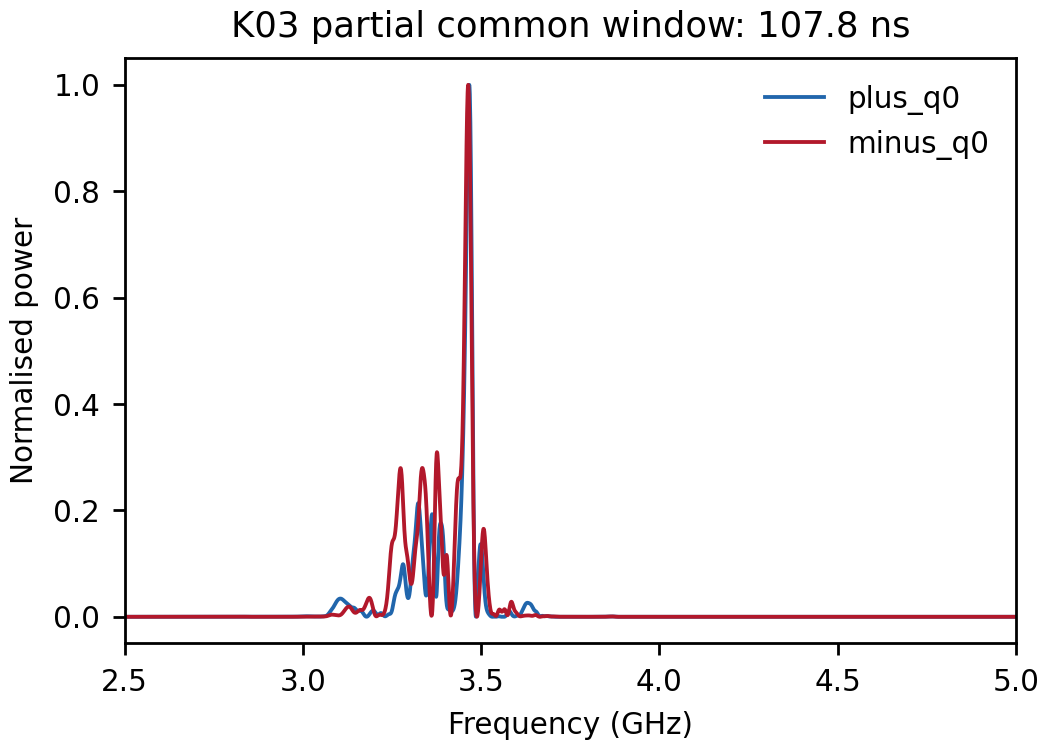

/kaggle/working/jphysd_full_llg_fresh_k03r.zip

K03R partial audit passed. This preliminary result uses the common truncated window and must be labelled accordingly; decide next whether a shorter complete rerun or direct K04 fitting is justified.


In [17]:
"""Kaggle K03R: recover and analyse autosaved partial K03 tables.

Run in the same session immediately after K03 timed out.  This cell never
deletes or resumes a MuMax run.  It trims both cases to their common completed
physical time and decides whether the partial paired record is long enough for
a preliminary direct-dynamic comparison.
"""
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, re, warnings, zipfile
import numpy as np

PIPELINE_VERSION="jphysd-kaggle-full-llg-fresh-k03r-v1"
ROOT=Path("/kaggle/working/jphysd_full_llg_fresh")
CONFIG=ROOT/"locks"/"fresh_full_llg_config.json"
K03=ROOT/"k03_paired_direct_dynamics"
TABLES={"plus_q0":K03/"runs"/"plus_q0.out"/"table.txt","minus_q0":K03/"runs"/"minus_q0.out"/"table.txt"}
STAGE=ROOT/"k03r_partial_recovery"; REPORT=STAGE/"k03r_report.json"; ARCHIVE=Path("/kaggle/working/jphysd_full_llg_fresh_k03r.zip")
MINIMUM_USABLE_DURATION=40e-9; ANALYSIS_START=2e-9; SEARCH=(2.5e9,5.0e9); OVERSAMPLE=8

def banner(x): print("\n"+"="*78+"\n"+x+"\n"+"="*78)
def sha(p):
 h=hashlib.sha256()
 with Path(p).open("rb") as f:
  for b in iter(lambda:f.read(1048576),b""): h.update(b)
 return h.hexdigest()
def safe(x):
 if isinstance(x,Path): return str(x)
 if isinstance(x,np.generic): return x.item()
 if isinstance(x,np.ndarray): return x.tolist()
 if isinstance(x,dict): return {str(k):safe(v) for k,v in x.items()}
 if isinstance(x,(list,tuple)): return [safe(v) for v in x]
 return x
def write_json(p,x): p.parent.mkdir(parents=True,exist_ok=True); p.write_text(json.dumps(safe(x),indent=2,sort_keys=True,allow_nan=False)+"\n")
def load_table(path):
 lines=Path(path).read_text(errors="replace").splitlines(); numeric=[]
 for line in lines:
  if not line.strip() or line.lstrip().startswith("#"): continue
  try: numeric.append([float(x) for x in line.split()])
  except ValueError: continue
 if not numeric: raise RuntimeError(f"No numeric rows in {path}")
 width=max(map(len,numeric)); numeric=[r for r in numeric if len(r)==width]; a=np.asarray(numeric,float)
 candidates=[]
 for raw in lines:
  if raw.lstrip().startswith("#"):
   labels=[x.strip() for x in re.split(r"\t+",raw.lstrip()[1:].strip()) if x.strip()]
   if len(labels)==width: candidates.append(labels)
 if not candidates: raise RuntimeError(f"No {width}-column tab header in {path}")
 # MuMax may write both a quantity-name row and a same-width units row.
 # Select the row carrying the most region annotations, not the last row.
 labels=max(candidates,key=lambda row:sum("region" in item.lower() for item in row))
 if sum("region" in item.lower() for item in labels)<40:
  raise RuntimeError(
   "Could not identify the quantity-name header. First labels: "
   +repr(labels[:16])
  )
 finite=np.isfinite(a).all(axis=1); a=a[finite]; a=a[np.argsort(a[:,0],kind="stable")]
 _,unique=np.unique(a[:,0],return_index=True); return labels,a[unique]
def columns(labels,region):
 hits=[]
 for i,s in enumerate(labels):
  base=s.lower().split("(",1)[0].strip()
  # MuMax 3.12 labels vectors as m.region10x/y/z.  Keep compatibility
  # with variants such as m_region10_x and m_x (region 10).
  compact=re.sub(r"[^a-z0-9]","",base)
  if re.match(rf"^mregion{region}[xyz]$",compact) or (
      base.startswith("m_") and re.search(rf"region\D*{region}(?:\D|$)",base)
  ): hits.append(i)
 if len(hits)<3:
  nearby=[s for s in labels if str(region) in s][:12]
  raise RuntimeError(
   f"Region {region}: found {len(hits)} m columns; labels containing the id: {nearby}"
  )
 return hits[:3]
def extract(path,c):
 labels,a=load_table(path); o=c["regions"]; groups={}
 for name,first,n in (("control",o["control_first"],o["control_x_stripes"]),("target",o["target_first"],o["target_x_stripes"])):
  idx=np.asarray([columns(labels,r) for r in range(first,first+n)]); groups[name]=a[:,idx]
 return a[:,0],groups,int(a.shape[0]),sha(path)
def spectrum(t,y,z):
 keep=t>=ANALYSIS_START; t,y,z=t[keep],y[keep],z[keep]; dt=float(np.median(np.diff(t))); ut=np.arange(t[0],t[-1]+0.25*dt,dt)
 uy=np.interp(ut,t,y); uz=np.interp(ut,t,z); w=np.hanning(ut.size); nfft=1
 while nfft<OVERSAMPLE*ut.size: nfft*=2
 f=np.fft.rfftfreq(nfft,dt); p=np.abs(np.fft.rfft(w*(uy-uy.mean()),nfft))**2+np.abs(np.fft.rfft(w*(uz-uz.mean()),nfft))**2
 band=(f>=SEARCH[0])&(f<=SEARCH[1]); ids=np.flatnonzero(band); idx=ids[np.argmax(p[band])]; raw=1/(ut[-1]-ut[0]); noise=p[band & (np.abs(f-f[idx])>3*raw)]
 return float(f[idx]),float(raw),float(p[idx]/max(np.median(noise),np.finfo(float).tiny)),f,p
def analyse(t,g,c,sign,common_end):
 keep=t<=common_end+1e-18; t=t[keep]; control=g["control"][keep]; target=g["target"][keep]
 co=c["geometry"]["control"]; n=control.shape[1]; x=np.linspace(co["center_m"][0]-co["radius_m"],co["center_m"][0]+co["radius_m"],n,endpoint=False); x+=(x[1]-x[0])/2
 q=sign*c["logical_control"]["q0_rad_per_m"]; proj=np.mean((control[:,:,1]+1j*control[:,:,2])*np.exp(-1j*q*x)[None,:],axis=1)
 y=np.mean(target[:,:,1],axis=1); z=np.mean(target[:,:,2],axis=1); peak,raw,snr,f,p=spectrum(t,y,z)
 early=np.abs(proj[t<=min(5e-9,common_end)]); late=np.abs(proj[t>=max(ANALYSIS_START,common_end-5e-9)])
 return {"samples_common":int(t.size),"common_end_s":float(t[-1]),"median_dt_s":float(np.median(np.diff(t))),"control_projection_t0":float(np.abs(proj[0])),"control_projection_early_0to5ns":float(np.median(early)),"control_projection_late":float(np.median(late)),"control_retention_from_early_median":float(np.median(late)/max(np.median(early),1e-30)),"target_peak_Hz":peak,"raw_resolution_Hz":raw,"target_power_SNR":snr,"target_rms":float(np.sqrt(np.mean(y*y+z*z))),"_f":f,"_p":p}

banner("K03R — RECOVER AUTOSAVED PARTIAL PAIRED DYNAMICS")
STAGE.mkdir(parents=True,exist_ok=True); checks={}; report={"pipeline_version":PIPELINE_VERSION,"stage":"K03R_partial_autosave_recovery","status":"FAIL_K03R","checks":checks,"failed_checks":[],"started_utc":datetime.now(timezone.utc).isoformat(),"scientific_scope":"Recovery analysis of identically truncated autosaved K03 records; preliminary medium-mesh direct test only."}
try:
 c=json.loads(CONFIG.read_text()); checks["both_tables_exist"]=all(p.is_file() and p.stat().st_size>100 for p in TABLES.values())
 if not checks["both_tables_exist"]: raise RuntimeError("One or both partial table.txt files are absent")
 loaded={}
 for label,p in TABLES.items():
  sign=1 if label=="plus_q0" else -1; t,g,rows,digest=extract(p,c); loaded[label]={"sign":sign,"t":t,"g":g,"rows":rows,"sha256":digest,"end_s":float(t[-1])}; print(f"{label}: rows={rows} end={t[-1]*1e9:.3f} ns size={p.stat().st_size/1e6:.1f} MB")
 common=min(x["end_s"] for x in loaded.values()); checks["common_duration_at_least_40ns"]=common>=MINIMUM_USABLE_DURATION
 end_difference=abs(loaded["plus_q0"]["end_s"]-loaded["minus_q0"]["end_s"])
 checks["common_window_trimming_applied"]=common>0
 if not checks["common_duration_at_least_40ns"]: raise RuntimeError(f"Only {common*1e9:.2f} ns common data; rerun a shorter production case")
 results=[]
 for label,x in loaded.items():
  z=analyse(x["t"],x["g"],c,x["sign"],common); z.update({"state":label,"original_rows":x["rows"],"original_end_s":x["end_s"],"table_sha256":x["sha256"]}); results.append(z); print(f"{label}: peak={z['target_peak_Hz']*1e-9:.7f} GHz SNR={z['target_power_SNR']:.1f} retention={z['control_retention_from_early_median']:.4f}")
 checks["both_SNR_at_least_10"]=all(x["target_power_SNR"]>=10 for x in results)
 pdiff=abs(results[0]["control_projection_t0"]-results[1]["control_projection_t0"])/max(np.mean([results[0]["control_projection_t0"],results[1]["control_projection_t0"]]),1e-30); checks["t0_projection_match_below_2pct"]=pdiff<=0.02
 delta=abs(results[0]["target_peak_Hz"]-results[1]["target_peak_Hz"]); raw=max(x["raw_resolution_Hz"] for x in results)
 if not checks["both_SNR_at_least_10"]: outcome="DIRECT_TARGET_RESPONSE_UNRESOLVED"
 elif delta>raw: outcome="CANDIDATE_DIRECT_DYNAMIC_CONTRAST_REQUIRES_K04_FIT"
 else: outcome="NO_RESOLVED_DIRECT_FREQUENCY_CONTRAST_IN_PARTIAL_MEDIUM_RUN"
 report["comparison"]={"common_duration_s":common,"original_end_time_difference_s":end_difference,"frequency_difference_Hz":delta,"raw_resolution_Hz":raw,"t0_projection_relative_difference":pdiff,"preliminary_outcome":outcome}; report["results"]=[{k:v for k,v in x.items() if not k.startswith("_")} for x in results]
 import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
 fig,ax=plt.subplots(figsize=(4.2,3.0),constrained_layout=True)
 for x,color in zip(results,("#2166ac","#b2182b")): ax.plot(x["_f"]*1e-9,x["_p"]/max(np.max(x["_p"]),1e-300),color=color,label=x["state"])
 ax.set_xlim(SEARCH[0]*1e-9,SEARCH[1]*1e-9); ax.set(xlabel="Frequency (GHz)",ylabel="Normalised power",title=f"K03 partial common window: {common*1e9:.1f} ns"); ax.legend(frameon=False); fig.savefig(STAGE/"k03r_partial_spectra.png",dpi=250); fig.savefig(STAGE/"k03r_partial_spectra.pdf"); plt.close(fig)
 required=["both_tables_exist","common_duration_at_least_40ns","common_window_trimming_applied","t0_projection_match_below_2pct"]; report["required_checks"]=required; report["failed_checks"]=[x for x in required if not checks.get(x,False)]; report["status"]="PASS_K03R_PARTIAL_AUDIT" if not report["failed_checks"] else "FAIL_K03R"
except Exception as e:
 report["exception"]={"type":type(e).__name__,"message":str(e)}; report["failed_checks"]=[k for k,v in checks.items() if not v] or ["K03R_exception"]
report["finished_utc"]=datetime.now(timezone.utc).isoformat(); write_json(REPORT,report)
if ARCHIVE.exists(): ARCHIVE.unlink()
with zipfile.ZipFile(ARCHIVE,"w",zipfile.ZIP_DEFLATED) as z:
 for p in sorted(x for x in STAGE.rglob("*") if x.is_file()): z.write(p,arcname=p.relative_to(STAGE).as_posix())
banner(f"K03R COMPLETE | {report['status']}"); print(json.dumps(safe({"status":report["status"],"failed_checks":report["failed_checks"],"comparison":report.get("comparison"),"results":report.get("results"),"exception":report.get("exception"),"report":REPORT,"archive":ARCHIVE}),indent=2,allow_nan=False))
try:
 from IPython.display import FileLink,Image,display
 if (STAGE/"k03r_partial_spectra.png").is_file(): display(Image(filename=str(STAGE/"k03r_partial_spectra.png")))
 display(FileLink(str(ARCHIVE)))
except Exception: pass
if report["status"]!="PASS_K03R_PARTIAL_AUDIT": raise RuntimeError(f"K03R failed: {report['failed_checks']} | {report.get('exception')}")
print("K03R partial audit passed. This preliminary result uses the common truncated window and must be labelled accordingly; decide next whether a shorter complete rerun or direct K04 fitting is justified.")



K04 — DAMPED-MODE FIT, WINDOW STABILITY, AND UNCERTAINTY
plus_q0 [(5.0, 3.4687026, 0.9433), (10.0, 3.4688644, 0.9409), (15.0, 3.4673152, 0.9362), (20.0, 3.4675494, 0.933)]
minus_q0 [(5.0, 3.4618469, 0.9403), (10.0, 3.4614099, 0.9367), (15.0, 3.4618701, 0.9254), (20.0, 3.4618555, 0.9228)]

K04 COMPLETE | PASS_K04_ANALYSIS
{
  "status": "PASS_K04_ANALYSIS",
  "failed_checks": [],
  "outcome": "SINGLE_DAMPED_MODE_MODEL_INADEQUATE",
  "primary_fits": {
    "plus_q0": {
      "frequency_Hz": 3468864414.853614,
      "decay_rate_per_ns": 1.0922581615579972e-67,
      "decay_time_ns": 9.155344727052437e+66,
      "NRMSE": 0.9408615506242287,
      "start_ns": 10.0,
      "samples": 4891
    },
    "minus_q0": {
      "frequency_Hz": 3461409905.38023,
      "decay_rate_per_ns": 2.841335840782252e-112,
      "decay_time_ns": 3.5194713192534417e+111,
      "NRMSE": 0.9367125698585997,
      "start_ns": 10.0,
      "samples": 4892
    }
  },
  "bootstrap": {
    "count": {
      "plus_q0": 120,


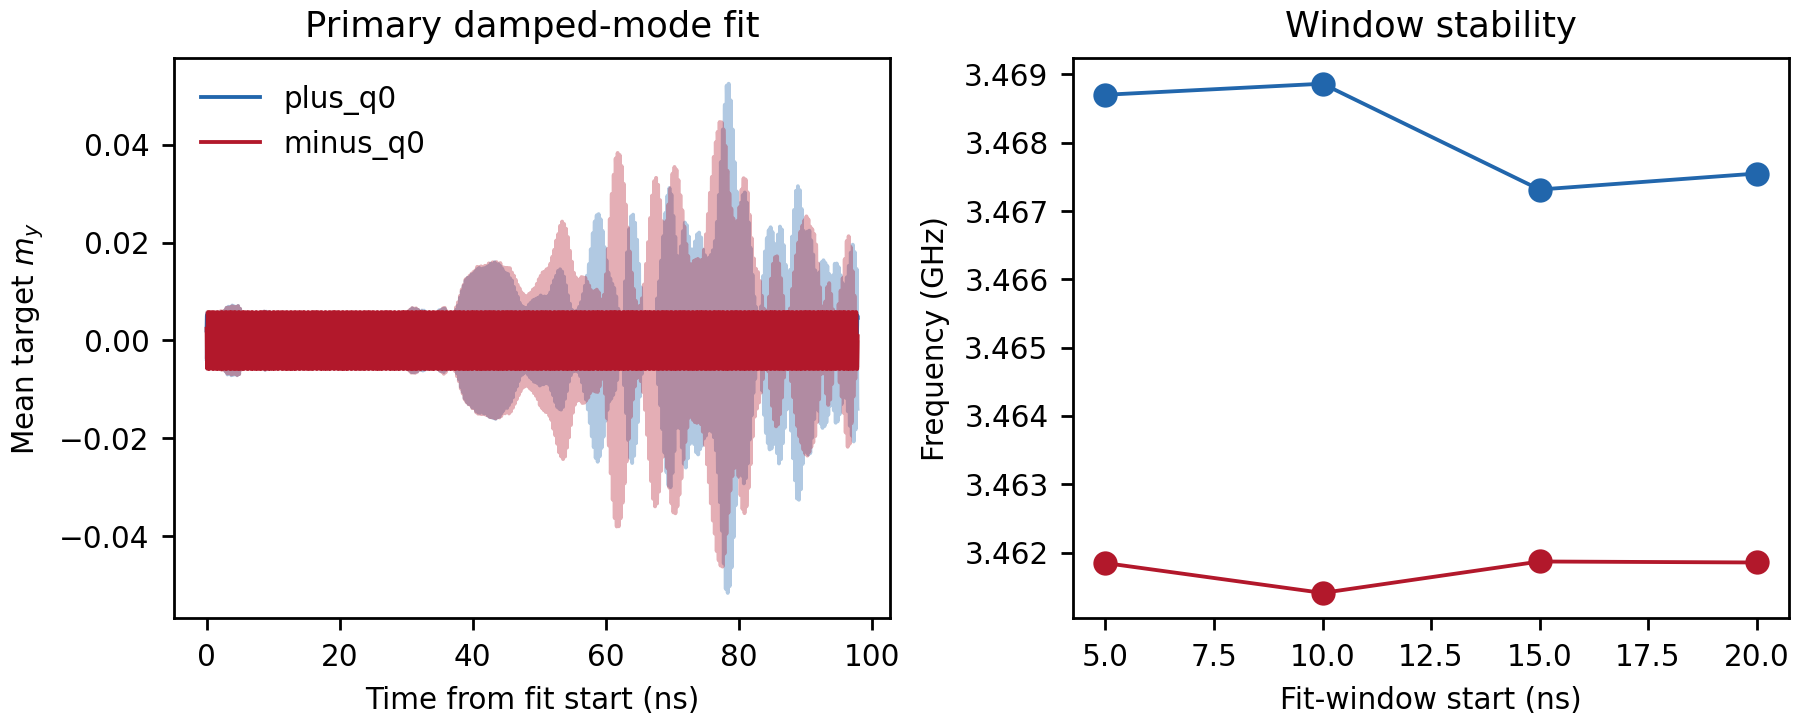

/kaggle/working/jphysd_full_llg_fresh_k04.zip

K04 analysis complete. Interpret the outcome field; a numerically nonzero fitted delta is not accepted unless fit quality, window stability, confidence interval, and later convergence all support it.


In [18]:
"""Kaggle K04: paired damped-mode fit, window stability, and uncertainty.

Analysis only. Run after K03R in the same session. No MuMax job is launched.
The result is allowed to remain unresolved or fail the single-mode model.
"""
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, re, zipfile
import numpy as np
from scipy.optimize import least_squares

PIPELINE_VERSION="jphysd-kaggle-full-llg-fresh-k04-v1"
ROOT=Path("/kaggle/working/jphysd_full_llg_fresh"); CONFIG=ROOT/"locks"/"fresh_full_llg_config.json"
K03R=ROOT/"k03r_partial_recovery"/"k03r_report.json"; BASE=ROOT/"k03_paired_direct_dynamics"/"runs"
TABLES={"plus_q0":BASE/"plus_q0.out"/"table.txt","minus_q0":BASE/"minus_q0.out"/"table.txt"}
STAGE=ROOT/"k04_fit_uncertainty"; REPORT=STAGE/"k04_report.json"; ARCHIVE=Path("/kaggle/working/jphysd_full_llg_fresh_k04.zip")
WINDOW_STARTS_NS=(5.0,10.0,15.0,20.0); PRIMARY_START_NS=10.0; BOOTSTRAPS=120; BLOCK_NS=1.0; RNG_SEED=20260721

def banner(x): print("\n"+"="*78+"\n"+x+"\n"+"="*78)
def sha(p):
 h=hashlib.sha256()
 with Path(p).open("rb") as f:
  for b in iter(lambda:f.read(1048576),b""): h.update(b)
 return h.hexdigest()
def safe(x):
 if isinstance(x,Path): return str(x)
 if isinstance(x,np.generic): return x.item()
 if isinstance(x,np.ndarray): return x.tolist()
 if isinstance(x,dict): return {str(k):safe(v) for k,v in x.items()}
 if isinstance(x,(list,tuple)): return [safe(v) for v in x]
 return x
def write_json(p,x): p.parent.mkdir(parents=True,exist_ok=True); p.write_text(json.dumps(safe(x),indent=2,sort_keys=True,allow_nan=False)+"\n")
def load(path):
 lines=Path(path).read_text(errors="replace").splitlines(); rows=[]
 for s in lines:
  if not s.strip() or s.lstrip().startswith("#"): continue
  try: rows.append([float(x) for x in s.split()])
  except ValueError: pass
 width=max(map(len,rows)); rows=[r for r in rows if len(r)==width]; a=np.asarray(rows,float); heads=[]
 for s in lines:
  if s.lstrip().startswith("#"):
   z=[x.strip() for x in re.split(r"\t+",s.lstrip()[1:].strip()) if x.strip()]
   if len(z)==width: heads.append(z)
 labels=max(heads,key=lambda z:sum("region" in x.lower() for x in z)); a=a[np.isfinite(a).all(axis=1)]; a=a[np.argsort(a[:,0])]; _,u=np.unique(a[:,0],return_index=True)
 return labels,a[u]
def cols(labels,r):
 out=[]
 for i,s in enumerate(labels):
  base=s.lower().split("(",1)[0].strip(); compact=re.sub(r"[^a-z0-9]","",base)
  if re.match(rf"^mregion{r}[xyz]$",compact): out.append(i)
 if len(out)!=3: raise RuntimeError(f"region {r}: expected 3 m columns, found {len(out)}")
 return out
def traces(path,c,common_end):
 labels,a=load(path); keep=a[:,0]<=common_end+1e-18; a=a[keep]; o=c["regions"]
 ti=np.asarray([cols(labels,r) for r in range(o["target_first"],o["target_first"]+o["target_x_stripes"])]); ci=np.asarray([cols(labels,r) for r in range(o["control_first"],o["control_first"]+o["control_x_stripes"])])
 target=a[:,ti]; control=a[:,ci]; return a[:,0],np.mean(target[:,:,1],axis=1),np.mean(target[:,:,2],axis=1),control
def initial_frequency(t,y,z,start):
 k=t>=start; t,y,z=t[k],y[k],z[k]; dt=np.median(np.diff(t)); u=np.arange(t[0],t[-1]+dt/4,dt); yy=np.interp(u,t,y); zz=np.interp(u,t,z); w=np.hanning(u.size); n=1
 while n<8*u.size: n*=2
 f=np.fft.rfftfreq(n,dt); p=np.abs(np.fft.rfft(w*(yy-yy.mean()),n))**2+np.abs(np.fft.rfft(w*(zz-zz.mean()),n))**2; b=(f>=2.5e9)&(f<=5e9); return float(f[np.flatnonzero(b)[np.argmax(p[b])]])
def design(t_ns,f_GHz,lam):
 e=np.exp(-lam*t_ns); ph=2*np.pi*f_GHz*t_ns; return np.column_stack((np.ones(t_ns.size),t_ns,e*np.cos(ph),e*np.sin(ph)))
def fit_mode(t,y,z,start_ns,guess_Hz=None):
 k=t>=start_ns*1e-9; tt=t[k]; yy=y[k]; zz=z[k]; x=(tt-tt[0])*1e9
 if guess_Hz is None: guess_Hz=initial_frequency(tt,yy,zz,tt[0])
 scale=max(np.sqrt(np.mean((yy-yy.mean())**2+(zz-zz.mean())**2)),1e-15)
 def solve(p):
  X=design(x,p[0],p[1]); by=np.linalg.lstsq(X,yy,rcond=None)[0]; bz=np.linalg.lstsq(X,zz,rcond=None)[0]; return X@by,X@bz,by,bz
 def residual(p):
  py,pz,_,_=solve(p); return np.r_[yy-py,zz-pz]/scale
 opt=least_squares(residual,[guess_Hz*1e-9,0.01],bounds=([2.5,0],[5.0,2.0]),xtol=1e-11,ftol=1e-11,gtol=1e-11,max_nfev=300)
 py,pz,by,bz=solve(opt.x); resid=np.column_stack((yy-py,zz-pz)); nrmse=float(np.sqrt(np.mean(resid**2))/max(np.sqrt(np.mean(np.column_stack((yy-yy.mean(),zz-zz.mean()))**2)),1e-30))
 return {"frequency_Hz":float(opt.x[0]*1e9),"decay_rate_per_ns":float(opt.x[1]),"decay_time_ns":float(1/opt.x[1]) if opt.x[1]>0 else None,"NRMSE":nrmse,"start_ns":start_ns,"samples":int(x.size),"t_ns":x,"y":yy,"z":zz,"fit_y":py,"fit_z":pz,"residual":resid}
def bootstrap(base,rng):
 n=base["t_ns"].size; dt=np.median(np.diff(base["t_ns"])); block=max(2,int(round(BLOCK_NS/dt))); starts=np.arange(0,max(1,n-block+1)); values=[]
 for _ in range(BOOTSTRAPS):
  pieces=[]
  while sum(x.shape[0] for x in pieces)<n:
   j=int(rng.choice(starts)); pieces.append(base["residual"][j:j+block])
  r=np.vstack(pieces)[:n]; y=base["fit_y"]+r[:,0]; z=base["fit_z"]+r[:,1]; fake_t=(base["t_ns"]+base["start_ns"])*1e-9
  try: values.append(fit_mode(fake_t,y,z,base["start_ns"],base["frequency_Hz"])["frequency_Hz"])
  except Exception: pass
 return np.asarray(values)
def public(x): return {k:v for k,v in x.items() if k not in {"t_ns","y","z","fit_y","fit_z","residual"}}

banner("K04 — DAMPED-MODE FIT, WINDOW STABILITY, AND UNCERTAINTY")
STAGE.mkdir(parents=True,exist_ok=True); checks={}; report={"pipeline_version":PIPELINE_VERSION,"stage":"K04_partial_paired_fit_uncertainty","status":"FAIL_K04","checks":checks,"failed_checks":[],"started_utc":datetime.now(timezone.utc).isoformat(),"scientific_scope":"Sub-bin fit of K03R partial records. Acceptance requires fit quality, window stability, and a confidence interval; no CNOT or explicit double-well claim."}
try:
 c=json.loads(CONFIG.read_text()); r3=json.loads(K03R.read_text()); checks["K03R_PASS"]=r3.get("status")=="PASS_K03R_PARTIAL_AUDIT" and not r3.get("failed_checks"); common=float(r3["comparison"]["common_duration_s"]); checks["both_tables_exist"]=all(p.is_file() for p in TABLES.values())
 if not all(checks.values()): raise RuntimeError("K03R chain or raw tables missing")
 data={}; windows={}
 for label,path in TABLES.items():
  t,y,z,control=traces(path,c,common); data[label]=(t,y,z,control); windows[label]=[fit_mode(t,y,z,s) for s in WINDOW_STARTS_NS]
  print(label,[(s,round(f["frequency_Hz"]*1e-9,7),round(f["NRMSE"],4)) for s,f in zip(WINDOW_STARTS_NS,windows[label])])
 primary={label:next(x for x in fits if x["start_ns"]==PRIMARY_START_NS) for label,fits in windows.items()}
 checks["primary_NRMSE_below_5pct"]=all(x["NRMSE"]<=0.05 for x in primary.values())
 spans={label:float(np.ptp([x["frequency_Hz"] for x in fits])) for label,fits in windows.items()}; raw=1/(common-PRIMARY_START_NS*1e-9); checks["window_span_below_raw_resolution"]=all(x<=raw for x in spans.values())
 rng=np.random.default_rng(RNG_SEED); boots={label:bootstrap(x,rng) for label,x in primary.items()}; checks["at_least_100_bootstraps_each"]=all(x.size>=100 for x in boots.values())
 delta=primary["plus_q0"]["frequency_Hz"]-primary["minus_q0"]["frequency_Hz"]; bd=boots["plus_q0"][:min(map(len,boots.values()))]-boots["minus_q0"][:min(map(len,boots.values()))]; ci=np.percentile(bd,[2.5,50,97.5]) if bd.size else np.array([np.nan]*3)
 resolved=bool(np.isfinite(ci).all() and (ci[0]>0 or ci[2]<0)); checks["delta_CI_excludes_zero"]=resolved
 if not checks["primary_NRMSE_below_5pct"]: outcome="SINGLE_DAMPED_MODE_MODEL_INADEQUATE"
 elif not checks["window_span_below_raw_resolution"]: outcome="FREQUENCY_NOT_STABLE_TO_FIT_WINDOW"
 elif resolved: outcome="CANDIDATE_SUBBIN_DIRECT_CONTRAST_REQUIRES_CONVERGENCE"
 else: outcome="DIRECT_FREQUENCY_DIFFERENCE_UNRESOLVED_BY_BOOTSTRAP"
 report["fit_windows"]={k:[public(x) for x in v] for k,v in windows.items()}; report["primary_fits"]={k:public(v) for k,v in primary.items()}; report["window_frequency_spans_Hz"]=spans; report["bootstrap"]={"count":{k:int(v.size) for k,v in boots.items()},"frequency_difference_Hz":float(delta),"difference_CI95_Hz":ci,"CI_excludes_zero":resolved}; report["outcome"]=outcome
 import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
 fig,ax=plt.subplots(1,2,figsize=(7.2,2.9),constrained_layout=True)
 for label,color in (("plus_q0","#2166ac"),("minus_q0","#b2182b")):
  x=primary[label]; ax[0].plot(x["t_ns"],x["y"],color=color,alpha=.35); ax[0].plot(x["t_ns"],x["fit_y"],color=color,label=label); ax[1].plot(WINDOW_STARTS_NS,[v["frequency_Hz"]*1e-9 for v in windows[label]],"o-",color=color,label=label)
 ax[0].set(xlabel="Time from fit start (ns)",ylabel="Mean target $m_y$",title="Primary damped-mode fit"); ax[1].set(xlabel="Fit-window start (ns)",ylabel="Frequency (GHz)",title="Window stability"); ax[0].legend(frameon=False); fig.savefig(STAGE/"k04_fit_diagnostics.png",dpi=250); fig.savefig(STAGE/"k04_fit_diagnostics.pdf"); plt.close(fig)
 required=["K03R_PASS","both_tables_exist","at_least_100_bootstraps_each"]; report["required_checks"]=required; report["failed_checks"]=[x for x in required if not checks.get(x,False)]; report["status"]="PASS_K04_ANALYSIS" if not report["failed_checks"] else "FAIL_K04"
except Exception as e:
 report["exception"]={"type":type(e).__name__,"message":str(e)}; report["failed_checks"]=[k for k,v in checks.items() if not v] or ["K04_exception"]
report["finished_utc"]=datetime.now(timezone.utc).isoformat(); write_json(REPORT,report)
if ARCHIVE.exists(): ARCHIVE.unlink()
with zipfile.ZipFile(ARCHIVE,"w",zipfile.ZIP_DEFLATED) as z:
 for p in sorted(x for x in STAGE.rglob("*") if x.is_file()): z.write(p,arcname=p.relative_to(STAGE).as_posix())
banner(f"K04 COMPLETE | {report['status']}"); print(json.dumps(safe({"status":report["status"],"failed_checks":report["failed_checks"],"outcome":report.get("outcome"),"primary_fits":report.get("primary_fits"),"bootstrap":report.get("bootstrap"),"window_spans_Hz":report.get("window_frequency_spans_Hz"),"exception":report.get("exception"),"report":REPORT,"archive":ARCHIVE}),indent=2,allow_nan=False))
try:
 from IPython.display import FileLink,Image,display
 if (STAGE/"k04_fit_diagnostics.png").is_file(): display(Image(filename=str(STAGE/"k04_fit_diagnostics.png")))
 display(FileLink(str(ARCHIVE)))
except Exception: pass
if report["status"]!="PASS_K04_ANALYSIS": raise RuntimeError(f"K04 failed: {report['failed_checks']} | {report.get('exception')}")
print("K04 analysis complete. Interpret the outcome field; a numerically nonzero fitted delta is not accepted unless fit quality, window stability, confidence interval, and later convergence all support it.")



K04B — TIME-FREQUENCY AND MULTIMODE AUDIT
plus_q0: onset=52.329 ns | peaks GHz=[3.36275  3.467068 3.632751 3.141839 3.111157] | envelope RMS=0.0120385
minus_q0: onset=52.329 ns | peaks GHz=[3.368886 3.460932 3.270703 3.178657 3.577524] | envelope RMS=0.0130393

K04B COMPLETE | PASS_K04B_TIME_FREQUENCY_AUDIT
{
  "status": "PASS_K04B_TIME_FREQUENCY_AUDIT",
  "failed_checks": [],
  "cases": {
    "plus_q0": {
      "response_onset_s": 5.232880453038302e-08,
      "envelope_rms": 0.012038499520511545,
      "control_projection_final_over_initial": 0.5184635804409464,
      "dominant_full_record_peaks_Hz": [
        3362749535.6129413,
        3467068408.068087,
        3632751323.1439075,
        3141838982.1785145,
        3111156960.8681774
      ],
      "dominant_peak_relative_powers": [
        1.0,
        0.7859774043676196,
        0.16908153405535567,
        0.0816936468981274,
        0.08119583271509209
      ]
    },
    "minus_q0": {
      "response_onset_s": 5.2328804530383

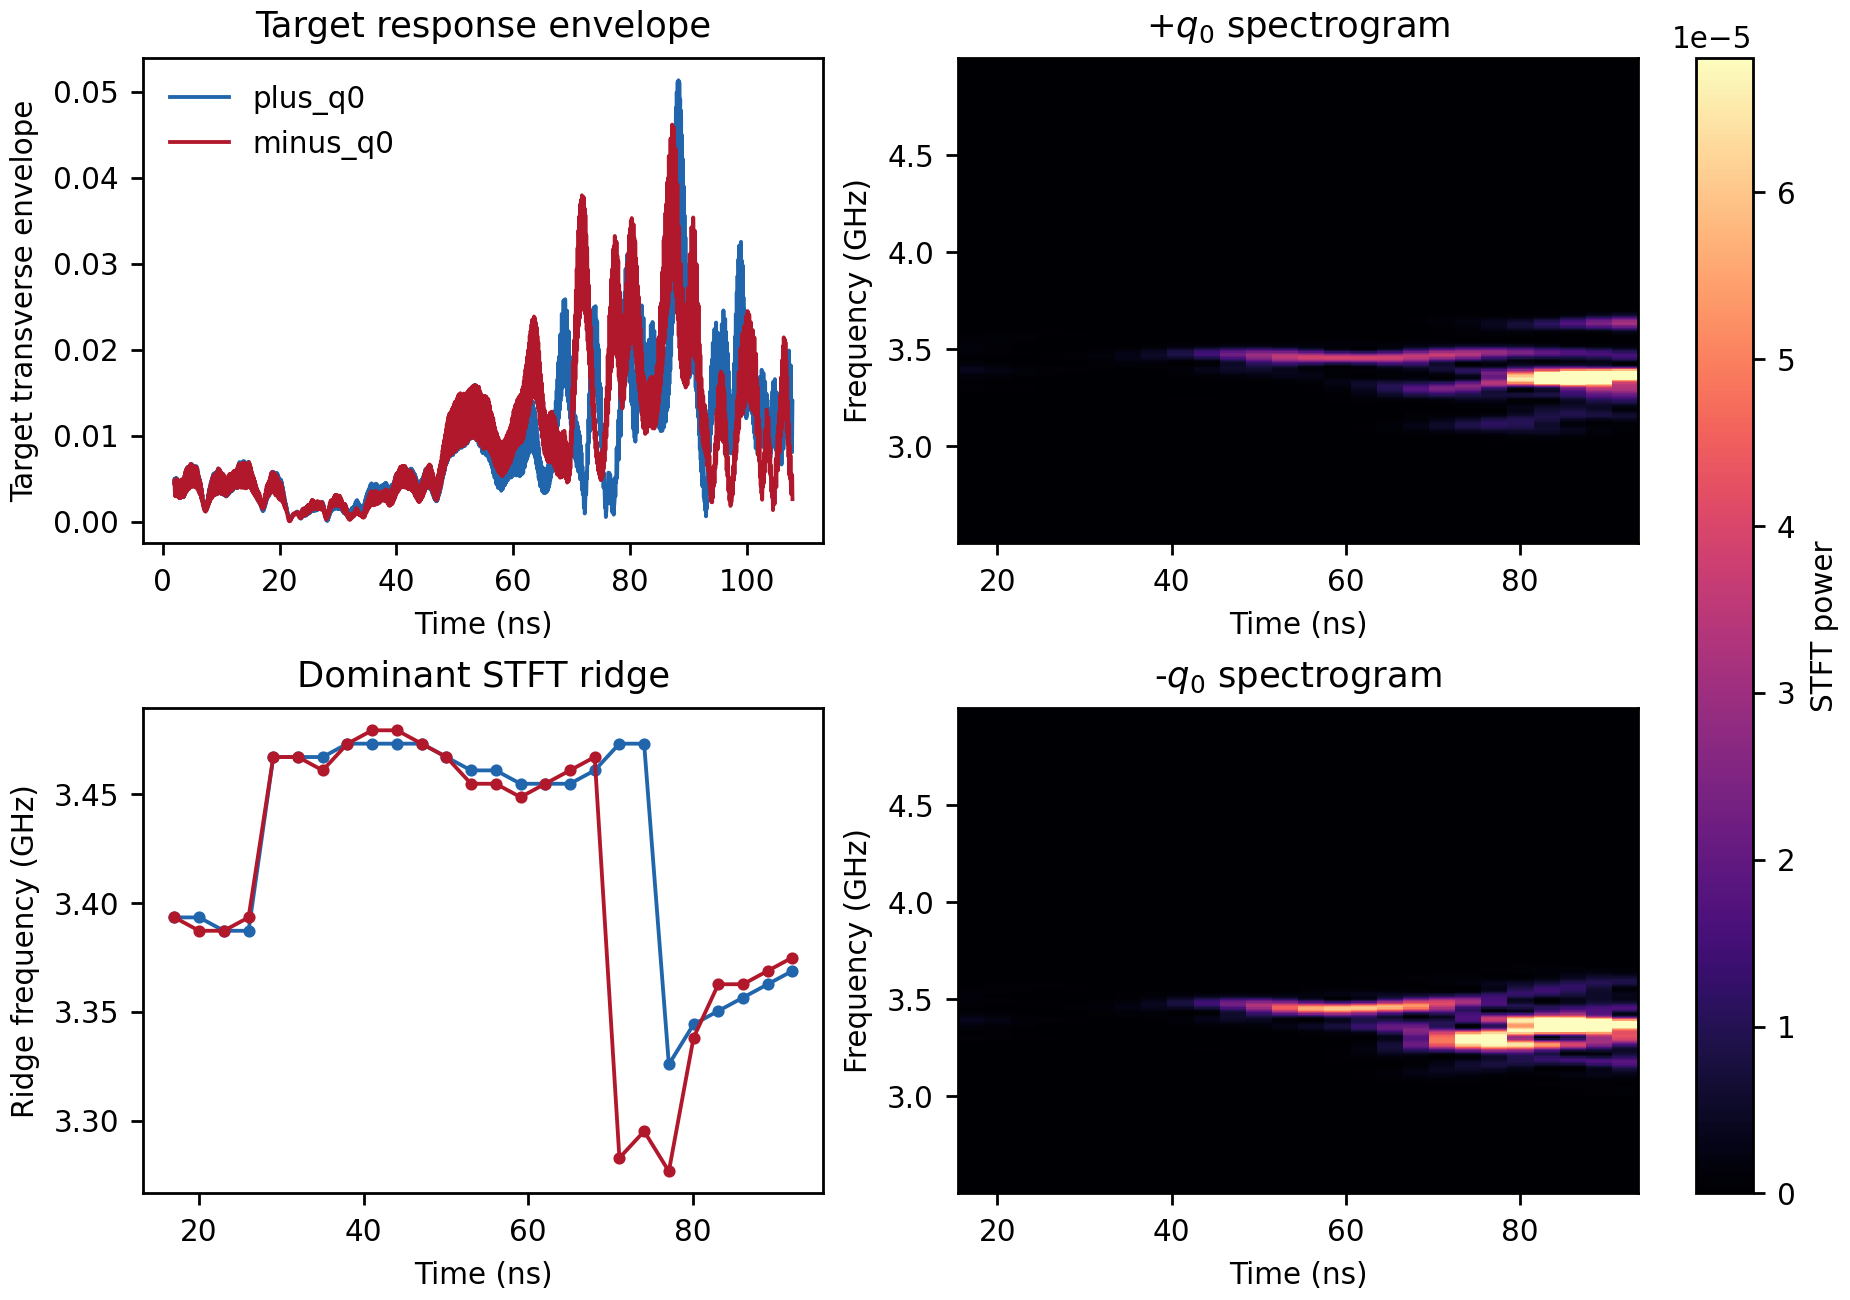

/kaggle/working/jphysd_full_llg_fresh_k04b.zip

K04B audit complete. Use the interpretation outcome to choose a shorter controlled target-probe run; do not promote a descriptive envelope difference to mode splitting or CNOT evidence.


In [19]:
"""Kaggle K04B: time-frequency and multimode audit of partial K03 dynamics.

Analysis only; no MuMax process is launched.  The cell tests whether +/-q0
excite a common target-mode family with different non-stationary envelopes or
produce a persistent resolvable ridge-frequency difference.  Results support
only the declared single-ellipse two-body LLG layer and must not be described
as an explicit double-well or CNOT simulation.
"""
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, re, zipfile
import numpy as np
from scipy.signal import stft, find_peaks

PIPELINE_VERSION="jphysd-kaggle-full-llg-fresh-k04b-v1"
ROOT=Path("/kaggle/working/jphysd_full_llg_fresh"); CONFIG=ROOT/"locks"/"fresh_full_llg_config.json"
K03R=ROOT/"k03r_partial_recovery"/"k03r_report.json"; BASE=ROOT/"k03_paired_direct_dynamics"/"runs"
TABLES={"plus_q0":BASE/"plus_q0.out"/"table.txt","minus_q0":BASE/"minus_q0.out"/"table.txt"}
STAGE=ROOT/"k04b_time_frequency_audit"; REPORT=STAGE/"k04b_report.json"; ARCHIVE=Path("/kaggle/working/jphysd_full_llg_fresh_k04b.zip")
SEARCH=(2.5e9,5.0e9); STFT_WINDOW_NS=30.0; STFT_STEP_NS=3.0; ANALYSIS_START_NS=2.0
RIDGE_MIN_RELATIVE_POWER=0.01; COMMON_RIDGE_TOLERANCE_BINS=1.0; AMPLITUDE_EFFECT_THRESHOLD=0.05

def banner(x): print("\n"+"="*78+"\n"+x+"\n"+"="*78)
def sha(p):
 h=hashlib.sha256()
 with Path(p).open("rb") as f:
  for b in iter(lambda:f.read(1048576),b""): h.update(b)
 return h.hexdigest()
def safe(x):
 if isinstance(x,Path): return str(x)
 if isinstance(x,np.generic): return x.item()
 if isinstance(x,np.ndarray): return x.tolist()
 if isinstance(x,dict): return {str(k):safe(v) for k,v in x.items()}
 if isinstance(x,(list,tuple)): return [safe(v) for v in x]
 return x
def write_json(p,x): p.parent.mkdir(parents=True,exist_ok=True); p.write_text(json.dumps(safe(x),indent=2,sort_keys=True,allow_nan=False)+"\n")
def load(path):
 lines=Path(path).read_text(errors="replace").splitlines(); rows=[]
 for s in lines:
  if not s.strip() or s.lstrip().startswith("#"): continue
  try: rows.append([float(x) for x in s.split()])
  except ValueError: pass
 if not rows: raise RuntimeError(f"No numeric data in {path}")
 width=max(map(len,rows)); a=np.asarray([r for r in rows if len(r)==width],float); heads=[]
 for s in lines:
  if s.lstrip().startswith("#"):
   q=[x.strip() for x in re.split(r"\t+",s.lstrip()[1:].strip()) if x.strip()]
   if len(q)==width: heads.append(q)
 if not heads: raise RuntimeError(f"No matching table header in {path}")
 labels=max(heads,key=lambda q:sum("region" in x.lower() for x in q)); a=a[np.isfinite(a).all(axis=1)]; a=a[np.argsort(a[:,0],kind="stable")]; _,u=np.unique(a[:,0],return_index=True)
 return labels,a[u]
def cols(labels,r,prefix="m"):
 out=[]
 for i,s in enumerate(labels):
  compact=re.sub(r"[^a-z0-9]","",s.lower().split("(",1)[0])
  if re.match(rf"^{prefix}region{r}[xyz]$",compact): out.append(i)
 if len(out)!=3: raise RuntimeError(f"region {r}: expected 3 {prefix} columns, found {len(out)}")
 return out
def extract(path,c,common):
 labels,a=load(path); a=a[a[:,0]<=common+1e-18]; o=c["regions"]
 ti=np.asarray([cols(labels,r) for r in range(o["target_first"],o["target_first"]+o["target_x_stripes"])]); ci=np.asarray([cols(labels,r) for r in range(o["control_first"],o["control_first"]+o["control_x_stripes"])])
 return a[:,0],a[:,ti],a[:,ci]
def uniform(t,target,control,dt,common):
 u=np.arange(max(ANALYSIS_START_NS*1e-9,t[0]),common-dt/4,dt); nt=target.shape[1]; nc=control.shape[1]; T=np.empty((u.size,nt,3)); C=np.empty((u.size,nc,3))
 for j in range(nt):
  for k in range(3): T[:,j,k]=np.interp(u,t,target[:,j,k])
 for j in range(nc):
  for k in range(3): C[:,j,k]=np.interp(u,t,control[:,j,k])
 return u,T,C
def tf_metrics(u,T,C,c,sign):
 dt=float(np.median(np.diff(u))); fs=1/dt; y=np.mean(T[:,:,1],axis=1); z=np.mean(T[:,:,2],axis=1); envelope=np.sqrt(y*y+z*z)
 nper=max(128,int(round(STFT_WINDOW_NS*1e-9/dt))); step=max(1,int(round(STFT_STEP_NS*1e-9/dt))); nover=nper-step; nfft=1
 while nfft<4*nper: nfft*=2
 f,ts,Y=stft(y,fs=fs,window="hann",nperseg=nper,noverlap=nover,nfft=nfft,boundary=None,padded=False); _,_,Z=stft(z,fs=fs,window="hann",nperseg=nper,noverlap=nover,nfft=nfft,boundary=None,padded=False); P=np.abs(Y)**2+np.abs(Z)**2
 band=(f>=SEARCH[0])&(f<=SEARCH[1]); fb=f[band]; Pb=P[band]; idx=np.argmax(Pb,axis=0); ridge=fb[idx]; ridge_power=Pb[idx,np.arange(Pb.shape[1])]; valid=ridge_power>=RIDGE_MIN_RELATIVE_POWER*np.max(ridge_power)
 full=np.sum(Pb,axis=1); distance=max(1,int(round((1/(u[-1]-u[0]))/(fb[1]-fb[0])))); peaks,_=find_peaks(full,height=0.05*np.max(full),distance=distance); order=peaks[np.argsort(full[peaks])[::-1]] if peaks.size else np.array([],int)
 co=c["geometry"]["control"]; x=np.linspace(co["center_m"][0]-co["radius_m"],co["center_m"][0]+co["radius_m"],C.shape[1],endpoint=False); x+=(x[1]-x[0])/2; q=sign*c["logical_control"]["q0_rad_per_m"]; proj=np.mean((C[:,:,1]+1j*C[:,:,2])*np.exp(-1j*q*x)[None,:],axis=1)
 base=envelope[u<=u[0]+10e-9]; threshold=float(np.median(base)+5*1.4826*np.median(np.abs(base-np.median(base)))); sustained=np.convolve((envelope>threshold).astype(int),np.ones(max(1,int(round(2e-9/dt))),int),mode="same"); hit=np.flatnonzero(sustained>=max(1,int(round(1.5e-9/dt)))); onset=float(u[hit[0]]) if hit.size else None
 return {"time":u,"y":y,"z":z,"envelope":envelope,"control_projection":np.abs(proj),"frequency":fb,"stft_time":u[0]+ts,"power":Pb,"ridge":ridge,"ridge_power":ridge_power,"valid":valid,"stft_bin_Hz":float(fb[1]-fb[0]),"dominant_full_record_peaks_Hz":fb[order[:8]],"dominant_peak_relative_powers":full[order[:8]]/np.max(full) if order.size else np.array([]),"response_onset_s":onset,"envelope_rms":float(np.sqrt(np.mean(envelope**2))),"control_projection_final_over_initial":float(np.abs(proj[-1])/max(np.abs(proj[0]),1e-30))}
def window_effect(a,b):
 times=a["stft_time"]; valid=a["valid"]&b["valid"]; diff=np.abs(a["ridge"]-b["ridge"]); amp_a=np.sqrt(a["ridge_power"]); amp_b=np.sqrt(b["ridge_power"]); rel=(amp_b-amp_a)/np.maximum((amp_a+amp_b)/2,1e-300)
 return {"valid_windows":int(np.sum(valid)),"median_absolute_ridge_difference_Hz":float(np.median(diff[valid])) if valid.any() else None,"maximum_absolute_ridge_difference_Hz":float(np.max(diff[valid])) if valid.any() else None,"fraction_same_STFT_bin":float(np.mean(diff[valid]<=a["stft_bin_Hz"])) if valid.any() else None,"median_signed_amplitude_difference_fraction_minus_vs_plus":float(np.median(rel[valid])) if valid.any() else None,"amplitude_difference_IQR":np.percentile(rel[valid],[25,75]) if valid.any() else [None,None],"time_s":times,"valid":valid,"ridge_difference":diff,"amplitude_difference":rel}

banner("K04B — TIME-FREQUENCY AND MULTIMODE AUDIT")
STAGE.mkdir(parents=True,exist_ok=True); checks={}; report={"pipeline_version":PIPELINE_VERSION,"stage":"K04B_time_frequency_multimode_audit","status":"FAIL_K04B","checks":checks,"failed_checks":[],"started_utc":datetime.now(timezone.utc).isoformat(),"scientific_scope":"Descriptive time-frequency audit of paired partial direct dynamics in the single-ellipse two-body geometry; supports or falsifies only qualitative reduced-model mechanism, not explicit double-well/CNOT validation."}
try:
 c=json.loads(CONFIG.read_text()); r=json.loads(K03R.read_text()); checks["K03R_PASS"]=r.get("status")=="PASS_K03R_PARTIAL_AUDIT" and not r.get("failed_checks"); common=float(r["comparison"]["common_duration_s"]); checks["common_record_at_least_100ns"]=common>=100e-9; checks["raw_tables_exist"]=all(p.is_file() for p in TABLES.values())
 if not all(checks.values()): raise RuntimeError("K03R chain or raw tables unavailable")
 raw={label:extract(path,c,common) for label,path in TABLES.items()}; dt=max(float(np.median(np.diff(x[0]))) for x in raw.values()); data={}
 for label,(t,T,C) in raw.items():
  u,Tu,Cu=uniform(t,T,C,dt,common); data[label]=tf_metrics(u,Tu,Cu,c,1 if label=="plus_q0" else -1)
  d=data[label]; onset_text="none" if d["response_onset_s"] is None else f"{d['response_onset_s']*1e9:.3f}"
  print(f"{label}: onset={onset_text} ns | peaks GHz={np.round(d['dominant_full_record_peaks_Hz'][:5]*1e-9,6)} | envelope RMS={d['envelope_rms']:.6g}")
 effect=window_effect(data["plus_q0"],data["minus_q0"]); checks["at_least_10_valid_STFT_windows"]=effect["valid_windows"]>=10
 bin_hz=max(x["stft_bin_Hz"] for x in data.values()); common_ridge=effect["median_absolute_ridge_difference_Hz"] is not None and effect["median_absolute_ridge_difference_Hz"]<=COMMON_RIDGE_TOLERANCE_BINS*bin_hz
 amplitude_effect=effect["median_signed_amplitude_difference_fraction_minus_vs_plus"] is not None and abs(effect["median_signed_amplitude_difference_fraction_minus_vs_plus"])>=AMPLITUDE_EFFECT_THRESHOLD
 if not checks["at_least_10_valid_STFT_windows"]: outcome="TIME_FREQUENCY_RESPONSE_TOO_SPARSE"
 elif common_ridge and amplitude_effect: outcome="COMMON_TARGET_MODE_FAMILY_WITH_SIGN_DEPENDENT_NONSTATIONARY_ENVELOPE"
 elif common_ridge: outcome="COMMON_TARGET_MODE_FAMILY_WITHOUT_ROBUST_ENVELOPE_CONTRAST"
 else: outcome="APPARENT_RIDGE_DIFFERENCE_REQUIRES_CONTROLLED_TARGET_PROBE"
 report["settings"]={"STFT_window_ns":STFT_WINDOW_NS,"STFT_step_ns":STFT_STEP_NS,"STFT_bin_Hz":bin_hz,"search_band_Hz":SEARCH}; report["cases"]={k:{"response_onset_s":v["response_onset_s"],"envelope_rms":v["envelope_rms"],"control_projection_final_over_initial":v["control_projection_final_over_initial"],"dominant_full_record_peaks_Hz":v["dominant_full_record_peaks_Hz"],"dominant_peak_relative_powers":v["dominant_peak_relative_powers"]} for k,v in data.items()}; report["paired_time_window_comparison"]={k:v for k,v in effect.items() if k not in {"time_s","valid","ridge_difference","amplitude_difference"}}; report["interpretation"]={"common_ridge_within_one_STFT_bin":common_ridge,"descriptive_amplitude_effect_at_least_5pct":amplitude_effect,"outcome":outcome,"manuscript_boundary":"This can support qualitative dynamic dipolar transfer and multimode response only. It is not an explicit double-well, self-consistent receiver, mode-splitting, or CNOT result."}
 import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
 fig,ax=plt.subplots(2,2,figsize=(7.4,5.2),constrained_layout=True); colors={"plus_q0":"#2166ac","minus_q0":"#b2182b"}
 for label,d in data.items(): ax[0,0].plot(d["time"]*1e9,d["envelope"],color=colors[label],label=label); ax[1,0].plot(d["stft_time"]*1e9,d["ridge"]*1e-9,"o-",ms=2.5,color=colors[label],label=label)
 vmax=max(np.percentile(data[x]["power"],99.5) for x in data); im=ax[0,1].pcolormesh(data["plus_q0"]["stft_time"]*1e9,data["plus_q0"]["frequency"]*1e-9,data["plus_q0"]["power"],shading="auto",cmap="magma",vmin=0,vmax=vmax); ax[1,1].pcolormesh(data["minus_q0"]["stft_time"]*1e9,data["minus_q0"]["frequency"]*1e-9,data["minus_q0"]["power"],shading="auto",cmap="magma",vmin=0,vmax=vmax)
 ax[0,0].set(xlabel="Time (ns)",ylabel="Target transverse envelope",title="Target response envelope"); ax[0,0].legend(frameon=False); ax[1,0].set(xlabel="Time (ns)",ylabel="Ridge frequency (GHz)",title="Dominant STFT ridge"); ax[0,1].set(xlabel="Time (ns)",ylabel="Frequency (GHz)",title="+$q_0$ spectrogram"); ax[1,1].set(xlabel="Time (ns)",ylabel="Frequency (GHz)",title="-$q_0$ spectrogram"); fig.colorbar(im,ax=[ax[0,1],ax[1,1]],label="STFT power"); fig.savefig(STAGE/"k04b_time_frequency.png",dpi=250); fig.savefig(STAGE/"k04b_time_frequency.pdf"); plt.close(fig)
 required=["K03R_PASS","common_record_at_least_100ns","raw_tables_exist","at_least_10_valid_STFT_windows"]; report["required_checks"]=required; report["failed_checks"]=[x for x in required if not checks.get(x,False)]; report["status"]="PASS_K04B_TIME_FREQUENCY_AUDIT" if not report["failed_checks"] else "FAIL_K04B"
except Exception as e:
 report["exception"]={"type":type(e).__name__,"message":str(e)}; report["failed_checks"]=[k for k,v in checks.items() if not v] or ["K04B_exception"]
report["finished_utc"]=datetime.now(timezone.utc).isoformat(); write_json(REPORT,report)
if ARCHIVE.exists(): ARCHIVE.unlink()
with zipfile.ZipFile(ARCHIVE,"w",zipfile.ZIP_DEFLATED) as z:
 for p in sorted(x for x in STAGE.rglob("*") if x.is_file()): z.write(p,arcname=p.relative_to(STAGE).as_posix())
banner(f"K04B COMPLETE | {report['status']}"); print(json.dumps(safe({"status":report["status"],"failed_checks":report["failed_checks"],"cases":report.get("cases"),"paired_comparison":report.get("paired_time_window_comparison"),"interpretation":report.get("interpretation"),"exception":report.get("exception"),"report":REPORT,"archive":ARCHIVE}),indent=2,allow_nan=False))
try:
 from IPython.display import FileLink,Image,display
 if (STAGE/"k04b_time_frequency.png").is_file(): display(Image(filename=str(STAGE/"k04b_time_frequency.png")))
 display(FileLink(str(ARCHIVE)))
except Exception: pass
if report["status"]!="PASS_K04B_TIME_FREQUENCY_AUDIT": raise RuntimeError(f"K04B failed: {report['failed_checks']} | {report.get('exception')}")
print("K04B audit complete. Use the interpretation outcome to choose a shorter controlled target-probe run; do not promote a descriptive envelope difference to mode splitting or CNOT evidence.")


### End of optional provenance branch

The K03 failure shown in the retained stream output records the original Kaggle session limit, not a physics acceptance result. The manuscript evidence and claim boundary are defined by the main K00/K01/K05/K06/K07 path above.